# Single photon analysis for single_photon_experiment_3_atom_loading_advance
Valid for experiments from 2026-07 until ...


In [1]:
date_filters = ["2026-08-06"]

from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import csv
import numpy as np
import os,sys
import PIL # for reading tif images
import h5py
import datetime as dt
import time
from scipy.optimize import curve_fit
from skimage.filters import threshold_otsu
from IPython.display import display, HTML ## for large prints

sys.path.append("..\\")
from h5_data_utilities import * # helper functions for dealing with h5 files
# from h5_data_utilities_node1 import * # helper functions for dealing with h5 files

def average_over_measurement(measurements, history):
    iteration = len(history) // measurements
    mean_by_iteration = [np.mean(history[j * measurements:(j + 1) * measurements]) for j in range(iteration)]
    return mean_by_iteration


fnames = get_files_by_criteria(date_filters, # only find files from these date directories
                               name_filters=["GeneralVariableScan"], # only find files containing all these strings
                               condition=lambda filename: True, # use this to filter by experiment parameters, like this: lambda filename: np.bool_(h5py.File(filename)['datasets']['set_current_coil_volts_at_finish'])
                               start_dir=results,
                               include_path=True, # if False, only return the name of the file, not the full path
                               print_filenames=False
)


only_show_i_greater_than = -1

print(f"found {len(fnames)} files")
for i,f in enumerate(fnames):
    if i > only_show_i_greater_than:
        try:
            ds = h5py.File(os.path.join(results, f))['datasets']
            scan_str = str_from_h5(ds['scan_variable1_name'])
            if str_from_h5(ds['scan_variable2_name']) != '':
                scan_str += ", " +str_from_h5(ds['scan_variable2_name'])
            print(f"file {i} ({f}) scanned over "+scan_str)
        except:

            print(f"oops... something wrong with {f}")

C:\Networking Experiment\artiq codes\artiq-master\results\2026-08-06\12\000038152-GeneralVariableScan_CatchError.h5
C:\Networking Experiment\artiq codes\artiq-master\results\2026-08-06\13\000038158-GeneralVariableScan_CatchError.h5
C:\Networking Experiment\artiq codes\artiq-master\results\2026-08-06\13\000038160-GeneralVariableScan_CatchError.h5
C:\Networking Experiment\artiq codes\artiq-master\results\2026-08-06\13\000038163-GeneralVariableScan_CatchError.h5
C:\Networking Experiment\artiq codes\artiq-master\results\2026-08-06\13\000038163-GeneralVariableScan_CatchError_single_photon_experiment_3_atom_load_scan_over_dummy_variable.h5
C:\Networking Experiment\artiq codes\artiq-master\results\2026-08-06\13\000038164-GeneralVariableScan_CatchError.h5
C:\Networking Experiment\artiq codes\artiq-master\results\2026-08-06\13\000038164-GeneralVariableScan_CatchError_single_photon_experiment_3_atom_load_scan_over_dummy_variable.h5
C:\Networking Experiment\artiq codes\artiq-master\results\2026-0

### Choose files to analyze

experiment: single_photon_experiment_3_atom_loading_advance_AllSPCM
override: {'max_excitation_cycles':500,'gate_start_offset_mu': 660, 't_photon_collection_time':150*ns  ,'t_pumping':200*us, 'AY_volts_microwave':3.23, 'AZ_bottom_volts_microwave':-0.23, 'target_780_QWP':80.0,'t_start_MW_mapping_mu':8500,'t_MW_RF_pulse':0*us,'n_excitation_attempts':5}
# of iterations:  1


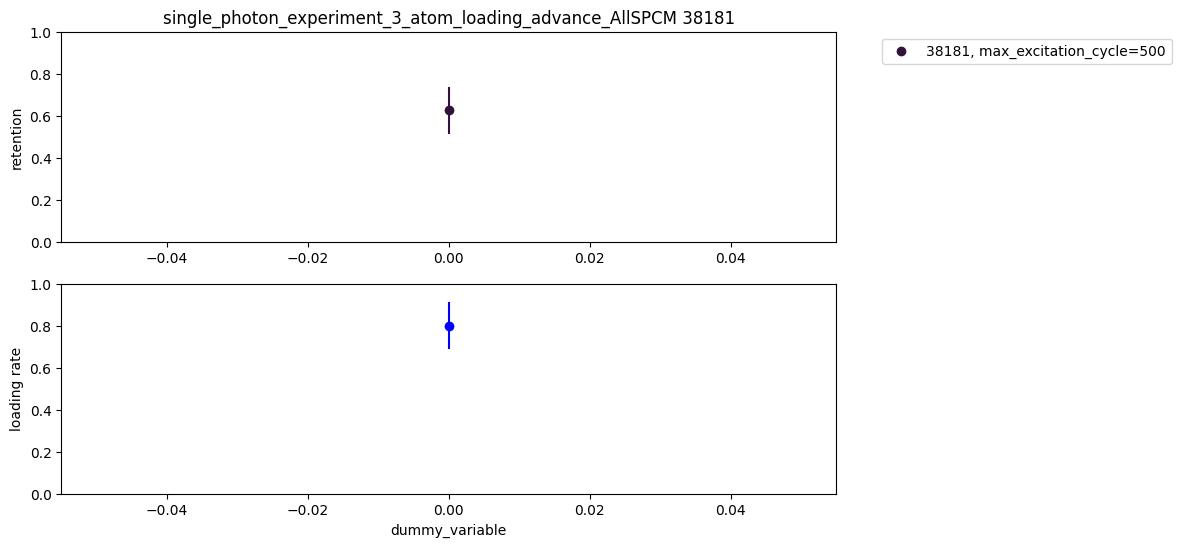

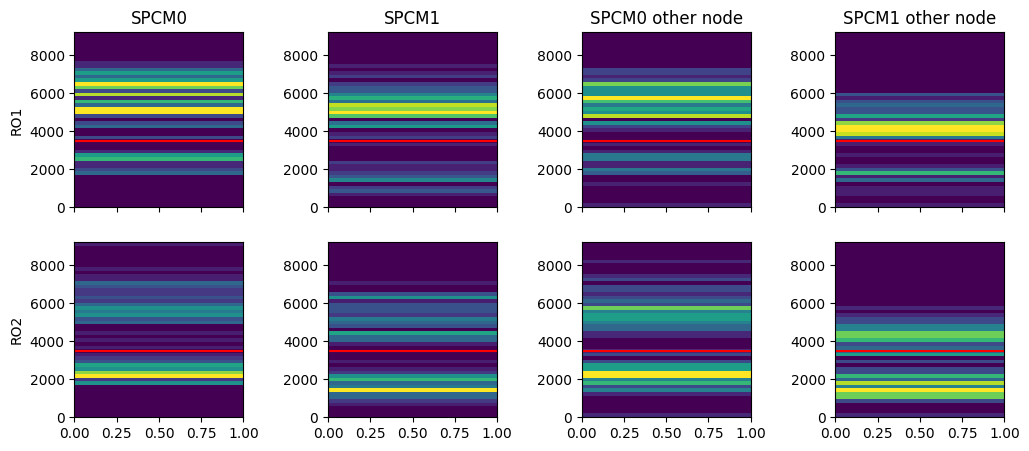

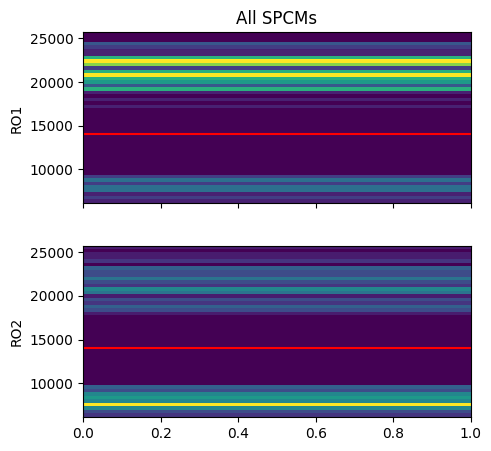

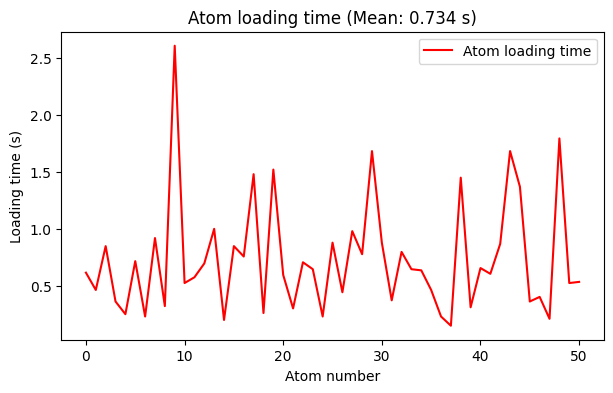

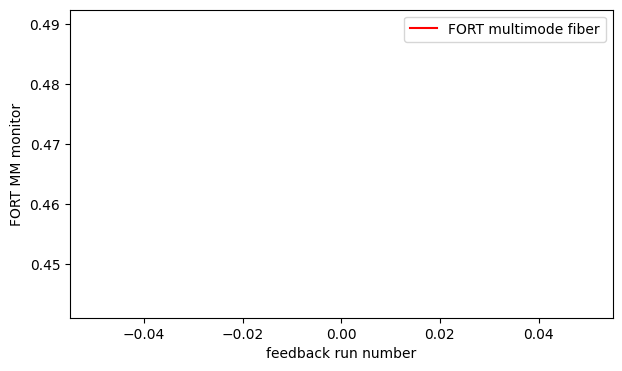

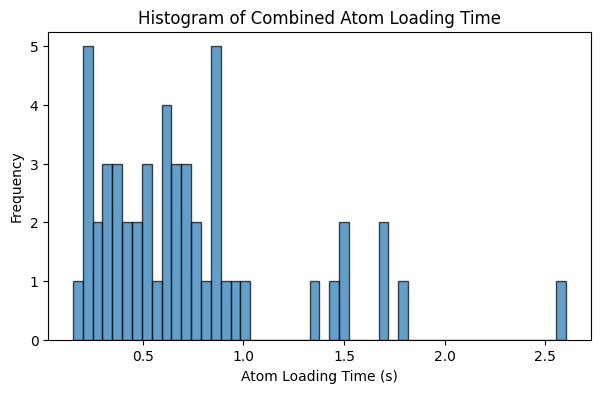

In [2]:
"""
"""
### the file(s) to analyze:
file_indices = {
    ##single photon exp
    # 6:'',
    # 8:''
    14:'max_excitation_cycle=500'
    
} 

# file_indices = {i: '' for i in range(0, 17, 2)}

compare = True # compare multiple files in the same retention and loading plots

otsu_threshold = False # compute threshold using Otsu method instead doing it by eye. only work when require atom loading = False

user_set_manual_threshold = 14000
manual_threshold = True


showhist = True
showloading = True
custom_xlabel = True
merge_data = False # if True, the datasets will be combined, and if fit=True, the new merged data will be fit. don't try this in 2D
fit = False

showhist_counts = False 

# for plotting
legend_vars =[]   #legend_vars = ['AY_volts_OP', 'f_microwaves_dds'] # will be included in the plot legend
xform_and_label = {}
loc='best'
ret_cmap = mpl.colormaps['turbo']
ldng_cmap = mpl.colormaps['winter']

if compare:
    if showloading:
        fig_ret,axes = plt.subplots(nrows=2, sharex=False, figsize=(10, 6))
        ax_ret, ax_ldng = axes
    else:
        fig_ret,ax_ret = plt.subplots()


SPCM0_RO1_hists = []
SPCM0_RO2_hists = []
SPCM1_RO1_hists = []
SPCM1_RO2_hists = []
SPCM0_OtherNode_RO1_hists = []
SPCM0_OtherNode_RO2_hists = []
SPCM1_OtherNode_RO1_hists = []
SPCM1_OtherNode_RO2_hists = []
BothSPCMs_RO1_hists = []
BothSPCMs_RO2_hists = []
AllSPCMs_RO1_hists = []
AllSPCMs_RO2_hists = []
mean1_by_iteration = []
mean2_by_iteration = []

merged_retention = np.array([])
merged_scan_sequence1 = np.array([])
merged_errs = np.array([])
rid_str = ''

all_atom_loading_times = []
all_atom_loading_wall_clocks = []

for idx,f_item in enumerate(file_indices.items()):
    f_idx,f_comment = f_item   # idx - f_item = {f_idx: f_comment}
    f = h5py.File(os.path.join(results, fnames[f_idx]))
    rid = f['rid'][()]
    h5_archive_and_datasets_to_locals(f, parent_locals=locals(), quiet=True)
    print("experiment:",experiment_function)
    print("override:",override_ExperimentVariables)

    iterations = len(scan_sequence1) #int(len(SPCM0_RO1)/n_measurements)
    print("# of iterations: ", iterations)

    all_atom_loading_times.append(Atom_loading_time[1:])
    all_atom_loading_wall_clocks.append(atom_loading_wall_clock[1:])
    
    if otsu_threshold:
        # thresh = threshold_otsu(BothSPCMs_RO1)
        thresh = threshold_otsu(AllSPCMs_RO1)

        print("threshold_otsu: ", thresh)
    elif manual_threshold:
        cutoff1 = cutoff2 = user_set_manual_threshold * t_SPCM_first_shot
    else:
        # cutoff1 = cutoff2 = 15000 * t_SPCM_first_shot

        cutoff1 = cutoff2 = single_atom_threshold * t_SPCM_first_shot
        # cutoff1 = cutoff2 = two_atom_threshold * t_SPCM_first_shot

    
    ### for plotting 
    ### xsteps_xform is a function that can transform scan_sequence1 for plotting. Here it is equal to identity, i.e. no change in scan_sequence1.
    if scan_variable1_name in xform_and_label and custom_xlabel:
        xsteps_xform, xlabel = (xform_and_label[scan_variable1_name]['xsteps_xform'], xform_and_label[scan_variable1_name]['xlabel'])
    else:
        xsteps_xform, xlabel = (lambda x: x, scan_variable1_name)
        

    legend_string = ''
    for a in legend_vars:
        legend_string += f'{a}={locals()[a]}, '
    legend_string = legend_string[:-2]
    f_comment += legend_string

    
    ### get_loading_and_retention
    ### These array have length = iterations
    # retention_array, loading_rate_array, n_atoms_loaded_array = get_loading_and_retention(BothSPCMs_RO1, BothSPCMs_RO2, n_measurements, iterations, cutoff1, otsu=otsu_threshold)
    retention_array, loading_rate_array, n_atoms_loaded_array = get_loading_and_retention(AllSPCMs_RO1, AllSPCMs_RO2, n_measurements, iterations, cutoff1, otsu=otsu_threshold)


    ### Necessary to analyze data with 2 scan_sequences
    ### reshaping each array into a 2D array with shape = shape, with order = 'F' (Fortran-style) to sort column by column
    
    ncols = len(scan_sequence2)
    nrows = len(scan_sequence1)
    shape = (len(scan_sequence2),len(scan_sequence1))
    loading_rate_raveled = np.reshape(loading_rate_array,shape,order='F') # rows have constant variable2
    n_atoms_loaded_raveled = np.reshape(n_atoms_loaded_array,shape,order='F') # rows have constant variable2
    retention_raveled = np.reshape(retention_array,shape,order='F') # rows have constant variable2

    
    # ### show historam of first_shot and second_shot
    # histMin = np.min([SPCM0_RO1, SPCM0_RO2, SPCM1_RO1, SPCM1_RO2, SPCM0_OtherNode_RO1, SPCM0_OtherNode_RO2, SPCM1_OtherNode_RO1, SPCM1_OtherNode_RO2])/t_SPCM_first_shot ## boundary for the histogram plots
    # histMax = np.max([SPCM0_RO1, SPCM0_RO2, SPCM1_RO1, SPCM1_RO2, SPCM0_OtherNode_RO1, SPCM0_OtherNode_RO2, SPCM1_OtherNode_RO1, SPCM1_OtherNode_RO2])/t_SPCM_first_shot


    ### Histogram boundaries for individual SPCMs
    single_hist_sources = [
        np.asarray(SPCM0_RO1) / t_SPCM_first_shot,
        np.asarray(SPCM1_RO1) / t_SPCM_first_shot,
        np.asarray(SPCM0_OtherNode_RO1) / t_SPCM_first_shot,
        np.asarray(SPCM1_OtherNode_RO1) / t_SPCM_first_shot,
    
        np.asarray(SPCM0_RO2) / t_SPCM_second_shot,
        np.asarray(SPCM1_RO2) / t_SPCM_second_shot,
        np.asarray(SPCM0_OtherNode_RO2) / t_SPCM_second_shot,
        np.asarray(SPCM1_OtherNode_RO2) / t_SPCM_second_shot,
    ]
    
    single_hist_sources = [x.ravel() for x in single_hist_sources if x.size > 0]
    
    histMin_single = min(np.min(x) for x in single_hist_sources)
    histMax_single = max(np.max(x) for x in single_hist_sources)
    
    
    ### Histogram boundaries for AllSPCMs
    all_hist_sources = [
        np.asarray(AllSPCMs_RO1) / t_SPCM_first_shot,
        np.asarray(AllSPCMs_RO2) / t_SPCM_second_shot,
    ]
    
    all_hist_sources = [x.ravel() for x in all_hist_sources if x.size > 0]
    
    histMin_all = min(np.min(x) for x in all_hist_sources)
    histMax_all = max(np.max(x) for x in all_hist_sources)


    
    if showhist:
        bins_single = np.linspace(histMin_single, histMax_single, 50)
        bins_all = np.linspace(histMin_all, histMax_all, 50)
    
        SPCM0_RO1_hists.append(
            [np.histogram(SPCM0_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM0_RO2_hists.append(
            [np.histogram(SPCM0_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM1_RO1_hists.append(
            [np.histogram(SPCM1_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM1_RO2_hists.append(
            [np.histogram(SPCM1_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM0_OtherNode_RO1_hists.append(
            [np.histogram(SPCM0_OtherNode_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM0_OtherNode_RO2_hists.append(
            [np.histogram(SPCM0_OtherNode_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM1_OtherNode_RO1_hists.append(
            [np.histogram(SPCM1_OtherNode_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM1_OtherNode_RO2_hists.append(
            [np.histogram(SPCM1_OtherNode_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        AllSPCMs_RO1_hists.append(
            [np.histogram(AllSPCMs_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_all)[0]
             for i in range(iterations)]
        )
    
        AllSPCMs_RO2_hists.append(
            [np.histogram(AllSPCMs_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_all)[0]
             for i in range(iterations)]
        )

    
    ### plot a retention curve vs variable 1 for each variable 2 value
    for i, retention, loading, n_loaded, var2 in zip(range(len(scan_sequence2)), retention_raveled, loading_rate_raveled, n_atoms_loaded_raveled, scan_sequence2):
        
        errs = np.array([1/np.sqrt(n) if n > 0 else np.inf for n in n_loaded])
        if not compare:
            if showloading:
                    fig_ret,axes = plt.subplots(nrows=2, sharex=False)
                    ax_ret, ax_ldng = axes
            else:
                fig_ret,ax_ret = plt.subplots()
                
        if not merge_data:
            ax_ret.scatter(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0], label=str(rid)+', '+f_comment, color=ret_cmap(idx/len(file_indices)))
            ax_ret.errorbar(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0], errs[loading > 0], ls='none',color=ret_cmap(idx/len(file_indices)))
            ax_ret.set_ylim((0,1))

            ### for fitting
            ### Auto-detect rough center from minimum retention
            fit_dict = {}
            min_idx = np.argmin(retention_array)
            initial_center = scan_sequence1[min_idx]
            p0 = [initial_center, 10e3, 0.9] # [center, width, depth]
            
            ### using a  Gaussian function for now:
            fit_dict = {
                scan_variable1_name: {
                    'model': lambda x, center, sigma, depth: 0.80*(1 - depth * np.exp(-((x - center)**2/(2*sigma**2)))),
                    'p0': p0,
                    'bounds': ([min(scan_sequence1), 0, 0], [max(scan_sequence1), np.inf, 1]),
                    'params': ['center', 'sigma', 'depth']
                }
            }

            if not ncols > 1 and fit and scan_variable1_name in fit_dict:
                popt, _ = curve_fit(f=fit_dict[scan_variable1_name]['model'], xdata=scan_sequence1, ydata=retention, p0=fit_dict[scan_variable1_name]['p0'], bounds=fit_dict[scan_variable1_name]['bounds'])
                fit_str = "".join([f'{p}={v:.4f}, ' for p,v in zip(fit_dict[scan_variable1_name]['params'], popt)])[:-2]
                print(fit_str)
                hi_res_x = np.linspace(scan_sequence1[0], scan_sequence1[-1], 10*len(scan_sequence1))
                hi_res_x_xform = np.linspace(xsteps_xform(scan_sequence1)[0], xsteps_xform(scan_sequence1)[-1], 10*len(scan_sequence1))
                ax_ret.plot(hi_res_x_xform, fit_dict[scan_variable1_name]['model'](hi_res_x, *popt),linestyle='--',color=ret_cmap(idx/len(file_indices)),label=fit_str)
            else:
                ax_ret.plot(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0],linestyle='--',color=ret_cmap(idx/len(file_indices)))
    
            if not showloading:
                ax_ret.set_xlabel(xlabel)
            ax_ret.set_ylabel("retention")
            #ax_ret.legend(loc=loc)
            ax_ret.legend(bbox_to_anchor=(1.05, 1), loc='upper left')      # This will show the legend outside the plot
            
        else:
            merged_retention = np.concatenate((merged_retention,retention[loading > 0]))
            merged_scan_sequence1 = np.concatenate((merged_scan_sequence1, scan_sequence1[loading > 0]))
            merged_errs = np.concatenate((merged_errs, errs[loading > 0]))
            rid_str += str(rid) + ', '
    
        if showloading:
            ax_ldng.plot(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], linestyle='--',color=ldng_cmap(idx/len(file_indices)))
            ax_ldng.scatter(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], label=rid, color=ldng_cmap(idx/len(file_indices)))
            errs = np.array([1/np.sqrt(n) if n > 0 else np.inf for n in n_loaded])
            ax_ldng.errorbar(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], errs[loading > 0], ls='none', color=ldng_cmap(idx/len(file_indices)))
            ax_ldng.set_ylim((0,1))
            ax_ldng.set_xlabel(xlabel)
            ax_ldng.set_ylabel("loading rate")


if merge_data:
    retention = merged_retention
    scan_sequence1 = merged_scan_sequence1
    errs = merged_errs

    ax_ret.scatter(xsteps_xform(scan_sequence1), retention, color='plum')
    ax_ret.errorbar(xsteps_xform(scan_sequence1), retention, errs, ls='none',color='plum')
    ax_ret.set_ylim((0,1))
    
    if not ncols > 1 and fit and scan_variable1_name in fit_dict:        
        popt, _ = curve_fit(f=fit_dict[scan_variable1_name]['model'], xdata=scan_sequence1, ydata=retention, p0=fit_dict[scan_variable1_name]['p0'], bounds=fit_dict[scan_variable1_name]['bounds'])
        hi_res_x = np.linspace(scan_sequence1[0], scan_sequence1[-1], 10*len(scan_sequence1))
        hi_res_x_xform = np.linspace(xsteps_xform(scan_sequence1)[0], xsteps_xform(scan_sequence1)[-1], 10*len(scan_sequence1))
        fit_str = "".join([f'{p}={v:.4f}, ' for p,v in zip(fit_dict[scan_variable1_name]['params'], popt)])[:-2]
        print(fit_str)
        ax_ret.plot(hi_res_x_xform, fit_dict[scan_variable1_name]['model'](hi_res_x, *popt),linestyle='--',color='violet', label=fit_str)
        ax_ret.legend()
    else:
        ax_ret.plot(xsteps_xform(scan_sequence1), retention,linestyle='--',color='violet')


if not compare or len(file_indices)==1:
    ax_ret.set_title(experiment_function+' '+str(rid))
elif merge_data:
    ax_ret.set_title(experiment_function+' '+ rid_str[:-2])
else:
    ax_ret.set_title(experiment_function)

if showhist:
    ### Individual SPCM plots
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 5), sharex=True)
    ax, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes.ravel()

    ### RO1: SPCM0
    cax = ax.imshow(np.array(SPCM0_RO1_hists[0]).transpose(), origin='lower',
                    extent=[0, iterations, histMin_single, histMax_single])
    ax.set_ylabel("RO1")
    ax.axhline((cutoff1 / 4) / t_SPCM_first_shot, color='red')
    ax.set_aspect('auto')
    ax.set_title("SPCM0")

    ### RO1: SPCM1
    cax2 = ax2.imshow(np.array(SPCM1_RO1_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax2.axhline((cutoff1 / 4) / t_SPCM_first_shot, color='red')
    ax2.set_aspect('auto')
    ax2.set_title("SPCM1")

    ### RO1: SPCM0 Other Node
    cax3 = ax3.imshow(np.array(SPCM0_OtherNode_RO1_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax3.axhline((cutoff1 / 4) / t_SPCM_first_shot, color='red')
    ax3.set_aspect('auto')
    ax3.set_title("SPCM0 other node")

    ### RO1: SPCM1 Other Node
    cax4 = ax4.imshow(np.array(SPCM1_OtherNode_RO1_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax4.axhline((cutoff1 / 4) / t_SPCM_first_shot, color='red')
    ax4.set_aspect('auto')
    ax4.set_title("SPCM1 other node")


    ### RO2: SPCM0
    cax5 = ax5.imshow(np.array(SPCM0_RO2_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax5.set_ylabel("RO2")
    ax5.axhline((cutoff2 / 4) / t_SPCM_second_shot, color='red')
    ax5.set_aspect('auto')

    ### RO2: SPCM1
    cax6 = ax6.imshow(np.array(SPCM1_RO2_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax6.axhline((cutoff2 / 4) / t_SPCM_second_shot, color='red')
    ax6.set_aspect('auto')

    ### RO2: SPCM0 Other Node
    cax7 = ax7.imshow(np.array(SPCM0_OtherNode_RO2_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax7.axhline((cutoff2 / 4) / t_SPCM_second_shot, color='red')
    ax7.set_aspect('auto')

    ### RO2: SPCM1 Other Node
    cax8 = ax8.imshow(np.array(SPCM1_OtherNode_RO2_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax8.axhline((cutoff2 / 4) / t_SPCM_second_shot, color='red')
    ax8.set_aspect('auto')

    plt.subplots_adjust(hspace=0.2, wspace=0.5)


    ### All SPCMs plotted separately
    fig_all, axes_all = plt.subplots(nrows=2, ncols=1, figsize=(5, 5), sharex=True)
    ax_all1, ax_all2 = axes_all.ravel()

    ### RO1: All SPCMs
    cax_all1 = ax_all1.imshow(np.array(AllSPCMs_RO1_hists[0]).transpose(), origin='lower',
                              extent=[0, iterations, histMin_all, histMax_all])
    ax_all1.set_ylabel("RO1")
    ax_all1.axhline(cutoff1 / t_SPCM_first_shot, color='red')
    ax_all1.set_aspect('auto')
    ax_all1.set_title("All SPCMs")

    ### RO2: All SPCMs
    cax_all2 = ax_all2.imshow(np.array(AllSPCMs_RO2_hists[0]).transpose(), origin='lower',
                              extent=[0, iterations, histMin_all, histMax_all])
    ax_all2.set_ylabel("RO2")
    ax_all2.axhline(cutoff2 / t_SPCM_second_shot, color='red')
    ax_all2.set_aspect('auto')

    plt.subplots_adjust(hspace=0.25)

plt.show()



#### Plot the combined Atom_loading_time values
## We can slice the array to separate iterations later, if we want.
combined_atom_loading_times = [t for loading_times in all_atom_loading_times for t in loading_times]
mean_loading_time = np.mean(combined_atom_loading_times)
plt.figure(figsize=(7, 4))
plt.plot(combined_atom_loading_times, 'r-', label='Atom loading time')
plt.xlabel("Atom number")
plt.ylabel("Loading time (s)")
plt.title(f"Atom loading time (Mean: {mean_loading_time:.3f} s)") 
# plt.title(f"Combined Atom Loading Time for All Files")
plt.legend(loc='best')
plt.show()


#### Plot FORT multimode fiber 
plt.figure(figsize=(7, 4))
plt.plot(FORT_MM_monitor, 'r-', label='FORT multimode fiber')
plt.xlabel("feedback run number")
plt.ylabel("FORT MM monitor")
# plt.title(f"FORT MM fiber")
plt.legend(loc='best')
plt.show()


# Plot the histogram of combined Atom_loading_time
plt.figure(figsize=(7, 4))
plt.hist(combined_atom_loading_times, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel("Atom Loading Time (s)")
plt.ylabel("Frequency")
plt.title(f"Histogram of Combined Atom Loading Time")
plt.show()



### Magnetometer analysis - by measurement

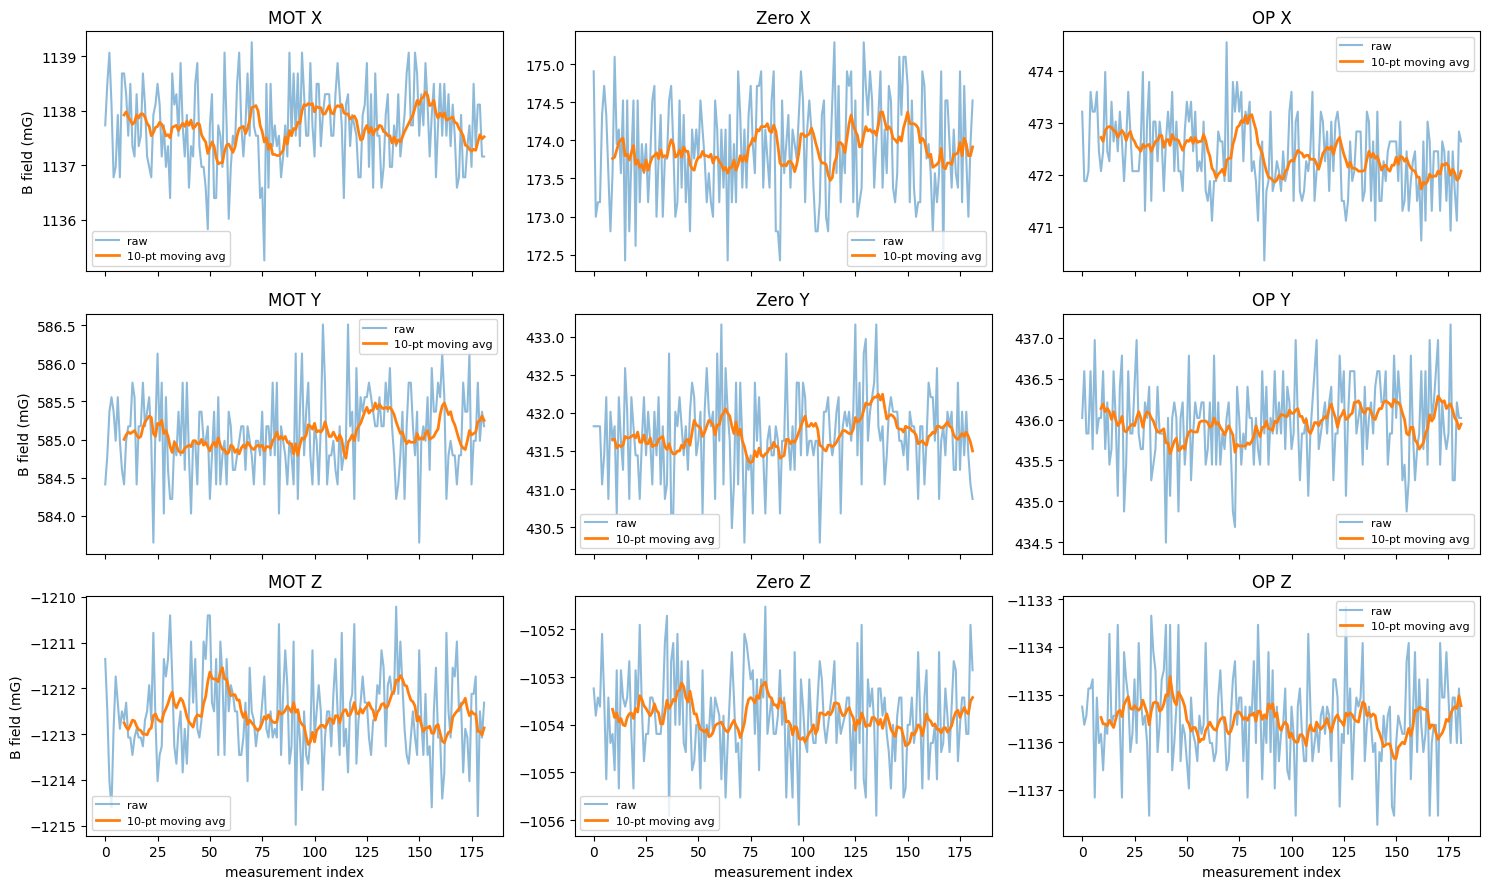

In [56]:
"""
Plot raw magnetometer data with a moving average on top.
Layout:
Row 1: MOT X, Zero X, OP X
Row 2: MOT Y, Zero Y, OP Y
Row 3: MOT Z, Zero Z, OP Z
"""

import numpy as np
import matplotlib.pyplot as plt

# Conversion factor: V -> mG
V_to_mG = 625

# Moving average window
window = 10

# Reordered raw magnetometer data converted to mG
Magnetometer_data = [
    Magnetometer_MOT_X[1:] * V_to_mG,
    Magnetometer_Zero_X[1:] * V_to_mG,
    Magnetometer_OP_X[1:] * V_to_mG,

    Magnetometer_MOT_Y[1:] * V_to_mG,
    Magnetometer_Zero_Y[1:] * V_to_mG,
    Magnetometer_OP_Y[1:] * V_to_mG,

    Magnetometer_MOT_Z[1:] * V_to_mG,
    Magnetometer_Zero_Z[1:] * V_to_mG,
    Magnetometer_OP_Z[1:] * V_to_mG
]


display(HTML(f"""<b style='font-size:18px;'> RID {rid} - {experiment_function}</b>"""))

fig, axs = plt.subplots(3, 3, figsize=(15, 9), sharex=True, sharey=False)

titles = [
    "MOT X", "Zero X", "OP X",
    "MOT Y", "Zero Y", "OP Y",
    "MOT Z", "Zero Z", "OP Z",
]

ylabels = ["B field (mG)"] + [""]*2 + ["B field (mG)"] + [""]*2 + ["B field (mG)"] + [""]*2
xlabels = [""] * 6 + ["measurement index"] * 3

for idx, raw_data in enumerate(Magnetometer_data):
    row = idx // 3
    col = idx % 3
    ax = axs[row, col]

    # raw data
    ax.plot(raw_data, '-', alpha=0.5, label='raw')

    # moving average
    if len(raw_data) >= window:
        smooth_data = np.convolve(raw_data, np.ones(window) / window, mode='valid')
        x_smooth = np.arange(window - 1, len(raw_data))
        ax.plot(x_smooth, smooth_data, linewidth=2, label=f'{window}-pt moving avg')

    ax.set_title(titles[idx])

    if ylabels[idx]:
        ax.set_ylabel(ylabels[idx])
    if xlabels[idx]:
        ax.set_xlabel(xlabels[idx])

    ax.legend(fontsize=8)

# ax.set_title(f"{locals().get('experiment_function', '')} {rid}")

plt.tight_layout()
plt.show()

# Magnetometer_MOT_X

### measure_Magnetometer_X_Y_Z

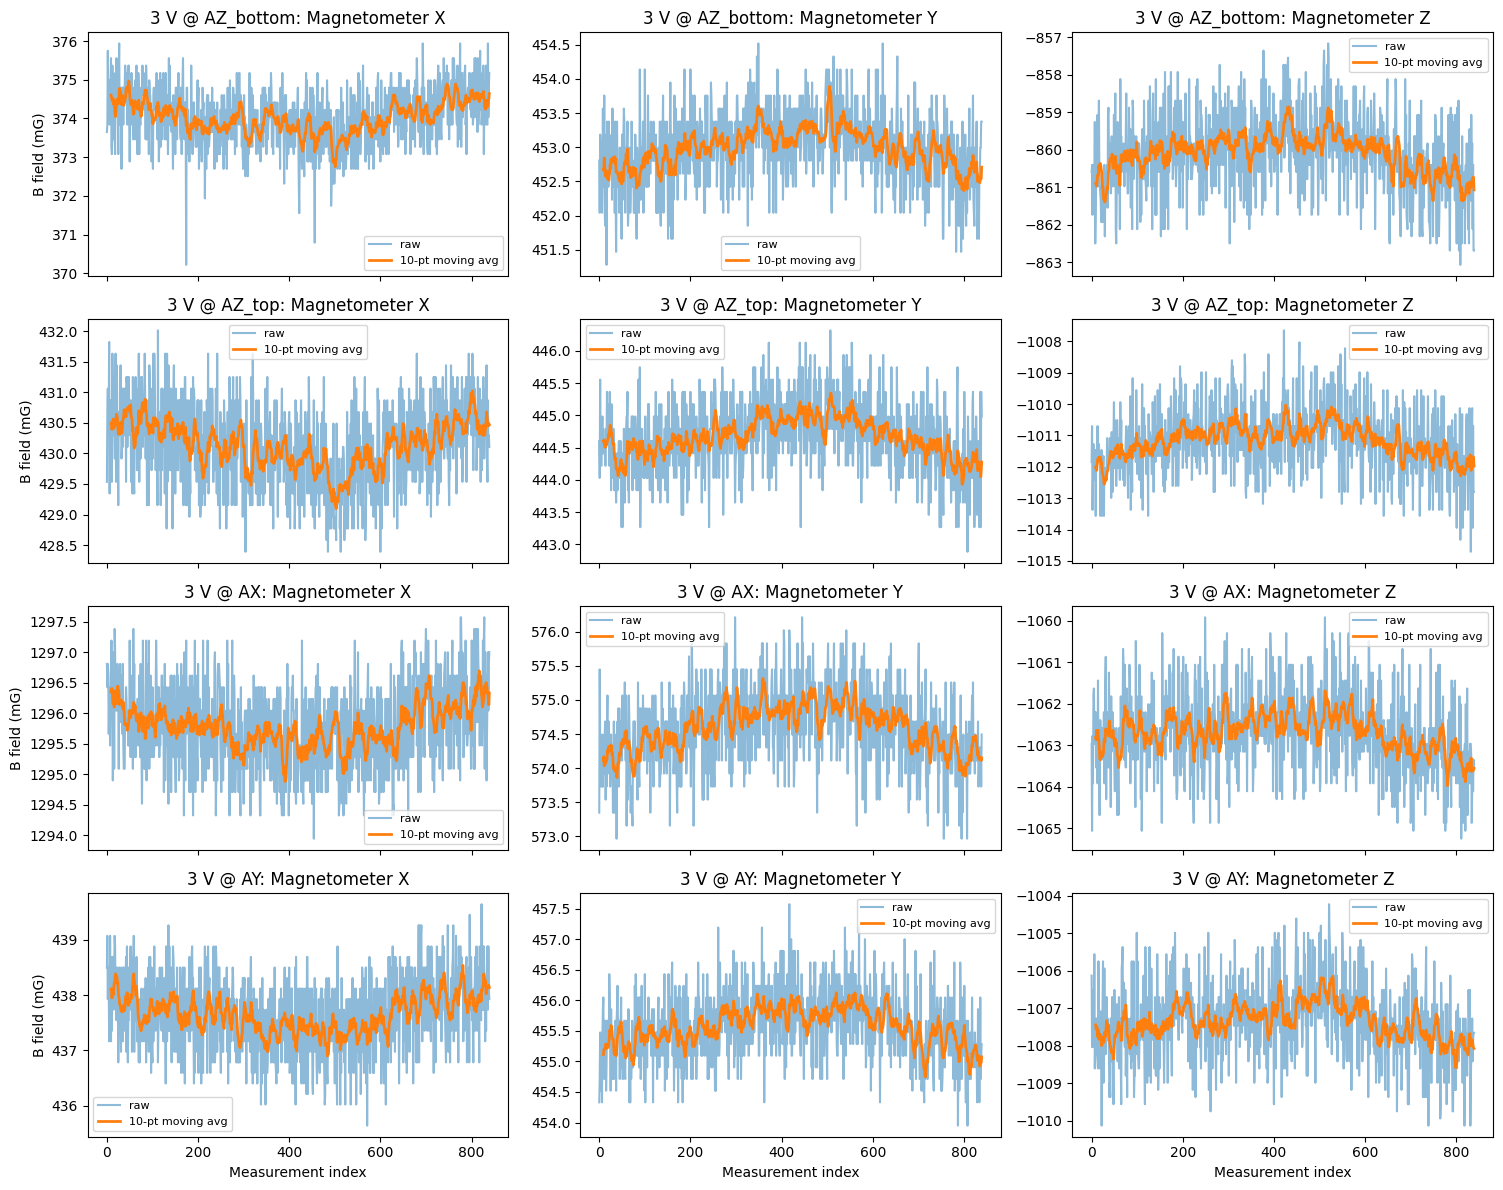

In [69]:
"""
Plot the magnetic field produced by each coil channel separately.

Layout:
Row 1: 3 V @ AZ_bottom → Magnetometer X, Y, Z
Row 2: 3 V @ AZ_top    → Magnetometer X, Y, Z
Row 3: 3 V @ AX        → Magnetometer X, Y, Z
Row 4: 3 V @ AY        → Magnetometer X, Y, Z
"""

import numpy as np
import matplotlib.pyplot as plt

V_to_mG = 625
window = 10

# Dataset mapping:
# Zero -> AZ_bottom
# OP   -> AZ_top
# MOT  -> AX
# TEST -> AY
Magnetometer_data = [
    [Magnetometer_Zero_X[1:] * V_to_mG, Magnetometer_Zero_Y[1:] * V_to_mG, Magnetometer_Zero_Z[1:] * V_to_mG],
    [Magnetometer_OP_X[1:] * V_to_mG, Magnetometer_OP_Y[1:] * V_to_mG, Magnetometer_OP_Z[1:] * V_to_mG],
    [Magnetometer_MOT_X[1:] * V_to_mG, Magnetometer_MOT_Y[1:] * V_to_mG, Magnetometer_MOT_Z[1:] * V_to_mG],
    [Magnetometer_TEST_X[1:] * V_to_mG, Magnetometer_TEST_Y[1:] * V_to_mG, Magnetometer_TEST_Z[1:] * V_to_mG],
]

coil_names = ["3 V @ AZ_bottom", "3 V @ AZ_top", "3 V @ AX", "3 V @ AY"]
magnetometer_axes = ["X", "Y", "Z"]

display(HTML(f"<b style='font-size:18px;'>RID {rid} - {experiment_function}</b>"))

fig, axs = plt.subplots(4, 3, figsize=(15, 12), sharex=True, sharey=False)

for row in range(4):
    for col in range(3):
        ax = axs[row, col]
        raw_data = np.asarray(Magnetometer_data[row][col])

        ax.plot(raw_data, "-", alpha=0.5, label="raw")

        if len(raw_data) >= window:
            smooth_data = np.convolve(raw_data, np.ones(window) / window, mode="valid")
            x_smooth = np.arange(window - 1, len(raw_data))
            ax.plot(x_smooth, smooth_data, linewidth=2, label=f"{window}-pt moving avg")

        ax.set_title(f"{coil_names[row]}: Magnetometer {magnetometer_axes[col]}")

        if col == 0:
            ax.set_ylabel("B field (mG)")

        if row == 3:
            ax.set_xlabel("Measurement index")

        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### SPCM Histogram drawn separately

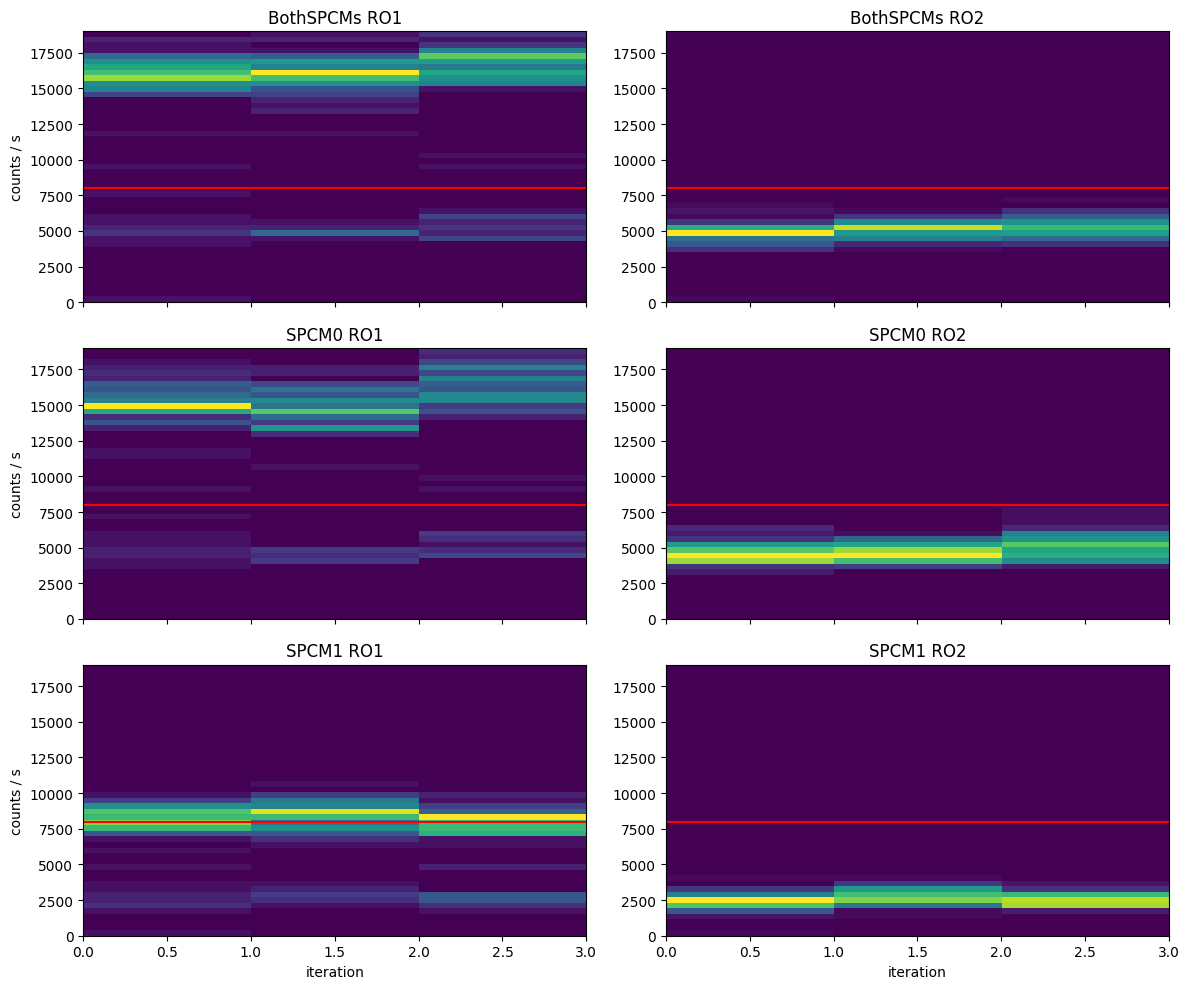

In [215]:
# new histogram containers
SPCM0_first_shot_hists = []
SPCM0_second_shot_hists = []
SPCM1_first_shot_hists = []
SPCM1_second_shot_hists = []

histMin = min(
    np.min(BothSPCMs_RO1 / t_SPCM_first_shot),
    np.min(BothSPCMs_RO2 / t_SPCM_second_shot),
    np.min(SPCM0_RO1 / t_SPCM_first_shot),
    np.min(SPCM0_RO2 / t_SPCM_second_shot),
    np.min(SPCM1_RO1 / t_SPCM_first_shot),
    np.min(SPCM1_RO2 / t_SPCM_second_shot),
)

histMax = max(
    np.max(BothSPCMs_RO1 / t_SPCM_first_shot),
    np.max(BothSPCMs_RO2 / t_SPCM_second_shot),
    np.max(SPCM0_RO1 / t_SPCM_first_shot),
    np.max(SPCM0_RO2 / t_SPCM_second_shot),
    np.max(SPCM1_RO1 / t_SPCM_first_shot),
    np.max(SPCM1_RO2 / t_SPCM_second_shot),
)

if showhist:
    bins = np.linspace(histMin, histMax, 50)

    first_shot_hists.append(
        [np.histogram(BothSPCMs_RO1[i*n_measurements:(i+1)*n_measurements]/t_SPCM_first_shot, bins=bins)[0]
         for i in range(iterations)]
    )
    second_shot_hists.append(
        [np.histogram(BothSPCMs_RO2[i*n_measurements:(i+1)*n_measurements]/t_SPCM_second_shot, bins=bins)[0]
         for i in range(iterations)]
    )

    SPCM0_first_shot_hists.append(
        [np.histogram(SPCM0_RO1[i*n_measurements:(i+1)*n_measurements]/t_SPCM_first_shot, bins=bins)[0]
         for i in range(iterations)]
    )
    SPCM0_second_shot_hists.append(
        [np.histogram(SPCM0_RO2[i*n_measurements:(i+1)*n_measurements]/t_SPCM_second_shot, bins=bins)[0]
         for i in range(iterations)]
    )

    SPCM1_first_shot_hists.append(
        [np.histogram(SPCM1_RO1[i*n_measurements:(i+1)*n_measurements]/t_SPCM_first_shot, bins=bins)[0]
         for i in range(iterations)]
    )
    SPCM1_second_shot_hists.append(
        [np.histogram(SPCM1_RO2[i*n_measurements:(i+1)*n_measurements]/t_SPCM_second_shot, bins=bins)[0]
         for i in range(iterations)]
    )

if showhist:
    fig, axes = plt.subplots(3, 2, sharex=True, figsize=(12, 10))

    datasets = [
        (first_shot_hists[0], "BothSPCMs RO1", cutoff1/t_SPCM_first_shot),
        (second_shot_hists[0], "BothSPCMs RO2", cutoff2/t_SPCM_second_shot),
        (SPCM0_first_shot_hists[0], "SPCM0 RO1", cutoff1/t_SPCM_first_shot),
        (SPCM0_second_shot_hists[0], "SPCM0 RO2", cutoff2/t_SPCM_second_shot),
        (SPCM1_first_shot_hists[0], "SPCM1 RO1", cutoff1/t_SPCM_first_shot),
        (SPCM1_second_shot_hists[0], "SPCM1 RO2", cutoff2/t_SPCM_second_shot),
    ]

    for ax, (hist_data, title, cutoff_line) in zip(axes.flatten(), datasets):
        ax.imshow(np.array(hist_data).T, origin='lower', extent=[0, iterations, histMin, histMax], aspect='auto')
        ax.set_title(title)
        ax.axhline(cutoff_line, color='red')

    for ax in axes[:, 0]:
        ax.set_ylabel("counts / s")
    for ax in axes[-1, :]:
        ax.set_xlabel("iteration")

    plt.tight_layout()
    plt.show()

Early timestamp for 80 elements on SPCM0 was detected.
Early timestamp for 35 elements on SPCM1 was detected.
# of coincidences: 0
# of SPCM0 1 click: 80.0
# of SPCM1 1 click: 34.0
SPCM0_2click_counts_iAll 0.0
SPCM1_2click_counts_iAll 1.0
----
# of total SPCM0 counts: 80.0
# of total SPCM1 counts: 36.0
 n_excitation_cycles_iAll[i] 10260 
----
 (SPCM0 clicks + SPCM1 clicks)/(total exc cycles) = 0.011306042884990253
n_measurements = 100
excitation pulse width = 30.000000000000004 ns
SPCM window = 500.00000000000006 ns
excitation AOM power (dBm) = -10.0
n_excitation_attempts = 5
check atom avery n excitation cycles = 30


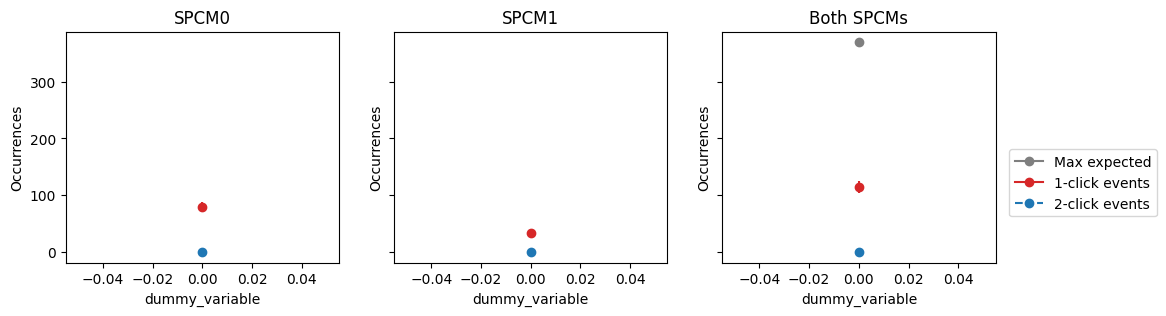

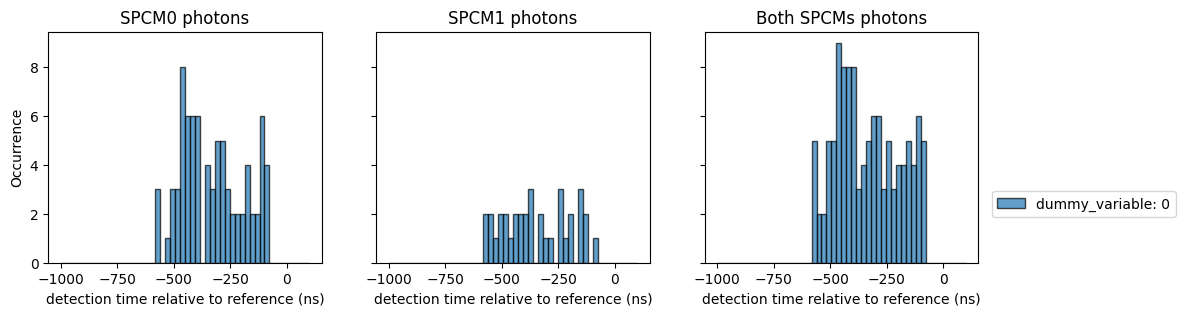

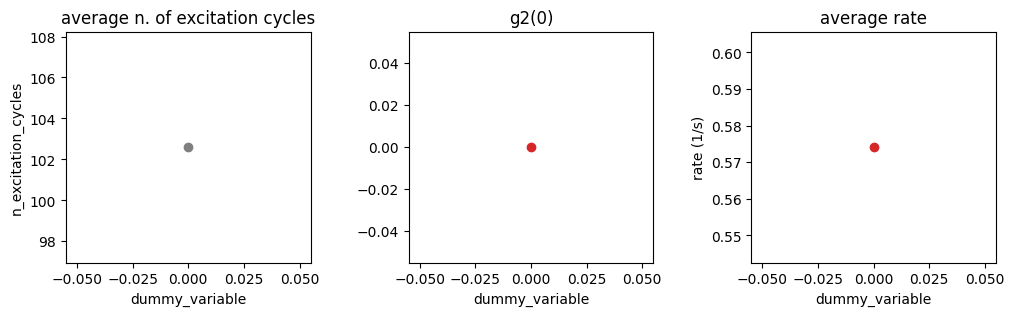

In [171]:
### Print the title of the output
display(HTML(f"""<b style='font-size:18px;'> {date_filters[0]} - RID {rid} - {experiment_function}</b>"""))

Col_Eff = 0.036 # overal expected/theoretical collection and detection efficiency 

### Instead of using a large n_measurements, which can sometimes lead to underflow error, we use dummy_variable to split the measurements. 
### So, if scan_variable1_name == 'dummy_variable', we want to combine all iterations into one:
if scan_variable1_name == 'dummy_variable':
    n_measurements = n_measurements * iterations
    iterations = 1
    scan_sequence1 = [0]

## To look at specific iterations, you can select in scan_sequence_1, for example scan_sequence1 = [0,2]. For now, the first element has to be 0.
# scan_sequence1 = [0,4]
# iterations = len(scan_sequence1)
# n_measurements = n_measurements * iterations


n_excitation_cycles_iAll = np.zeros(iterations, dtype=int) ### total number of excitation cycle in each iteration.
n_tStamps_iAll = np.zeros(iterations, dtype=int)  ### number of timestamps in each iteration. 

for i in range(iterations):
    n_excitation_cycles_iAll[i] = sum(n_excitation_cycles[i*n_measurements+1:(i+1)*n_measurements+1]+1)

    if scan_variable1_name == 'n_excitation_attempts':
        n_excitation_attempts = scan_sequence1[i]

    n_tStamps_iAll[i] = n_excitation_cycles_iAll[i] * n_excitation_attempts

    ### Note that n_excitation_cycles varies in each cycle, each contains n_excitation_attempts.
    ### the first +1 is because the first element in each dataset is 0. 
    ### the last +1 is because there is one more cycle than n_excitation_cycles in each loop. See the oscciloscope. For example, if n_excitation_cycles[j] = 2, 
    ### there are 2+1=3 sets of excitation cycles for that measurement. 


SPCM0_1click_counts_iAll = np.array([])
SPCM0_2click_counts_iAll = np.array([])
SPCM1_1click_counts_iAll = np.array([])
SPCM1_2click_counts_iAll = np.array([])

BothSPCMs_tStamps_filtered_iAll = []
SPCM0_tStamps_filtered_iAll = []
SPCM1_tStamps_filtered_iAll = []

SPCM0_rel_tStamps_iAll = []
SPCM1_rel_tStamps_iAll = []

g2_0 = np.zeros(iterations)
g2_0_err = np.zeros(iterations)
Ave_photon_rate_iAll = np.zeros(iterations)

### Calculate the ending and starting indices for the iterations
end_indices = np.cumsum(n_tStamps_iAll)
start_indices = np.insert(end_indices[:-1], 0, 0) ### prepend a 0 for the starting index

for i in range(iterations):
    start = start_indices[i]
    end = end_indices[i]

    SPCM0_tStamps_i = SPCM0_SinglePhoton_tStamps[1:][start:end]
    SPCM1_tStamps_i = SPCM1_SinglePhoton_tStamps[1:][start:end]
    t1_reference_i = reference_tStamps_t1[1:][start:end]

    # # ################################# SPCM1 counts arrive ~40ns later #################################
    # if apply_delay_in_SPCM1:
    # shift = -40*1e-9
    # np.add(SPCM1_tStamps_i, shift, out=SPCM1_tStamps_i, where=SPCM1_tStamps_i >= -1)

    ### number of 1-click events: first column is not -1
    SPCM0_1click_counts_iAll = np.append(
        SPCM0_1click_counts_iAll,
        np.count_nonzero(SPCM0_tStamps_i[:, 0] != -1)
    )

    ### number of 2-click events: second column is not -1
    SPCM0_2click_counts_iAll = np.append(
        SPCM0_2click_counts_iAll,
        np.count_nonzero(SPCM0_tStamps_i[:, 1] != -1)
    )

    ### number of 1-click events: first column is not -1
    SPCM1_1click_counts_iAll = np.append(
        SPCM1_1click_counts_iAll,
        np.count_nonzero(SPCM1_tStamps_i[:, 0] != -1)
    )

    ### number of 2-click events: second column is not -1
    SPCM1_2click_counts_iAll = np.append(
        SPCM1_2click_counts_iAll,
        np.count_nonzero(SPCM1_tStamps_i[:, 1] != -1)
    )

    SPCM0_total_counts = SPCM0_1click_counts_iAll[i] + 2*SPCM0_2click_counts_iAll[i]
    SPCM1_total_counts = SPCM1_1click_counts_iAll[i] + 2*SPCM1_2click_counts_iAll[i]
    
    ############################### relative timestamps #############################
    ### -1 means no photon detected, so those entries are excluded.
    ### After removing -1, keep both positive and negative relative timestamps.
    ### Negative relative timestamps mean the photon was detected before t1_reference_i.

    SPCM0_rel_tStamps_i_temp = [
        row[row != -1] - ref
        for row, ref in zip(SPCM0_tStamps_i, t1_reference_i)
    ]

    SPCM0_rel_tStamps_i = np.concatenate(SPCM0_rel_tStamps_i_temp) * 1e9  # convert to ns

    SPCM0_early_rel_tStamps_i = SPCM0_rel_tStamps_i[SPCM0_rel_tStamps_i < 0]

    if len(SPCM0_early_rel_tStamps_i) > 0:
        print(f'Early timestamp for {len(SPCM0_early_rel_tStamps_i)} elements on SPCM0 was detected.')

    SPCM0_rel_tStamps_iAll.append(SPCM0_rel_tStamps_i)


    SPCM1_rel_tStamps_i_temp = [
        row[row != -1] - ref
        for row, ref in zip(SPCM1_tStamps_i, t1_reference_i)
    ]

    SPCM1_rel_tStamps_i = np.concatenate(SPCM1_rel_tStamps_i_temp) * 1e9  # convert to ns

    SPCM1_early_rel_tStamps_i = SPCM1_rel_tStamps_i[SPCM1_rel_tStamps_i < 0]

    if len(SPCM1_early_rel_tStamps_i) > 0:
        print(f'Early timestamp for {len(SPCM1_early_rel_tStamps_i)} elements on SPCM1 was detected.')

    SPCM1_rel_tStamps_iAll.append(SPCM1_rel_tStamps_i)


    # ################################# SPCM1 counts arrive ~40ns later #################################
    # ## there is a delay in SPCM1 ttl count detection
    # if apply_delay_in_SPCM1:
    #     SPCM1_rel_tStamps_iAll_copy = [SPCM1_rel_tStamps_iAll[0] + shift]

        
    ############################### g2 calculation #############################
    ### calculate g2 for each iteration. In future, we can also select a narrower coincidence window. Right now the coincidence window is the entire gate window.
    n_coincidence_i = np.sum(
        (SPCM0_tStamps_i[:, 0] >= 1) & 
        (SPCM1_tStamps_i[:, 0] >= 1)
    ) ### looking at the first clicks for coincidences.

    # n_coincidence_i = 1 ### if there is no coincidence, you can set n_coincidence_i = 1 manually to find the bound to g2 because the next count might be a coincidence.

    if SPCM0_1click_counts_iAll[i] > 0 and SPCM1_1click_counts_iAll[i] > 0:
        g2_0_temp = (
            n_coincidence_i /
            (SPCM0_1click_counts_iAll[i] * SPCM1_1click_counts_iAll[i])
        ) * n_excitation_cycles_iAll[i]

        ### Errors for g2 results are from error propagation assuming Poissonian distribution for counts:
        if n_coincidence_i > 0:
            g2_0_err_temp = g2_0_temp * np.sqrt(
                1/n_coincidence_i +
                1/SPCM0_1click_counts_iAll[i] +
                1/SPCM1_1click_counts_iAll[i]
            )
        else:
            g2_0_err_temp = np.nan
    else:
        g2_0_temp = np.nan 
        g2_0_err_temp = np.nan

    g2_0[i] = g2_0_temp
    g2_0_err[i] = g2_0_err_temp

    print(f"# of coincidences: {n_coincidence_i}")
    print(f"# of SPCM0 1 click: {SPCM0_1click_counts_iAll[i]}")
    print(f"# of SPCM1 1 click: {SPCM1_1click_counts_iAll[i]}")
    print(f"SPCM0_2click_counts_iAll {SPCM0_2click_counts_iAll[i]}")
    print(f"SPCM1_2click_counts_iAll {SPCM1_2click_counts_iAll[i]}")
    print("----")
    print(f"# of total SPCM0 counts: {SPCM0_total_counts}")
    print(f"# of total SPCM1 counts: {SPCM1_total_counts}")
    print(f" n_excitation_cycles_iAll[i] {n_excitation_cycles_iAll[i]} ")
    print("----")
    print(f" (SPCM0 clicks + SPCM1 clicks)/(total exc cycles) = {(SPCM0_total_counts + SPCM1_total_counts)/(n_excitation_cycles_iAll[i])}")

    ############## absolute timestamps of all the photons for rate analysis
    BothSPCMs_tStamps_flatten_i = np.concatenate((SPCM0_tStamps_i, SPCM1_tStamps_i)).flatten()
    BothSPCMs_tStamps_filtered_i = BothSPCMs_tStamps_flatten_i[BothSPCMs_tStamps_flatten_i != -1]
    BothSPCMs_tStamps_filtered_i = np.sort(BothSPCMs_tStamps_filtered_i)
    BothSPCMs_tStamps_filtered_iAll.append(BothSPCMs_tStamps_filtered_i)

    ############## absolute timestamps of SPCM0 photons for rate analysis
    SPCM0_tStamps_flatten_i = np.concatenate(SPCM0_tStamps_i).flatten()
    SPCM0_tStamps_filtered_i = SPCM0_tStamps_flatten_i[SPCM0_tStamps_flatten_i != -1]
    SPCM0_tStamps_filtered_i = np.sort(SPCM0_tStamps_filtered_i)
    SPCM0_tStamps_filtered_iAll.append(SPCM0_tStamps_filtered_i)

    ############## absolute timestamps of SPCM1 photons for rate analysis
    SPCM1_tStamps_flatten_i = np.concatenate(SPCM1_tStamps_i).flatten()
    SPCM1_tStamps_filtered_i = SPCM1_tStamps_flatten_i[SPCM1_tStamps_flatten_i != -1]
    SPCM1_tStamps_filtered_i = np.sort(SPCM1_tStamps_filtered_i)
    SPCM1_tStamps_filtered_iAll.append(SPCM1_tStamps_filtered_i)


print(f'n_measurements = {n_measurements}')
print(f'excitation pulse width = {t_excitation_pulse/10**-9}', 'ns')
print(f'SPCM window = {t_photon_collection_time/10**-9}', 'ns')
print(f'excitation AOM power (dBm) = {p_GRIN2_excitation}')
print(f'n_excitation_attempts = {n_excitation_attempts}')
print(f'check atom avery n excitation cycles = {atom_check_every_n}')


BothSPCMs_1click_counts_iAll = SPCM0_1click_counts_iAll + SPCM1_1click_counts_iAll
BothSPCMs_2click_counts_iAll = SPCM0_2click_counts_iAll + SPCM1_2click_counts_iAll

############# Average photon generation rate calculated from last timestamp minus first timestamp.
for i in range(iterations):
    Ave_photon_rate_iAll[i] = (
        BothSPCMs_1click_counts_iAll[i] + BothSPCMs_2click_counts_iAll[i]
    ) / (
        max(BothSPCMs_tStamps_filtered_iAll[i]) - min(BothSPCMs_tStamps_filtered_iAll[i])
    )
    

###################################################### plot of 1-click and 2-click counts
fig, axs = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

### SPCM0
axs[0].plot(scan_sequence1, SPCM0_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[0].plot(scan_sequence1, SPCM0_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
axs[0].errorbar(scan_sequence1, SPCM0_1click_counts_iAll, yerr=np.sqrt(SPCM0_1click_counts_iAll), ls='none', color='tab:red')
axs[0].errorbar(scan_sequence1, SPCM0_2click_counts_iAll, yerr=np.sqrt(SPCM0_2click_counts_iAll), ls='none', color='tab:blue')
axs[0].set_title('SPCM0')
axs[0].set_ylabel('Occurrences')
axs[0].set_xlabel(scan_variable1_name)

### SPCM1
axs[1].plot(scan_sequence1, SPCM1_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[1].plot(scan_sequence1, SPCM1_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
axs[1].errorbar(scan_sequence1, SPCM1_1click_counts_iAll, yerr=np.sqrt(SPCM1_1click_counts_iAll), ls='none', color='tab:red')
axs[1].errorbar(scan_sequence1, SPCM1_2click_counts_iAll, yerr=np.sqrt(SPCM1_2click_counts_iAll), ls='none', color='tab:blue')
axs[1].set_title('SPCM1')
axs[1].set_ylabel('Occurrences')
axs[1].set_xlabel(scan_variable1_name)

### both SPCMs
axs[2].plot(scan_sequence1, n_excitation_cycles_iAll * Col_Eff, label='Max expected', ls='solid', color='tab:gray', marker='o')
axs[2].plot(scan_sequence1, BothSPCMs_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[2].plot(scan_sequence1, BothSPCMs_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
axs[2].errorbar(scan_sequence1, BothSPCMs_1click_counts_iAll, yerr=np.sqrt(BothSPCMs_1click_counts_iAll), ls='none', color='tab:red')
axs[2].errorbar(scan_sequence1, BothSPCMs_2click_counts_iAll, yerr=np.sqrt(BothSPCMs_2click_counts_iAll), ls='none', color='tab:blue')
axs[2].set_title('Both SPCMs')
axs[2].set_ylabel('Occurrences')
axs[2].set_xlabel(scan_variable1_name)
axs[2].legend(loc=(1.05, 0.2))


##########################################################################################
BothSPCMs_rel_tStamps_iAll = [
    np.concatenate((spcm0, spcm1))
    for spcm0, spcm1 in zip(SPCM0_rel_tStamps_iAll, SPCM1_rel_tStamps_iAll)
]


###################################################### plot of photon histograms
hist_xlim = (-1000, 100)  # ns
for i in range(iterations):
    fig, axs = plt.subplots(1, 3, figsize=(12, 3), sharey=True, sharex=True)
    
    axs[0].hist(SPCM0_rel_tStamps_iAll[i], bins=50, edgecolor='black', alpha=0.7, range=hist_xlim)
    axs[0].set_xlabel("detection time relative to reference (ns)")
    axs[0].set_ylabel("Occurrence")
    axs[0].set_title("SPCM0 photons")
    
    axs[1].hist(SPCM1_rel_tStamps_iAll[i], bins=50, edgecolor='black', alpha=0.7, range=hist_xlim)
    axs[1].set_xlabel("detection time relative to reference (ns)")
    axs[1].set_title("SPCM1 photons")

    axs[2].hist(BothSPCMs_rel_tStamps_iAll[i], bins=50, edgecolor='black', alpha=0.7, range=hist_xlim, label=f'{scan_variable1_name}: {scan_sequence1[i]}')
    axs[2].set_xlabel("detection time relative to reference (ns)")
    axs[2].set_title("Both SPCMs photons")
    axs[2].legend(loc=(1.05, 0.2))


##########################################################################################
fig, axs = plt.subplots(1, 3, figsize=(12, 3))

########################################## Plot average number of excitation_cycles per measurement
axs[0].plot(scan_sequence1, n_excitation_cycles_iAll/n_measurements, label='ave excitation cycle', marker='o', color='tab:gray')
axs[0].set_xlabel(scan_variable1_name)
axs[0].set_ylabel('n_excitation_cycles')
axs[0].set_title('average n. of excitation cycles')

########################################## Plot g2
axs[1].plot(scan_sequence1, g2_0, marker='o', color='tab:red')
axs[1].errorbar(scan_sequence1, g2_0, yerr=g2_0_err, ls='none', color='tab:red')
axs[1].set_xlabel(scan_variable1_name)
# axs[1].set_ylabel('g2(0)')
axs[1].set_title('g2(0)')

########################################## Plot average rate
axs[2].plot(scan_sequence1, Ave_photon_rate_iAll, marker='o', color='tab:red')
# axs[2].legend(loc=(1.05,0.5))
axs[2].set_xlabel(scan_variable1_name)
axs[2].set_ylabel('rate (1/s)')
axs[2].set_title('average rate')

plt.subplots_adjust(wspace=0.4)
plt.show()

### When there is no timestamps < 0 - Single photon analysis

n_measurements = 100
excitation pulse width = 30.000000000000004 ns
SPCM window = 150.0 ns
excitation AOM power (dBm) = -5.0
n_excitation_attempts = 5
check atom avery n excitation cycles = 50
Overal photon detection efficiency (%) = 3.559171597633136


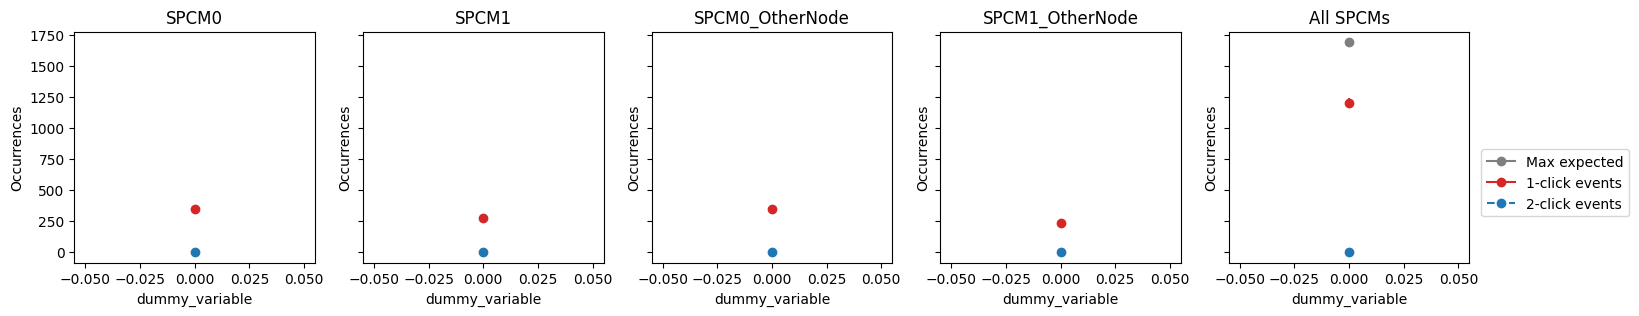

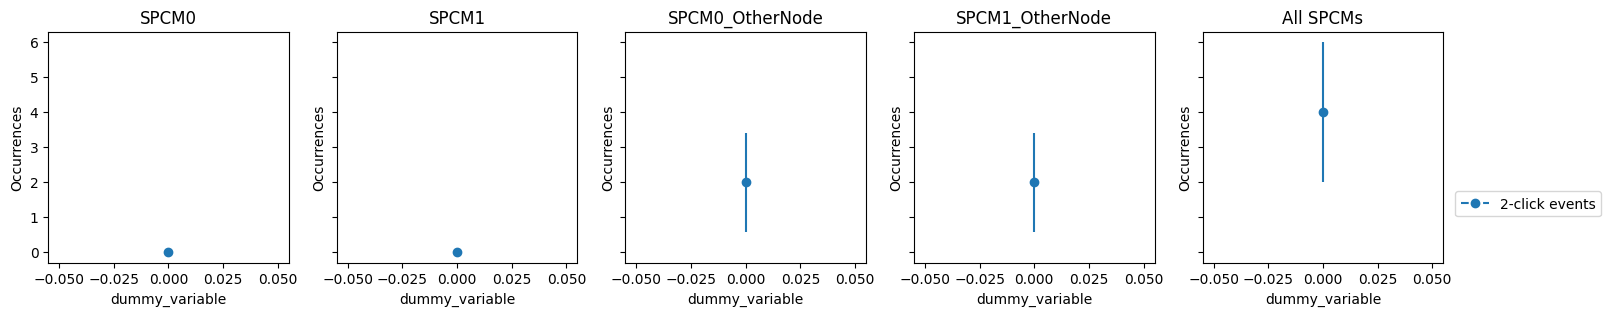

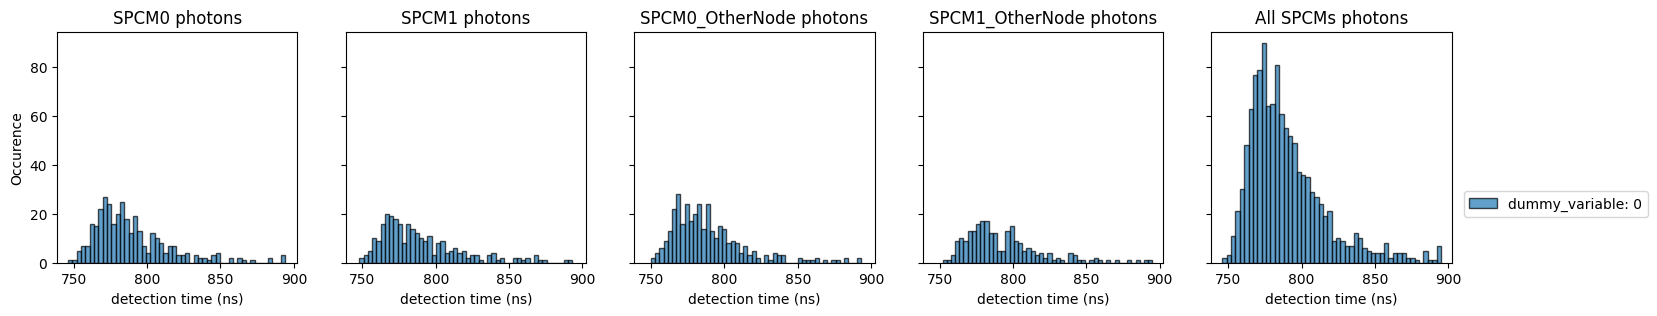

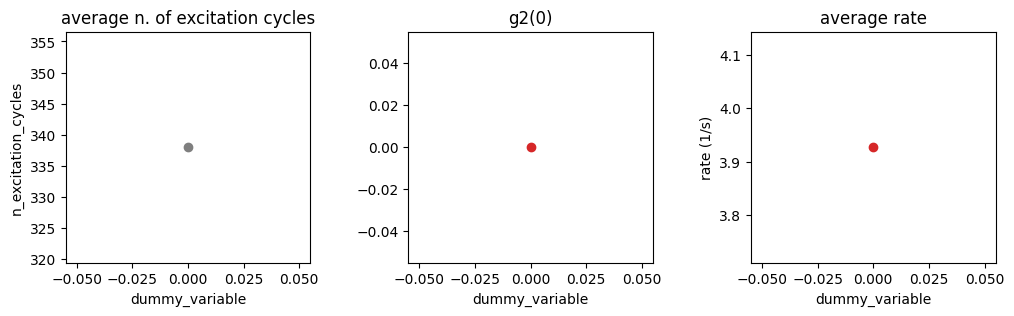

In [3]:
"""
What each variable represents. Example values are mostly from RID 22496, 2025-02-26. Variables ending in _iAll contain data for all interations with length equal to "iterations".

n_measurements = 2000: directly from dataset
iterations = 5: the length of scan_sequence1, directly from dataset
n_excitation_cycles = [0,  2, 20,  8,  2,  8, ...], length = 1 + n_measurements * iterations: the number of excitation cycles in each measurement
n_excitation_cycles_iAll = [16830, 16665, 16488, 16194, 16221], length = iterations: total number of excitation cycles in each iteration as an array.
n_excitation_attempts = 1: directly from dataset. Number of excitation pulses in each excitation cycle.
n_tStamps_iAll = [16830, 16665, 16488, 16194, 16221], length = iterations: total number of timestamps in each iteration as an array.
SPCM0_Photon_tStamps = [[0, 0], [-1, -1], [-1, -1], [1.32237714e+06, -1], [-1, -1], ...], length = sum(n_tStamps_iAll) = 82399, for example. Directly from dataset.
SPCM0_tStamps_i =  [[-1, -1], [-1, -1], [1.32237714e+06, -1], [-1, -1], ...], length = elements of n_tStamps_iAll, 16830 for the first iteration, for example. The timestamps in each iteration.
reference_tStamps_t1 = [0, 1322341.65973562, 1322341.65976682, 1322341.65979802, ...], length = sum(n_tStamps_iAll) = 82399, for example. Directly from dataset.
t1_reference_i = [1322341.65973562, 1322341.65976682, 1322341.65979802, ...], length = elements of n_tStamps_iAll, 16830 for the first iteration, for example. The reference times in each iteration.
SPCM0_1click_counts_iAll = [128., 122., 172., 186., 172.], length = iterations: number of 1-click events in each iteration as an array; events in the first column of SPCM0_tStamps_i for different iteration.
SPCM0_2click_counts_iAll = [0., 0., 0., 0., 0.], length = iterations: number of 2-click events in each iteration as an array; events in the second column of SPCM0_tStamps_i for different iteration.
start_indices = [0, 16830, 33495, 49983, 66177], length = iterations: to slice arrays like SPCM0_Photon_tStamps into iterations.
    Remember that SPCM0_Photon_tStamps is a single array with the timestamps for all iterations.
end_indices = [16830, 33495, 49983, 66177, 82398], length = iterations: same as start_indices
SPCM0_rel_tStamps_i = [1099.89196062, 1088.94892037, 1098.02931547, ...], length = SPCM0_1click_counts_iAll + SPCM0_2click_counts_iAll, for example length is 128 and 122 for first two iterations.
    This array contains the timestamps relative to the reference time t1 in ns unit. -1 event are excluded and 2-click events are included.
SPCM0_rel_tStamps_iAll = [[1099.89196062, 1088.94892037, 1098.02931547, ...], [..], ..], length = iterations. Arrays of arrays containing all the relative timestamps for all iteration.
AllSPCMs_tStamps_filtered_i = [[1757511.19383094, 1757533.11171639, ...], length = total number of photons in iteration i,
    i.e. length = all 1-click and 2-click counts from SPCM0, SPCM1, SPCM0_OtherNode, and SPCM1_OtherNode. Contains all the absolute time stamps from all 4 SPCMs with -1 removed and sorted from small to large.
AllSPCMs_tStamps_filtered_iAll = [[1757511.19383094, 1757533.11171639, ...], [1749316.29104084, 1749328.33163165, ..], ..], length = iterations. Array of arrays keeping all
    AllSPCMs_tStamps_filtered_i from all iterations.
Ave_photon_rate_iAll = [[0.11084697, 0.1147433 , 0.10952382, 0.1337287 , 0.12123424]], length = iterations. Contains the average photon generation rate for all iterations.
n_coincidence_iAll = [0,0,1,0,2], length = iterations. The number of coincidences in each iteration used to calculate g2.

Other notes:
1- Does this work if I change max_clicks from 2 to 1 or 3? The answer is no.

"""
show_photon_hist = True
### Print the title of the output
display(HTML(f"""<b style='font-size:18px;'> {date_filters[0]} - RID {rid} - {experiment_function}</b>"""))

Col_Eff = 0.05 # overal expected/theoretical collection and detection efficiency

### Instead of using a large n_measurements, which can sometimes lead to underflow error, we use dummy_variable to split the measurements.
### So, if scan_variable1_name == 'dummy_variable', we want to combine all iterations into one:
if scan_variable1_name == 'dummy_variable':
    n_measurements = n_measurements * iterations
    iterations = 1
    scan_sequence1 = [0]

## To look at specific iterations, you can select in scan_sequence_1, for example scan_sequence1 = [0,2]. For now, the first element has to be 0.
# scan_sequence1 = [0,4]
# iterations = len(scan_sequence1)
# n_measurements = n_measurements * iterations


n_excitation_cycles_iAll = np.zeros(iterations, dtype=int) ### total number of excitation cycle in each iteration.
n_tStamps_iAll = np.zeros(iterations, dtype=int)  ### number of timestamps in each iteration.
for i in range(iterations):
    n_excitation_cycles_iAll[i] = sum(n_excitation_cycles[i*n_measurements+1:(i+1)*n_measurements+1]+1)
    if scan_variable1_name == 'n_excitation_attempts':
        n_excitation_attempts = scan_sequence1[i]
    n_tStamps_iAll[i] = n_excitation_cycles_iAll[i] * n_excitation_attempts
    ### Note that n_excitation_cycles varies in each cycle, each contains n_excitation_attempts.
    ### the first +1 is because the first element in each dataset is 0.
    ### the last +1 is because there is one more cycle than n_excitation_cycles in each loop. See the oscciloscope. For example, if n_excitation_cycles[j] = 2,
    ### there are 2+1=3 sets of excitation cycles for that measurement.


SPCM0_1click_counts_iAll = np.array([])
SPCM0_2click_counts_iAll = np.array([])
SPCM1_1click_counts_iAll = np.array([])
SPCM1_2click_counts_iAll = np.array([])
SPCM0_OtherNode_1click_counts_iAll = np.array([])
SPCM0_OtherNode_2click_counts_iAll = np.array([])
SPCM1_OtherNode_1click_counts_iAll = np.array([])
SPCM1_OtherNode_2click_counts_iAll = np.array([])

AllSPCMs_tStamps_filtered_iAll = []

SPCM0_rel_tStamps_iAll = []
SPCM1_rel_tStamps_iAll = []
SPCM0_OtherNode_rel_tStamps_iAll = []
SPCM1_OtherNode_rel_tStamps_iAll = []

n_coincidence_iAll = np.zeros(iterations)
g2_0 = np.zeros(iterations)
g2_0_err = np.zeros(iterations)
Ave_photon_rate_iAll = np.zeros(iterations)


def get_rel_tStamps_i(tStamps_i, t1_reference_i, spcm_name):
    ### the timestamps relative to reference time. -1 events are excluded.
    rel_tStamps_i_temp = [row[row != -1] - ref for row, ref in zip(tStamps_i, t1_reference_i)]
    if not rel_tStamps_i_temp: ### np.concatenate crashes on empty lists; if no photon detected, I replace timetags by [0].
        rel_tStamps_i_temp = [[0]]
    rel_tStamps_i_temp2 = np.concatenate(rel_tStamps_i_temp) * 1e9 ## Flatten to combine 1-click and 2-click events.
    rel_tStamps_i = rel_tStamps_i_temp2[rel_tStamps_i_temp2 >= 0]
    ## in 1 out of 1million case, the reference time is later than the timetag and I get a negative
    ### element which messes up the histograms. I am simply removing these elements if any, and printing
    if len(rel_tStamps_i) != len(rel_tStamps_i_temp2):
        print(f'Early time stamp for {len(rel_tStamps_i_temp2) - len(rel_tStamps_i)} elements on {spcm_name} was detected.')
    return rel_tStamps_i


def get_tStamps_i(tStamps_all, start, end):
    tStamps_i = np.asarray(tStamps_all[1:][start:end])
    if tStamps_i.size == 0:
        return np.empty((0, 2))
    if tStamps_i.ndim == 1:
        return tStamps_i.reshape(-1, 2)
    return tStamps_i

SPCM0_Photon_tStamps = SPCM0_SinglePhoton_tStamps
SPCM1_Photon_tStamps = SPCM1_SinglePhoton_tStamps
SPCM0_OtherNode_Photon_tStamps = SPCM0_OtherNode_SinglePhoton_tStamps
SPCM1_OtherNode_Photon_tStamps = SPCM1_OtherNode_SinglePhoton_tStamps

### Calculate the ending and starting indices for the iterations
end_indices = np.cumsum(n_tStamps_iAll)
start_indices = np.insert(end_indices[:-1], 0, 0) ### prepend a 0 for the starting index

for i in range(iterations):
    start = start_indices[i]
    end = end_indices[i]
    SPCM0_tStamps_i = get_tStamps_i(SPCM0_Photon_tStamps, start, end)
    SPCM1_tStamps_i = get_tStamps_i(SPCM1_Photon_tStamps, start, end)
    SPCM0_OtherNode_tStamps_i = get_tStamps_i(SPCM0_OtherNode_Photon_tStamps, start, end)
    SPCM1_OtherNode_tStamps_i = get_tStamps_i(SPCM1_OtherNode_Photon_tStamps, start, end)
    t1_reference_i = reference_tStamps_t1[1:][start:end]

    ### number of 1-click events (the first column is none -1)
    SPCM0_1click_counts_iAll = np.append(SPCM0_1click_counts_iAll, np.count_nonzero(SPCM0_tStamps_i[:, 0] != -1))
    SPCM1_1click_counts_iAll = np.append(SPCM1_1click_counts_iAll, np.count_nonzero(SPCM1_tStamps_i[:, 0] != -1))
    SPCM0_OtherNode_1click_counts_iAll = np.append(SPCM0_OtherNode_1click_counts_iAll, np.count_nonzero(SPCM0_OtherNode_tStamps_i[:, 0] != -1))
    SPCM1_OtherNode_1click_counts_iAll = np.append(SPCM1_OtherNode_1click_counts_iAll, np.count_nonzero(SPCM1_OtherNode_tStamps_i[:, 0] != -1))

    ### number of 2-click events (the 2nd column is none -1)
    SPCM0_2click_counts_iAll = np.append(SPCM0_2click_counts_iAll, np.count_nonzero(SPCM0_tStamps_i[:, 1] != -1))
    SPCM1_2click_counts_iAll = np.append(SPCM1_2click_counts_iAll, np.count_nonzero(SPCM1_tStamps_i[:, 1] != -1))
    SPCM0_OtherNode_2click_counts_iAll = np.append(SPCM0_OtherNode_2click_counts_iAll, np.count_nonzero(SPCM0_OtherNode_tStamps_i[:, 1] != -1))
    SPCM1_OtherNode_2click_counts_iAll = np.append(SPCM1_OtherNode_2click_counts_iAll, np.count_nonzero(SPCM1_OtherNode_tStamps_i[:, 1] != -1))

    SPCM0_rel_tStamps_i = get_rel_tStamps_i(SPCM0_tStamps_i, t1_reference_i, 'SPCM0')
    SPCM1_rel_tStamps_i = get_rel_tStamps_i(SPCM1_tStamps_i, t1_reference_i, 'SPCM1')
    SPCM0_OtherNode_rel_tStamps_i = get_rel_tStamps_i(SPCM0_OtherNode_tStamps_i, t1_reference_i, 'SPCM0_OtherNode')
    SPCM1_OtherNode_rel_tStamps_i = get_rel_tStamps_i(SPCM1_OtherNode_tStamps_i, t1_reference_i, 'SPCM1_OtherNode')

    SPCM0_rel_tStamps_iAll.append(SPCM0_rel_tStamps_i)
    SPCM1_rel_tStamps_iAll.append(SPCM1_rel_tStamps_i)
    SPCM0_OtherNode_rel_tStamps_iAll.append(SPCM0_OtherNode_rel_tStamps_i)
    SPCM1_OtherNode_rel_tStamps_iAll.append(SPCM1_OtherNode_rel_tStamps_i)

    ### calculate g2 for each iteration. In future, we can also select a narrower coincidence window.
    ### For 4 SPCMs, count coincidences between all unordered detector pairs.
    first_click_arrays_i = [
        SPCM0_tStamps_i[:, 0],
        SPCM1_tStamps_i[:, 0],
        SPCM0_OtherNode_tStamps_i[:, 0],
        SPCM1_OtherNode_tStamps_i[:, 0],
    ]
    first_click_counts_i = [
        SPCM0_1click_counts_iAll[i],
        SPCM1_1click_counts_iAll[i],
        SPCM0_OtherNode_1click_counts_iAll[i],
        SPCM1_OtherNode_1click_counts_iAll[i],
    ]

    n_coincidence_i = 0
    g2_denominator_i = 0
    g2_denominator_var_i = 0
    for j in range(len(first_click_arrays_i)):
        for k in range(j + 1, len(first_click_arrays_i)):
            n_coincidence_i += np.sum((first_click_arrays_i[j] >= 1) & (first_click_arrays_i[k] >= 1))

            Nj = first_click_counts_i[j]
            Nk = first_click_counts_i[k]
            g2_denominator_i += Nj * Nk
            g2_denominator_var_i += (Nk**2) * Nj + (Nj**2) * Nk

    # n_coincidence_i = 1 ### if there is no coincidence, you can set n_coincidence_i = 1 manually to find the bound to g2 because the next count might be a coincidence.
    n_coincidence_iAll[i] = n_coincidence_i ### Having a list of coincidences for each iteration helps to learn more about the g2.

    if g2_denominator_i > 0:
        g2_0_temp = (n_coincidence_i / g2_denominator_i) * n_excitation_cycles_iAll[i]
        ### Errors for g2 results are from error propagation assuming Poissonian distribution for counts:
        if n_coincidence_i > 0:
            g2_0_err_temp = g2_0_temp * np.sqrt(1/n_coincidence_i + g2_denominator_var_i/(g2_denominator_i**2))
        else:
            g2_0_err_temp = np.nan
    else:
        g2_0_temp = np.nan
        g2_0_err_temp = np.nan
    g2_0[i] = g2_0_temp
    g2_0_err[i] = g2_0_err_temp

    ############## absolute timestamps of all the photons for rate analysis
    AllSPCMs_tStamps_flatten_i = np.concatenate((
        SPCM0_tStamps_i,
        SPCM1_tStamps_i,
        SPCM0_OtherNode_tStamps_i,
        SPCM1_OtherNode_tStamps_i,
    )).flatten() ### flatten to get the timestamps of all photons (1st and 2nd clicks).
    AllSPCMs_tStamps_filtered_i = AllSPCMs_tStamps_flatten_i[AllSPCMs_tStamps_flatten_i != -1]  ### -1 events are removed
    AllSPCMs_tStamps_filtered_i = np.sort(AllSPCMs_tStamps_filtered_i) ### sorted from small to large timestamps
    AllSPCMs_tStamps_filtered_iAll.append(AllSPCMs_tStamps_filtered_i)


    # ###########checking H1H2 ###############
    # count=0
    # for j in range(len(SPCM0_tStamps_i)):
    #     if SPCM0_tStamps_i[:, 0][j] != -1 and SPCM0_OtherNode_tStamps_i[:, 0][j] != -1:
    #         count+=1
    
    # print("H1H2 ", count)
    # ###########checking V1V2 ###############
    # count=0
    # for j in range(len(SPCM1_tStamps_i)):
    #     if SPCM1_tStamps_i[:, 0][j] != -1 and SPCM1_OtherNode_tStamps_i[:, 0][j] != -1:
    #         count+=1
    
    # print("V1V2 ",count)
    
    # ###########checking (H1orV1) (H2orV2) ###############
    # count=0
    # for j in range(len(SPCM1_tStamps_i)):
    #     if (SPCM0_tStamps_i[:, 0][j] != -1 or SPCM1_tStamps_i[:, 0][j] != -1) and (SPCM0_OtherNode_tStamps_i[:, 0][j] != -1 or SPCM1_OtherNode_tStamps_i[:, 0][j] != -1):
    #         count+=1
    
    # print("(H1orV1) (H2orV2) ",count)
    


AllSPCMs_1click_counts_iAll = (
    SPCM0_1click_counts_iAll
    + SPCM1_1click_counts_iAll
    + SPCM0_OtherNode_1click_counts_iAll
    + SPCM1_OtherNode_1click_counts_iAll
)
AllSPCMs_2click_counts_iAll = (
    SPCM0_2click_counts_iAll
    + SPCM1_2click_counts_iAll
    + SPCM0_OtherNode_2click_counts_iAll
    + SPCM1_OtherNode_2click_counts_iAll
)


print(f'n_measurements = {n_measurements}')
print(f'excitation pulse width = {t_excitation_pulse/10**-9}','ns')
print(f'SPCM window = {t_photon_collection_time/10**-9}', 'ns')
print(f'excitation AOM power (dBm) = {p_excitation}')
print(f'n_excitation_attempts = {n_excitation_attempts}')
print(f'check atom avery n excitation cycles = {atom_check_every_n}')
if n_excitation_cycles_iAll[0] > 0:
    print(f'Overal photon detection efficiency (%) = {100*AllSPCMs_1click_counts_iAll[0]/n_excitation_cycles_iAll[0]}')
else:
    print('Overal photon detection efficiency (%) = nan')



#############  Average photon generation rate calculated from last timestamp minus first timestamp.
for i in range(iterations):
    if len(AllSPCMs_tStamps_filtered_iAll[i]) >= 2:
        t_duration_i = max(AllSPCMs_tStamps_filtered_iAll[i]) - min(AllSPCMs_tStamps_filtered_iAll[i])
        if t_duration_i > 0:
            Ave_photon_rate_iAll[i] = (AllSPCMs_1click_counts_iAll[i] + AllSPCMs_2click_counts_iAll[i]) / t_duration_i
        else:
            Ave_photon_rate_iAll[i] = np.nan
    else:
        Ave_photon_rate_iAll[i] = np.nan


###################################################### plot of 1-click and 2-click counts
fig, axs = plt.subplots(1, 5, figsize=(18, 3), sharey=True)

### SPCM0
axs[0].plot(scan_sequence1, SPCM0_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[0].plot(scan_sequence1, SPCM0_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
axs[0].errorbar(scan_sequence1, SPCM0_1click_counts_iAll, yerr=np.sqrt(SPCM0_1click_counts_iAll), ls='none', color='tab:red')
axs[0].errorbar(scan_sequence1, SPCM0_2click_counts_iAll, yerr=np.sqrt(SPCM0_2click_counts_iAll), ls='none', color='tab:blue')
axs[0].set_title('SPCM0')
axs[0].set_ylabel('Occurrences')
axs[0].set_xlabel(scan_variable1_name);

### SPCM1
axs[1].plot(scan_sequence1, SPCM1_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[1].plot(scan_sequence1, SPCM1_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
axs[1].errorbar(scan_sequence1, SPCM1_1click_counts_iAll, yerr=np.sqrt(SPCM1_1click_counts_iAll), ls='none', color='tab:red')
axs[1].errorbar(scan_sequence1, SPCM1_2click_counts_iAll, yerr=np.sqrt(SPCM1_2click_counts_iAll), ls='none', color='tab:blue')
axs[1].set_title('SPCM1')
axs[1].set_ylabel('Occurrences')
axs[1].set_xlabel(scan_variable1_name);

### SPCM0_OtherNode
axs[2].plot(scan_sequence1, SPCM0_OtherNode_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[2].plot(scan_sequence1, SPCM0_OtherNode_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
axs[2].errorbar(scan_sequence1, SPCM0_OtherNode_1click_counts_iAll, yerr=np.sqrt(SPCM0_OtherNode_1click_counts_iAll), ls='none', color='tab:red')
axs[2].errorbar(scan_sequence1, SPCM0_OtherNode_2click_counts_iAll, yerr=np.sqrt(SPCM0_OtherNode_2click_counts_iAll), ls='none', color='tab:blue')
axs[2].set_title('SPCM0_OtherNode')
axs[2].set_ylabel('Occurrences')
axs[2].set_xlabel(scan_variable1_name);

### SPCM1_OtherNode
axs[3].plot(scan_sequence1, SPCM1_OtherNode_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[3].plot(scan_sequence1, SPCM1_OtherNode_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
axs[3].errorbar(scan_sequence1, SPCM1_OtherNode_1click_counts_iAll, yerr=np.sqrt(SPCM1_OtherNode_1click_counts_iAll), ls='none', color='tab:red')
axs[3].errorbar(scan_sequence1, SPCM1_OtherNode_2click_counts_iAll, yerr=np.sqrt(SPCM1_OtherNode_2click_counts_iAll), ls='none', color='tab:blue')
axs[3].set_title('SPCM1_OtherNode')
axs[3].set_ylabel('Occurrences')
axs[3].set_xlabel(scan_variable1_name);

### all SPCMs
axs[4].plot(scan_sequence1, n_excitation_cycles_iAll * Col_Eff, label='Max expected', ls='solid', color='tab:gray', marker='o') ### I assumed only one excitation can happen with n_excitation_attempts
axs[4].plot(scan_sequence1, AllSPCMs_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[4].plot(scan_sequence1, AllSPCMs_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
axs[4].errorbar(scan_sequence1, AllSPCMs_1click_counts_iAll, yerr=np.sqrt(AllSPCMs_1click_counts_iAll), ls='none', color='tab:red')
axs[4].errorbar(scan_sequence1, AllSPCMs_2click_counts_iAll, yerr=np.sqrt(AllSPCMs_2click_counts_iAll), ls='none', color='tab:blue')
axs[4].set_title('All SPCMs')
axs[4].set_ylabel('Occurrences')
axs[4].set_xlabel(scan_variable1_name);
axs[4].legend(loc=(1.05,0.2))
##########################################################################################




###################################################### plot of 2-click counts
fig, axs = plt.subplots(1, 5, figsize=(18, 3), sharey=True)

### SPCM0
# axs[0].plot(scan_sequence1, SPCM0_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[0].plot(scan_sequence1, SPCM0_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
# axs[0].errorbar(scan_sequence1, SPCM0_1click_counts_iAll, yerr=np.sqrt(SPCM0_1click_counts_iAll), ls='none', color='tab:red')
axs[0].errorbar(scan_sequence1, SPCM0_2click_counts_iAll, yerr=np.sqrt(SPCM0_2click_counts_iAll), ls='none', color='tab:blue')
axs[0].set_title('SPCM0')
axs[0].set_ylabel('Occurrences')
axs[0].set_xlabel(scan_variable1_name);

### SPCM1
# axs[1].plot(scan_sequence1, SPCM1_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[1].plot(scan_sequence1, SPCM1_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
# axs[1].errorbar(scan_sequence1, SPCM1_1click_counts_iAll, yerr=np.sqrt(SPCM1_1click_counts_iAll), ls='none', color='tab:red')
axs[1].errorbar(scan_sequence1, SPCM1_2click_counts_iAll, yerr=np.sqrt(SPCM1_2click_counts_iAll), ls='none', color='tab:blue')
axs[1].set_title('SPCM1')
axs[1].set_ylabel('Occurrences')
axs[1].set_xlabel(scan_variable1_name);

### SPCM0_OtherNode
# axs[2].plot(scan_sequence1, SPCM0_OtherNode_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[2].plot(scan_sequence1, SPCM0_OtherNode_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
# axs[2].errorbar(scan_sequence1, SPCM0_OtherNode_1click_counts_iAll, yerr=np.sqrt(SPCM0_OtherNode_1click_counts_iAll), ls='none', color='tab:red')
axs[2].errorbar(scan_sequence1, SPCM0_OtherNode_2click_counts_iAll, yerr=np.sqrt(SPCM0_OtherNode_2click_counts_iAll), ls='none', color='tab:blue')
axs[2].set_title('SPCM0_OtherNode')
axs[2].set_ylabel('Occurrences')
axs[2].set_xlabel(scan_variable1_name);

### SPCM1_OtherNode
# axs[3].plot(scan_sequence1, SPCM1_OtherNode_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[3].plot(scan_sequence1, SPCM1_OtherNode_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
# axs[3].errorbar(scan_sequence1, SPCM1_OtherNode_1click_counts_iAll, yerr=np.sqrt(SPCM1_OtherNode_1click_counts_iAll), ls='none', color='tab:red')
axs[3].errorbar(scan_sequence1, SPCM1_OtherNode_2click_counts_iAll, yerr=np.sqrt(SPCM1_OtherNode_2click_counts_iAll), ls='none', color='tab:blue')
axs[3].set_title('SPCM1_OtherNode')
axs[3].set_ylabel('Occurrences')
axs[3].set_xlabel(scan_variable1_name);

### all SPCMs
# axs[4].plot(scan_sequence1, n_excitation_cycles_iAll * Col_Eff, label='Max expected', ls='solid', color='tab:gray', marker='o') ### I assumed only one excitation can happen with n_excitation_attempts
# axs[4].plot(scan_sequence1, AllSPCMs_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[4].plot(scan_sequence1, AllSPCMs_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
# axs[4].errorbar(scan_sequence1, AllSPCMs_1click_counts_iAll, yerr=np.sqrt(AllSPCMs_1click_counts_iAll), ls='none', color='tab:red')
axs[4].errorbar(scan_sequence1, AllSPCMs_2click_counts_iAll, yerr=np.sqrt(AllSPCMs_2click_counts_iAll), ls='none', color='tab:blue')
axs[4].set_title('All SPCMs')
axs[4].set_ylabel('Occurrences')
axs[4].set_xlabel(scan_variable1_name);
axs[4].legend(loc=(1.05,0.2))
##########################################################################################


AllSPCMs_rel_tStamps_iAll = [
    np.concatenate((spcm0, spcm1, spcm0_other, spcm1_other))
    for spcm0, spcm1, spcm0_other, spcm1_other in zip(
        SPCM0_rel_tStamps_iAll,
        SPCM1_rel_tStamps_iAll,
        SPCM0_OtherNode_rel_tStamps_iAll,
        SPCM1_OtherNode_rel_tStamps_iAll,
    )
]

###################################################### plot of photon histograms
if show_photon_hist:
    for i in range(iterations):
        fig, axs = plt.subplots(1, 5, figsize=(18, 3), sharey=True, sharex=True)
    
        axs[0].hist(SPCM0_rel_tStamps_iAll[i], bins=50, edgecolor='black', alpha=0.7)
        axs[0].set_xlabel("detection time (ns)")
        axs[0].set_ylabel("Occurence")
        axs[0].set_title("SPCM0 photons")
    
        axs[1].hist(SPCM1_rel_tStamps_iAll[i], bins=50, edgecolor='black', alpha=0.7)
        axs[1].set_xlabel("detection time (ns)")
        axs[1].set_title("SPCM1 photons");
    
        axs[2].hist(SPCM0_OtherNode_rel_tStamps_iAll[i], bins=50, edgecolor='black', alpha=0.7)
        axs[2].set_xlabel("detection time (ns)")
        axs[2].set_title("SPCM0_OtherNode photons")
    
        axs[3].hist(SPCM1_OtherNode_rel_tStamps_iAll[i], bins=50, edgecolor='black', alpha=0.7)
        axs[3].set_xlabel("detection time (ns)")
        axs[3].set_title("SPCM1_OtherNode photons");
    
        axs[4].hist(AllSPCMs_rel_tStamps_iAll[i], bins=50, edgecolor='black', alpha=0.7, label=f'{scan_variable1_name}: {scan_sequence1[i]}')
        axs[4].set_xlabel("detection time (ns)")
        axs[4].set_title("All SPCMs photons")
        axs[4].legend(loc=(1.05, 0.2))
##########################################################################################


fig, axs = plt.subplots(1, 3, figsize=(12, 3))
########################################## Plot average number of excitation_cycles per measuremnt
axs[0].plot(scan_sequence1, n_excitation_cycles_iAll/n_measurements, label='ave excitation cycle', marker='o', color='tab:gray')
axs[0].set_xlabel(scan_variable1_name)
axs[0].set_ylabel('n_excitation_cycles')
axs[0].set_title('average n. of excitation cycles')

########################################## Plot g2
axs[1].plot(scan_sequence1, g2_0, marker='o', color='tab:red')
axs[1].errorbar(scan_sequence1, g2_0, yerr=g2_0_err, ls='none',color='tab:red')
axs[1].set_xlabel(scan_variable1_name)
# axs[1].set_ylabel('g2(0)')
axs[1].set_title('g2(0)');

########################################## Plot avergae rate
axs[2].plot(scan_sequence1, Ave_photon_rate_iAll, marker='o', color='tab:red')
# axs[2].legend(loc=(1.05,0.5))
axs[2].set_xlabel(scan_variable1_name)
axs[2].set_ylabel('rate (1/s)')
axs[2].set_title('average rate');

plt.subplots_adjust(wspace=0.4)  # Increase spacing between subplots
plt.show()


In [63]:
gate_start_offset_mu

np.int32(700)

In [10]:
n_excitation_cycles_iAll/n_measurements, Ave_photon_rate_iAll

(array([256.1175]), array([3.65677534]))

### Duplicate of above; choosing 1st attempt

# of coincidences: 2
# of SPCM0 1 click: 7208.0
# of SPCM1 1 click: 5254.0
SPCM0_2click_counts_iAll 67.0
SPCM1_2click_counts_iAll 14.0
----
# of total SPCM0 counts: 7342.0
# of total SPCM1 counts: 5282.0
 n_excitation_cycles_iAll[i] 1024470 
----
 (SPCM0 clicks + SPCM1 clicks)/(total exc cycles) = 0.012322469179185334
n_measurements = 4000
excitation pulse width = 30.000000000000004 ns
SPCM window = 200.0 ns
excitation AOM power (dBm) = -10.0
n_excitation_attempts = 4
check atom avery n excitation cycles = 30


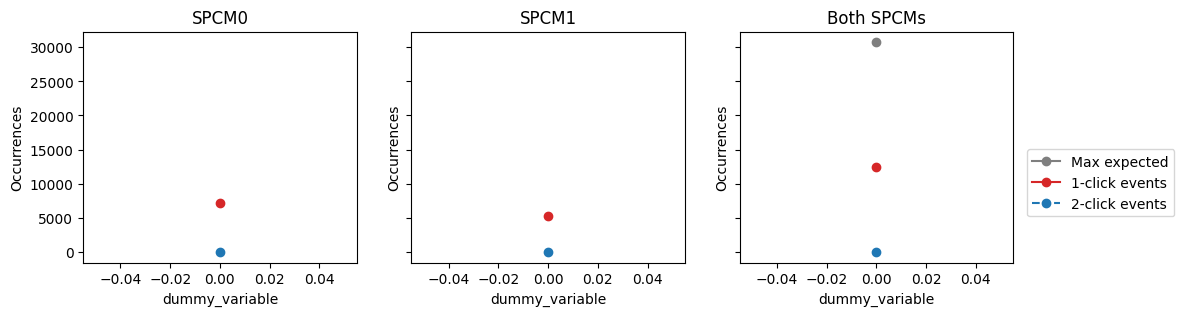

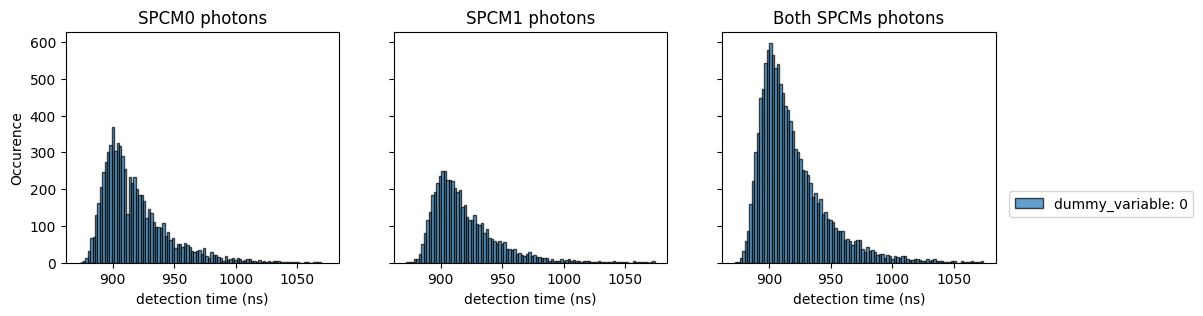

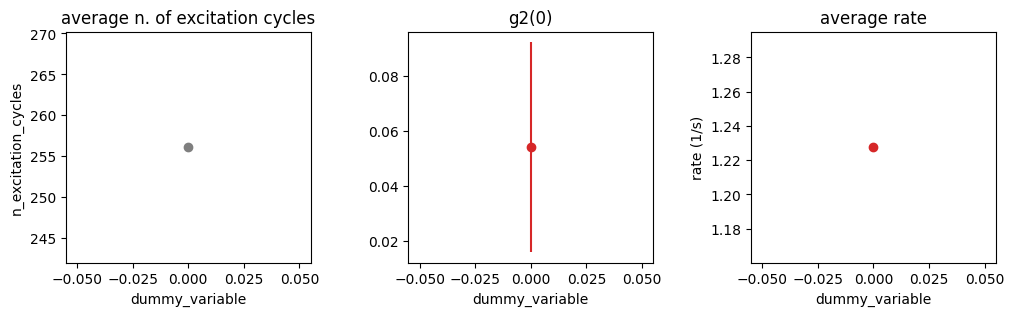

In [24]:
"""
Duplicate of above;
choosing only 1st attempt

"""

### Print the title of the output
display(HTML(f"""<b style='font-size:18px;'> {date_filters[0]} - RID {rid} - {experiment_function}</b>"""))

Col_Eff = 0.03 # overal expected/theoretical collection and detection efficiency 

### Instead of using a large n_measurements, which can sometimes lead to underflow error, we use dummy_variable to split the measurements. 
### So, if scan_variable1_name == 'dummy_variable', we want to combine all iterations into one:
if scan_variable1_name == 'dummy_variable':
    n_measurements = n_measurements * iterations
    iterations = 1
    scan_sequence1 = [0]

## To look at specific iterations, you can select in scan_sequence_1, for example scan_sequence1 = [0,2]. For now, the first element has to be 0.
# scan_sequence1 = [0,4]
# iterations = len(scan_sequence1)
# n_measurements = n_measurements * iterations


n_excitation_cycles_iAll = np.zeros(iterations, dtype=int) ### total number of excitation cycle in each iteration.
n_tStamps_iAll = np.zeros(iterations, dtype=int)  ### number of timestamps in each iteration. 
for i in range(iterations):
    n_excitation_cycles_iAll[i] = sum(n_excitation_cycles[i*n_measurements+1:(i+1)*n_measurements+1]+1)
    if scan_variable1_name == 'n_excitation_attempts':
        n_excitation_attempts = scan_sequence1[i]
    n_tStamps_iAll[i] = n_excitation_cycles_iAll[i] * n_excitation_attempts
    ### Note that n_excitation_cycles varies in each cycle, each contains n_excitation_attempts.
    ### the first +1 is because the first element in each dataset is 0. 
    ### the last +1 is because there is one more cycle than n_excitation_cycles in each loop. See the oscciloscope. For example, if n_excitation_cycles[j] = 2, 
    ### there are 2+1=3 sets of excitation cycles for that measurement. 
   


SPCM0_1click_counts_iAll = np.array([])
SPCM0_2click_counts_iAll = np.array([])
SPCM1_1click_counts_iAll = np.array([])
SPCM1_2click_counts_iAll = np.array([])

BothSPCMs_tStamps_filtered_iAll = []
SPCM0_tStamps_filtered_iAll = []
SPCM1_tStamps_filtered_iAll = []


SPCM0_rel_tStamps_iAll = []
SPCM1_rel_tStamps_iAll = []

g2_0= np.zeros(iterations)
g2_0_err= np.zeros(iterations)
Ave_photon_rate_iAll = np.zeros(iterations)

### Calculate the ending and starting indices for the iterations
end_indices = np.cumsum(n_tStamps_iAll)
start_indices = np.insert(end_indices[:-1], 0, 0) ### prepend a 0 for the starting index

for i in range(iterations):
    start = start_indices[i]
    end = end_indices[i]
    SPCM0_tStamps_i = SPCM0_SinglePhoton_tStamps[1:][start:end]
    SPCM1_tStamps_i = SPCM1_SinglePhoton_tStamps[1:][start:end]
    t1_reference_i = reference_tStamps_t1[1:][start:end]

    # # ################################# SPCM1 counts arrive ~40ns later #################################
    # if apply_delay_in_SPCM1:
    # shift = -40*1e-9
    # np.add(SPCM1_tStamps_i, shift, out=SPCM1_tStamps_i, where=SPCM1_tStamps_i >= -1)

    idx = np.arange(SPCM0_tStamps_i.shape[0]) % 3 == 0

    ### number of 1-click events (the first column in SPCM0_tStamps_i is none -1)
    SPCM0_1click_counts_iAll = np.append(SPCM0_1click_counts_iAll, np.count_nonzero(SPCM0_tStamps_i[::3, 0] != -1))
    ### number of 2-click events (the 2nd column in SPCM0_tStamps_i is none -1)
    SPCM0_2click_counts_iAll = np.append(SPCM0_2click_counts_iAll, np.count_nonzero(SPCM0_tStamps_i[::3, 1] != -1))

    ### number of 1-click events (the first column in SPCM1_tStamps_i is none -1)
    SPCM1_1click_counts_iAll = np.append(SPCM1_1click_counts_iAll, np.count_nonzero(SPCM1_tStamps_i[::3, 0] != -1))
    ### number of 2-click events (the 2nd column in SPCM1_tStamps_i is none -1)
    SPCM1_2click_counts_iAll = np.append(SPCM1_2click_counts_iAll, np.count_nonzero(SPCM1_tStamps_i[::3, 1] != -1))

    SPCM0_total_counts = SPCM0_1click_counts_iAll[i] + 2*SPCM0_2click_counts_iAll[i]
    SPCM1_total_counts = SPCM1_1click_counts_iAll[i] + 2*SPCM1_2click_counts_iAll[i]
    
    # ### the timestamps relative to reference time. -1 events are excluded.
    # SPCM0_rel_tStamps_i_temp = [row[row != -1] - ref for row, ref in zip(SPCM0_tStamps_i, t1_reference_i)]
    # if not SPCM0_rel_tStamps_i_temp: ### np.concatenate crashes on empty lists; if no photon detected, I replace timetags by [0].
    #     SPCM0_rel_tStamps_i_temp = [[0]]
    # SPCM0_rel_tStamps_i_temp2 = np.concatenate(SPCM0_rel_tStamps_i_temp) * 1e9 ## Flatten to combine 1-click and 2-click events.
    # SPCM0_rel_tStamps_i = SPCM0_rel_tStamps_i_temp2[SPCM0_rel_tStamps_i_temp2 >= 0] 
    # ## in 1 out of 1million case, the reference time is later than the timetag and I get a negative 
    # ### SPCM0_rel_tStamps_i element which messes up the histograms. I am simply removing these elements if any, and printing
    # if len(SPCM0_rel_tStamps_i) != len(SPCM0_rel_tStamps_i_temp2):
    #     print(f'Early time stamp for {len(SPCM0_rel_tStamps_i_temp2) - len(SPCM0_rel_tStamps_i)} elements on SPCM0 was detected.')
    # SPCM0_rel_tStamps_iAll.append(SPCM0_rel_tStamps_i)  


    
    # SPCM1_rel_tStamps_i_temp = [row[row != -1] - ref for row, ref in zip(SPCM1_tStamps_i, t1_reference_i)]
    # if not SPCM1_rel_tStamps_i_temp:
    #     SPCM1_rel_tStamps_i_temp = [[0]]
    # SPCM1_rel_tStamps_i_temp2 = np.concatenate(SPCM1_rel_tStamps_i_temp) * 1e9 ## Flatten to combine 1-click and 2-click events.
    # SPCM1_rel_tStamps_i = SPCM1_rel_tStamps_i_temp2[SPCM1_rel_tStamps_i_temp2 >= 0] 
    # if len(SPCM1_rel_tStamps_i) != len(SPCM1_rel_tStamps_i_temp2):
    #     print(f'Early time stamp for {len(SPCM1_rel_tStamps_i_temp2) - len(SPCM1_rel_tStamps_i)} elements on SPCM1 was detected.')
    # SPCM1_rel_tStamps_iAll.append(SPCM1_rel_tStamps_i)


    # 0,3,6,... row 인덱스만 선택
    idx = (np.arange(SPCM0_tStamps_i.shape[0]) % 3 == 0)
    
    SPCM0_tStamps_i_sub = SPCM0_tStamps_i[idx, :]
    SPCM1_tStamps_i_sub = SPCM1_tStamps_i[idx, :]
    t1_reference_i_sub  = t1_reference_i[idx]
    
    
    ### the timestamps relative to reference time. -1 events are excluded.
    SPCM0_rel_tStamps_i_temp = [row[row != -1] - ref
                               for row, ref in zip(SPCM0_tStamps_i_sub, t1_reference_i_sub)]
    if not SPCM0_rel_tStamps_i_temp:  # np.concatenate crashes on empty lists
        SPCM0_rel_tStamps_i_temp = [[0]]
    
    SPCM0_rel_tStamps_i_temp2 = np.concatenate(SPCM0_rel_tStamps_i_temp) * 1e9
    SPCM0_rel_tStamps_i = SPCM0_rel_tStamps_i_temp2[SPCM0_rel_tStamps_i_temp2 >= 0]
    
    if len(SPCM0_rel_tStamps_i) != len(SPCM0_rel_tStamps_i_temp2):
        print(f'Early time stamp for {len(SPCM0_rel_tStamps_i_temp2) - len(SPCM0_rel_tStamps_i)} elements on SPCM0 was detected.')
    SPCM0_rel_tStamps_iAll.append(SPCM0_rel_tStamps_i)
    
    
    SPCM1_rel_tStamps_i_temp = [row[row != -1] - ref
                               for row, ref in zip(SPCM1_tStamps_i_sub, t1_reference_i_sub)]
    if not SPCM1_rel_tStamps_i_temp:
        SPCM1_rel_tStamps_i_temp = [[0]]
    
    SPCM1_rel_tStamps_i_temp2 = np.concatenate(SPCM1_rel_tStamps_i_temp) * 1e9
    SPCM1_rel_tStamps_i = SPCM1_rel_tStamps_i_temp2[SPCM1_rel_tStamps_i_temp2 >= 0]
    
    if len(SPCM1_rel_tStamps_i) != len(SPCM1_rel_tStamps_i_temp2):
        print(f'Early time stamp for {len(SPCM1_rel_tStamps_i_temp2) - len(SPCM1_rel_tStamps_i)} elements on SPCM1 was detected.')
    SPCM1_rel_tStamps_iAll.append(SPCM1_rel_tStamps_i)


    


    # ################################# SPCM1 counts arrive ~40ns later #################################
    # ## there is a delay in SPCM1 ttl count detection
    # if apply_delay_in_SPCM1:
    #     SPCM1_rel_tStamps_iAll_copy = [SPCM1_rel_tStamps_iAll[0] + shift]

        
    ############################### g2 calculation #############################
    ### calculate g2 for each iteration. In future, we can also select a narrower coincidence window. Right now the coincidence window is the entire gate window (about 300ns).
    n_coincidence_i = np.sum((SPCM0_tStamps_i[:,0] >= 1) & (SPCM1_tStamps_i[:,0] >= 1)) ### looking at the first clicks for coincidences.
    # n_coincidence_i = 1 ### if there is no coincidence, you can set n_coincidence_i = 1 manually to find the bound to g2 because the next count might be a coincidence.
    if SPCM0_1click_counts_iAll[i] > 0 and SPCM1_1click_counts_iAll[i] > 0:
        g2_0_temp = (n_coincidence_i / 
                  (SPCM0_1click_counts_iAll[i] * SPCM1_1click_counts_iAll[i])) * n_excitation_cycles_iAll[i]
        ### Errors for g2 results are from error propagation assuming Poissonian distribution for counts:
        if n_coincidence_i > 0:
            g2_0_err_temp = g2_0_temp * np.sqrt(1/n_coincidence_i + 1/SPCM0_1click_counts_iAll[i] + 1/SPCM1_1click_counts_iAll[i])
        else:
            g2_0_err_temp = np.nan
    else:
        g2_0_temp = np.nan 
        g2_0_err_temp = np.nan
    g2_0[i] = g2_0_temp
    g2_0_err[i] = g2_0_err_temp

    print(f"# of coincidences: {n_coincidence_i}")
    print(f"# of SPCM0 1 click: {SPCM0_1click_counts_iAll[i]}")
    print(f"# of SPCM1 1 click: {(SPCM1_1click_counts_iAll[i])}")
    print(f"SPCM0_2click_counts_iAll {SPCM0_2click_counts_iAll[i]}")
    print(f"SPCM1_2click_counts_iAll {SPCM1_2click_counts_iAll[i]}")
    print("----")
    print(f"# of total SPCM0 counts: {SPCM0_total_counts}")
    print(f"# of total SPCM1 counts: {SPCM1_total_counts}")
    print(f" n_excitation_cycles_iAll[i] { n_excitation_cycles_iAll[i]} ")
    print("----")
    print(f" (SPCM0 clicks + SPCM1 clicks)/(total exc cycles) = {(SPCM0_total_counts+SPCM1_total_counts)/(n_excitation_cycles_iAll[i])}")

    ############## absolute timestamps of all the photons for rate analysis
    BothSPCMs_tStamps_flatten_i = np.concatenate((SPCM0_tStamps_i, SPCM1_tStamps_i)).flatten() ### flatten to get the timestamps of all photons (1st and 2nd clicks).
    BothSPCMs_tStamps_filtered_i = BothSPCMs_tStamps_flatten_i[BothSPCMs_tStamps_flatten_i != -1]  ### -1 events are removed
    BothSPCMs_tStamps_filtered_i = np.sort(BothSPCMs_tStamps_filtered_i) ### sorted from small to large timestamps
    BothSPCMs_tStamps_filtered_iAll.append(BothSPCMs_tStamps_filtered_i)

    ############## absolute timestamps of all the photons for rate analysis
    SPCM0_tStamps_flatten_i = np.concatenate(SPCM0_tStamps_i).flatten() ### flatten to get the timestamps of all photons (1st and 2nd clicks).
    SPCM0_tStamps_filtered_i = SPCM0_tStamps_flatten_i[SPCM0_tStamps_flatten_i != -1]  ### -1 events are removed
    SPCM0_tStamps_filtered_i = np.sort(SPCM0_tStamps_filtered_i) ### sorted from small to large timestamps
    SPCM0_tStamps_filtered_iAll.append(SPCM0_tStamps_filtered_i)

    ############## absolute timestamps of all the photons for rate analysis
    SPCM1_tStamps_flatten_i = np.concatenate(SPCM1_tStamps_i).flatten() ### flatten to get the timestamps of all photons (1st and 2nd clicks).
    SPCM1_tStamps_filtered_i = SPCM1_tStamps_flatten_i[SPCM1_tStamps_flatten_i != -1]  ### -1 events are removed
    SPCM1_tStamps_filtered_i = np.sort(SPCM1_tStamps_filtered_i) ### sorted from small to large timestamps
    SPCM1_tStamps_filtered_iAll.append(SPCM1_tStamps_filtered_i)

    


print(f'n_measurements = {n_measurements}')
print(f'excitation pulse width = {t_excitation_pulse/10**-9}','ns')
print(f'SPCM window = {t_photon_collection_time/10**-9}', 'ns')
print(f'excitation AOM power (dBm) = {p_GRIN2_excitation}')
print(f'n_excitation_attempts = {n_excitation_attempts}')
print(f'check atom avery n excitation cycles = {atom_check_every_n}')


BothSPCMs_1click_counts_iAll = SPCM0_1click_counts_iAll + SPCM1_1click_counts_iAll
BothSPCMs_2click_counts_iAll = SPCM0_2click_counts_iAll + SPCM1_2click_counts_iAll

#############  Average photon generation rate calculated from last timestamp minus first timestamp.
for i in range(iterations):
    Ave_photon_rate_iAll[i] = (BothSPCMs_1click_counts_iAll[i] + BothSPCMs_2click_counts_iAll[i]) / (max(BothSPCMs_tStamps_filtered_iAll[i])-min(BothSPCMs_tStamps_filtered_iAll[i]))
    

###################################################### plot of 1-click and 2-click counts
fig, axs = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

### SPCM0
axs[0].plot(scan_sequence1, SPCM0_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[0].plot(scan_sequence1, SPCM0_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
axs[0].errorbar(scan_sequence1, SPCM0_1click_counts_iAll, yerr=np.sqrt(SPCM0_1click_counts_iAll), ls='none', color='tab:red')
axs[0].errorbar(scan_sequence1, SPCM0_2click_counts_iAll, yerr=np.sqrt(SPCM0_2click_counts_iAll), ls='none', color='tab:blue')
axs[0].set_title('SPCM0')
axs[0].set_ylabel('Occurrences')
axs[0].set_xlabel(scan_variable1_name);

### SPCM1
axs[1].plot(scan_sequence1, SPCM1_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[1].plot(scan_sequence1, SPCM1_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
axs[1].errorbar(scan_sequence1, SPCM1_1click_counts_iAll, yerr=np.sqrt(SPCM1_1click_counts_iAll), ls='none', color='tab:red')
axs[1].errorbar(scan_sequence1, SPCM1_2click_counts_iAll, yerr=np.sqrt(SPCM1_2click_counts_iAll), ls='none', color='tab:blue')
axs[1].set_title('SPCM1')
axs[1].set_ylabel('Occurrences')
axs[1].set_xlabel(scan_variable1_name);

### both SPCMs
axs[2].plot(scan_sequence1, n_excitation_cycles_iAll * Col_Eff, label='Max expected', ls='solid', color='tab:gray', marker='o') ### I assumed only one excitation can happen with n_excitation_attempts
axs[2].plot(scan_sequence1, BothSPCMs_1click_counts_iAll, label='1-click events', ls='solid', color='tab:red', marker='o')
axs[2].plot(scan_sequence1, BothSPCMs_2click_counts_iAll, label='2-click events', ls='dashed', color='tab:blue', marker='o')
axs[2].errorbar(scan_sequence1, BothSPCMs_1click_counts_iAll, yerr=np.sqrt(BothSPCMs_1click_counts_iAll), ls='none', color='tab:red')
axs[2].errorbar(scan_sequence1, BothSPCMs_2click_counts_iAll, yerr=np.sqrt(BothSPCMs_2click_counts_iAll), ls='none', color='tab:blue')
axs[2].set_title('Both SPCMs')
axs[2].set_ylabel('Occurrences')
axs[2].set_xlabel(scan_variable1_name);
axs[2].legend(loc=(1.05,0.2))
##########################################################################################


BothSPCMs_rel_tStamps_iAll = [np.concatenate((spcm0, spcm1)) for spcm0, spcm1 in zip(SPCM0_rel_tStamps_iAll, SPCM1_rel_tStamps_iAll)]

###################################################### plot of photon histograms
for i in range(iterations):
    fig, axs = plt.subplots(1, 3, figsize=(12, 3), sharey=True, sharex=True)
    
    axs[0].hist(SPCM0_rel_tStamps_iAll[i], bins=100, edgecolor='black', alpha=0.7)
    axs[0].set_xlabel("detection time (ns)")
    axs[0].set_ylabel("Occurence")
    axs[0].set_title("SPCM0 photons")
    
    axs[1].hist(SPCM1_rel_tStamps_iAll[i], bins=100, edgecolor='black', alpha=0.7)
    axs[1].set_xlabel("detection time (ns)")
    axs[1].set_title("SPCM1 photons");

    axs[2].hist(BothSPCMs_rel_tStamps_iAll[i], bins=100, edgecolor='black', alpha=0.7, label=f'{scan_variable1_name}: {scan_sequence1[i]}')
    axs[2].set_xlabel("detection time (ns)")
    axs[2].set_title("Both SPCMs photons")
    axs[2].legend(loc=(1.05, 0.2))
##########################################################################################


fig, axs = plt.subplots(1, 3, figsize=(12, 3))
########################################## Plot average number of excitation_cycles per measuremnt
axs[0].plot(scan_sequence1, n_excitation_cycles_iAll/n_measurements, label='ave excitation cycle', marker='o', color='tab:gray')
axs[0].set_xlabel(scan_variable1_name)
axs[0].set_ylabel('n_excitation_cycles')
axs[0].set_title('average n. of excitation cycles')

########################################## Plot g2
axs[1].plot(scan_sequence1, g2_0, marker='o', color='tab:red')
axs[1].errorbar(scan_sequence1, g2_0, yerr=g2_0_err, ls='none',color='tab:red')
axs[1].set_xlabel(scan_variable1_name)
# axs[1].set_ylabel('g2(0)')
axs[1].set_title('g2(0)');

########################################## Plot avergae rate
axs[2].plot(scan_sequence1, Ave_photon_rate_iAll, marker='o', color='tab:red')
# axs[2].legend(loc=(1.05,0.5))
axs[2].set_xlabel(scan_variable1_name)
axs[2].set_ylabel('rate (1/s)')
axs[2].set_title('average rate');

plt.subplots_adjust(wspace=0.4)  # Increase spacing between subplots
plt.show()


In [34]:
print( n_excitation_cycles_iAll[i])
print(424110*3)
len(SPCM1_tStamps_i)

25410
1272330


101640

In [63]:
BothSPCMs_tStamps_filtered_iAll

[array([ 5260.99097027,  5261.12081626,  5261.13300988, ...,
        15478.16288357, 15478.38401052, 15478.46306699])]

In [66]:
(15478.46306699-5260.99097027)/60/60

2.8381866935333333

In [69]:
21713+15910

37623

In [68]:
(21713+15910)/(15478.46306699-5260.99097027)

3.682221947254222

In [71]:
37623/2.83/60/60

3.692873969375736

### Misc Calculations

In [42]:
print(f'n_measurements = {n_measurements}')
print(f'excitation pulse width = {t_excitation_pulse/10**-9}','ns')
print(f'SPCM window = {t_photon_collection_time/10**-9}', 'ns')
# print(f'excitation AOM power (dBm) = {p_excitation}')
print(f'n_excitation_attempts = {n_excitation_attempts}')
print(f'check atom avery n excitation cycles = {atom_check_every_n}')
print('----')

total_exc_pulses = n_excitation_cycles_iAll[i] * n_excitation_attempts
print(f"total number of excitation pulses = {total_exc_pulses}")

b_counts_per_s = 200
total_b_counts_from_exc_pulse = b_counts_per_s * t_excitation_pulse * total_exc_pulses #* n_measurements

print(f"Total background counts expected from excitation: {total_b_counts_from_exc_pulse}")
print(f"Total SPCM counts: {SPCM0_total_counts + SPCM1_total_counts}")

b_counts_per_exc = 7.5e-5  # probability of getting a background count from a single 50ns excitation pulse// includes probability of collection

b_counts_per_exc_20ns = 7.5e-5*2/5  # probability of getting a background count from a single 20ns excitation pulse

print(f"Background counts from exc pulses: {b_counts_per_exc_20ns * total_exc_pulses}")

n_measurements = 100
excitation pulse width = 30.000000000000004 ns
SPCM window = 200.0 ns
n_excitation_attempts = 4
check atom avery n excitation cycles = 30
----
total number of excitation pulses = 101640
Total background counts expected from excitation: 0.60984
Total SPCM counts: 920.0
Background counts from exc pulses: 3.0492


In [38]:
# # Your condition
# coincidence_mask = (SPCM0_tStamps_i[:, 0] >= 1) & (SPCM1_tStamps_i[:, 0] >= 1)
# coincidence_indices = np.where(coincidence_mask)[0]

# # Get the actual values
# coincidence_values_spcm0 = SPCM0_tStamps_i[coincidence_indices, 0]
# coincidence_values_spcm1 = SPCM1_tStamps_i[coincidence_indices, 0]
# for idx in coincidence_indices:
#     print(f"Index: {idx}, SPCM0: {SPCM0_tStamps_i[idx, 0]}, SPCM1: {SPCM1_tStamps_i[idx, 0]}")
#     SPCM0_coincidence_at_mu = (SPCM0_tStamps_i[idx, 0] - t1_reference_i[idx])*1e9
#     SPCM1_coincidence_at_mu = (SPCM1_tStamps_i[idx, 0] - t1_reference_i[idx])*1e9
#     print(f"Coincidence happend at: SPCM0 {SPCM0_coincidence_at_mu}, SPCM1 {SPCM1_coincidence_at_mu}")
# # SPCM0_rel_tStamps_i_temp = [row[row != -1] - ref for row, ref in zip(SPCM0_tStamps_i, t1_reference_i)]


print("Dark counts: ", 1000*1e-9*200*115770*3)
print("Dark counts/Total counts: ", 1000*1e-9*200*115770*3/2196*100, "%")


print("-----RID10916-------")
print("Dark counts 1000/s: ", 1000*1e-9*200*1361910*3)
print("Dark counts/Total counts: ", 1000*1e-9*200*1361910*3/(12937+17843)*100, "%")


print("coincidences/total counts",6/(12937+17843)*100, "%")
print("(coincidences + 2click)/total counts",(6+16)/(12937+17843)*100, "%")



print("Dark counts: ", 1000*1e-9*200*662550)

Dark counts:  69.46200000000002
Dark counts/Total counts:  3.1631147540983617 %
-----RID10916-------
Dark counts 1000/s:  817.1460000000002
Dark counts/Total counts:  2.6547953216374274 %
coincidences/total counts 0.01949317738791423 %
(coincidences + 2click)/total counts 0.0714749837556855 %
Dark counts:  132.51000000000002


## Miscellaneous calculations - convolution of Gaussian and exponential decay fit


    Gaussian pulse convolved with an exponential decay (ex-Gaussian).

    Definition:
      Let x = t - t0. Then
        f(t) = A * (1/(2 τ)) * exp(σ^2/(2 τ^2) - (x - μ)/τ)
               * erfc( (1/√2) * (σ/τ - (x - μ)/σ) ) + B

    Parameters (units: ns unless noted):
      t     : time array (ns)
      t0    : global time offset (ns)
      A     : amplitude (counts scale)
      μ     : Gaussian mean relative to t0 (ns)
      σ     : Gaussian std dev (ns), σ > 0
      τ     : exponential lifetime (ns), τ > 0
      B     : constant background (counts)
    
Gauss⊛Exp fit
τ = 9.34±2.96 ns, σ = 8.32±5.27 ns, μ = -2.42±9219093.20 ns, t₀ = 621.51±9219093.30 ns, B = 0.3±0.1


C:\Users\Rb-Networking2\AppData\Local\Temp\ipykernel_9680\1268431454.py:29: RuntimeWarning: overflow encountered in exp
  return A * (0.5/tau) * np.exp((sigma**2)/(2*tau**2) - (x - mu)/tau) * \
C:\Users\Rb-Networking2\AppData\Local\Temp\ipykernel_9680\1268431454.py:29: RuntimeWarning: invalid value encountered in multiply
  return A * (0.5/tau) * np.exp((sigma**2)/(2*tau**2) - (x - mu)/tau) * \
C:\Users\Rb-Networking2\AppData\Local\Temp\ipykernel_9680\1268431454.py:8: RuntimeWarning: overflow encountered in exp
  return N0 * np.exp(-(t - t0)/tau) * (t > t0)
C:\Users\Rb-Networking2\AppData\Local\Temp\ipykernel_9680\1268431454.py:8: RuntimeWarning: invalid value encountered in multiply
  return N0 * np.exp(-(t - t0)/tau) * (t > t0)
C:\Users\Rb-Networking2\AppData\Local\Temp\ipykernel_9680\1268431454.py:122: OptimizeWarning: Covariance of the parameters could not be estimated
  exp_params, _ = curve_fit(exp_decay, x, y, p0=[t0_guess, A_guess, tau_guess], maxfev=10000)


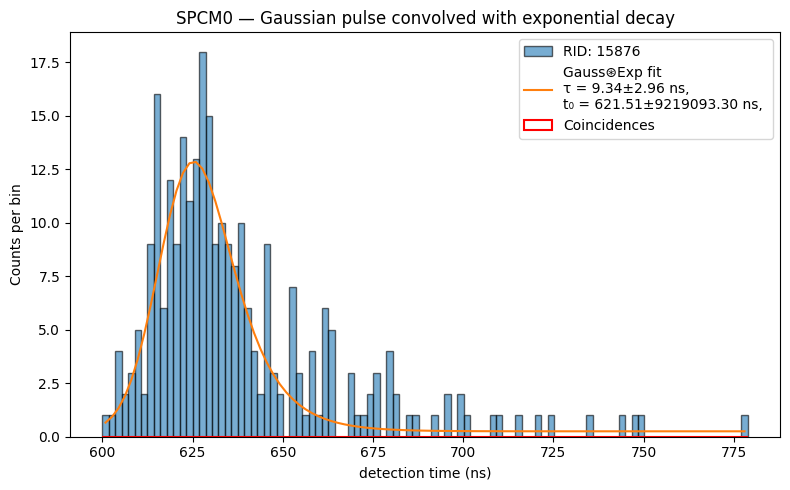

C:\Users\Rb-Networking2\AppData\Local\Temp\ipykernel_9680\1268431454.py:193: OptimizeWarning: Covariance of the parameters could not be estimated
  exp_params, _ = curve_fit(exp_decay, x, y, p0=[t0_guess, A_guess, tau_guess], maxfev=10000)


Gauss⊛Exp fit
τ = 675.16±0.00 ns, σ = 758.66±0.00 ns, μ = 9.68±0.00 ns, t₀ = 598.79±0.00 ns, B = 0.5±5.2


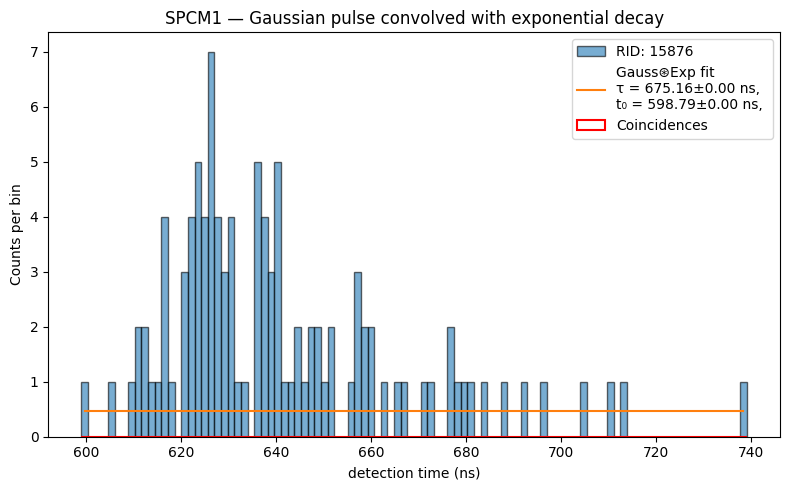

C:\Users\Rb-Networking2\AppData\Local\Temp\ipykernel_9680\1268431454.py:269: OptimizeWarning: Covariance of the parameters could not be estimated
  exp_params, _ = curve_fit(exp_decay, x, y, p0=[t0_guess, A_guess, tau_guess], maxfev=10000)


Gauss⊛Exp fit
τ = 19.66±3.09 ns, σ = 7.04±12.28 ns, μ = -2.64±18700672.68 ns, t₀ = 618.15±18700672.51 ns, B = 0.2±0.2


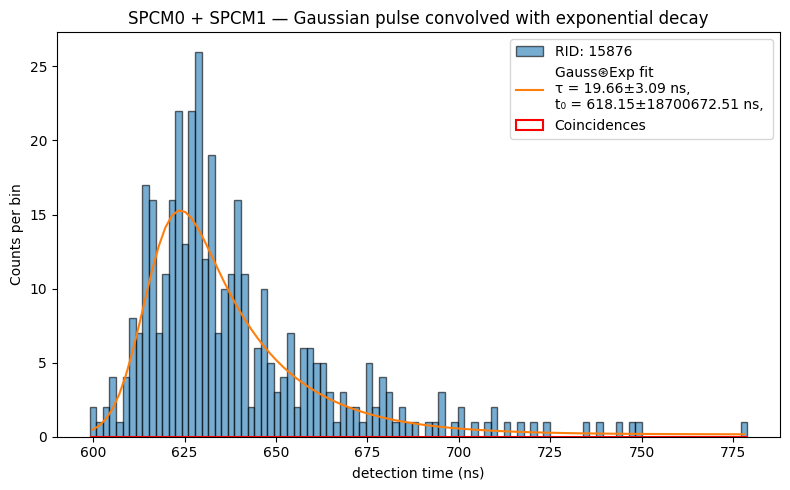

In [302]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erfc

# (optional) compare to pure exponential with your old model
def exp_decay(t, t0, N0, tau):
    return N0 * np.exp(-(t - t0)/tau) * (t > t0)

def gauss_exp_conv(t, t0, A, mu, sigma, tau, B):
    """
    Gaussian pulse convolved with an exponential decay (ex-Gaussian).

    Definition:
      Let x = t - t0. Then
        f(t) = A * (1/(2 τ)) * exp(σ^2/(2 τ^2) - (x - μ)/τ)
               * erfc( (1/√2) * (σ/τ - (x - μ)/σ) ) + B

    Parameters (units: ns unless noted):
      t     : time array (ns)
      t0    : global time offset (ns)
      A     : amplitude (counts scale)
      μ     : Gaussian mean relative to t0 (ns)
      σ     : Gaussian std dev (ns), σ > 0
      τ     : exponential lifetime (ns), τ > 0
      B     : constant background (counts)
    """
    x = t - t0
    return A * (0.5/tau) * np.exp((sigma**2)/(2*tau**2) - (x - mu)/tau) * \
           erfc((1/np.sqrt(2))*((sigma/tau) - (x - mu)/sigma)) + B


print(gauss_exp_conv.__doc__)




to_guess_for_fit = 700.0
hist_bin = 100


####################### Extract coincidence counts   ################################
# --- Step 1: Extract coincidences ---
coincidence_mask = (SPCM0_tStamps_i[:, 0] >= 1) & (SPCM1_tStamps_i[:, 0] >= 1)
coincidence_indices = np.where(coincidence_mask)[0]

# Lists to record relative times
SPCM0_coincidences_ns = []
SPCM1_coincidences_ns = []

for idx in coincidence_indices:
    t0 = t1_reference_i[idx]
    SPCM0_coincidences_ns.append((SPCM0_tStamps_i[idx, 0] - t0) * 1e9)
    SPCM1_coincidences_ns.append((SPCM1_tStamps_i[idx, 0] - t0) * 1e9)
    
SPCM0_coincidences_ns = np.array(SPCM0_coincidences_ns)
SPCM1_coincidences_ns = np.array(SPCM1_coincidences_ns)


################################# SPCM1 counts arrive ~40ns later #################################
## there is a delay in SPCM1 ttl count detection
apply_delay_in_SPCM1 = False

if apply_delay_in_SPCM1:
    shift = 40
    # keep SPCM0 unchanged but copied (if you plan to modify the copy later)
    SPCM0_rel_tStamps_iAll_copy = [a.copy() for a in SPCM0_rel_tStamps_iAll]
    # make a shifted copy of every iteration in SPCM1
    SPCM1_rel_tStamps_iAll_copy = [a + shift for a in SPCM1_rel_tStamps_iAll]
    SPCM1_coincidences_ns = SPCM1_coincidences_ns + shift
else:
    shift = 0
    SPCM0_rel_tStamps_iAll_copy = [a.copy() for a in SPCM0_rel_tStamps_iAll]
    SPCM1_rel_tStamps_iAll_copy = [a.copy() for a in SPCM1_rel_tStamps_iAll]

BothSPCMs_rel_tStamps_iAll_copy = [np.concatenate((spcm0, spcm1)) for spcm0, spcm1 in zip(SPCM0_rel_tStamps_iAll_copy, SPCM1_rel_tStamps_iAll_copy)]
BothSPCMs_coincidences_ns = np.concatenate((SPCM0_coincidences_ns, SPCM1_coincidences_ns))
##################### SPCM0 #######################

# ---- data & histogram ----
data = SPCM0_rel_tStamps_iAll_copy[0]          # ns
bin_counts, bin_edges = np.histogram(data, bins=hist_bin)
bin_centers = 0.5*(bin_edges[:-1] + bin_edges[1:])




# ---- initial guesses ----
t0_guess   = to_guess_for_fit                              # where decay starts (ns)
tau_guess  = 26.2                                  # expected lifetime (ns)
mu_guess   = max(0.0, np.mean(data) - t0_guess - tau_guess)  # rough
sigma_guess= max(7.5, np.std(data)/4)              # rising-edge width guess
A_guess    = float(bin_counts.max())
B_guess    = 0.0

p0 = [t0_guess, A_guess, mu_guess, sigma_guess, tau_guess, B_guess]
bounds = (
    [bin_centers.min()-200,     0.0,    -10.0,   1e-3,   1e-3,   0.0],   # lower
    [bin_centers.max()+200,  1e10,     10.0,   1e3,    1e3,   1e6],     # upper
)



# ---- (optional) Poisson weighting for histogram counts ----
mask = bin_counts >= 0   # keep all bins; or use >0 to drop empties
x    = bin_centers[mask]
y    = bin_counts[mask]
yerr = np.sqrt(y + 1.0)  # Poisson ~ sqrt(N); +1 for stability

# ---- fit ----
params, cov = curve_fit(gauss_exp_conv, x, y, p0=p0, bounds=bounds,
                        sigma=yerr, absolute_sigma=True, maxfev=20000)

t0_fit, A_fit, mu_fit, sigma_fit, tau_fit, B_fit = params
perr = np.sqrt(np.diag(cov))
t0_err, A_err, mu_err, sigma_err, tau_err, B_err = perr

# ---- curves for plotting ----
t_fit = bin_centers
fit_curve = gauss_exp_conv(t_fit, *params)

exp_params, _ = curve_fit(exp_decay, x, y, p0=[t0_guess, A_guess, tau_guess], maxfev=10000)
exp_curve = exp_decay(t_fit, *exp_params)


print(    "Gauss⊛Exp fit\n"
    f"τ = {tau_fit:.2f}±{tau_err:.2f} ns, "
    f"σ = {sigma_fit:.2f}±{sigma_err:.2f} ns, "
    f"μ = {mu_fit:.2f}±{mu_err:.2f} ns, "
    f"t₀ = {t0_fit:.2f}±{t0_err:.2f} ns, "
    f"B = {B_fit:.1f}±{B_err:.1f}")

# ---- plot ----
plt.figure(figsize=(8,5))
plt.hist(data, bins=bin_edges, edgecolor='black', alpha=0.6, label=f"RID: {rid}")
plt.plot(t_fit, fit_curve, '-', label=(
    "Gauss⊛Exp fit\n"    
    f"τ = {tau_fit:.2f}±{tau_err:.2f} ns, \n"
    f"t₀ = {t0_fit:.2f}±{t0_err:.2f} ns, "
))

# Overlay coincidence histogram (in red)
plt.hist(SPCM0_coincidences_ns, bins=bin_edges, histtype='step', color='red', linewidth=1.5, label="Coincidences")

# plt.plot(t_fit, exp_curve, '--', label="Pure exp (comparison)")
plt.xlabel("detection time (ns)")
plt.ylabel("Counts per bin")
plt.title("SPCM0 — Gaussian pulse convolved with exponential decay")
plt.legend()
plt.tight_layout()
plt.show()

##################### SPCM1 #######################

# ---- data & histogram ----
data = SPCM1_rel_tStamps_iAll_copy[0]          # ns
bin_counts, bin_edges = np.histogram(data, bins=hist_bin)
bin_centers = 0.5*(bin_edges[:-1] + bin_edges[1:])


# ---- initial guesses ----
t0_guess   = to_guess_for_fit + shift                                 # where decay starts (ns)
tau_guess  = 26.2                                  # expected lifetime (ns)
mu_guess   = max(0.0, np.mean(data) - t0_guess - tau_guess)  # rough
sigma_guess= max(7.5, np.std(data)/4)              # rising-edge width guess
A_guess    = float(bin_counts.max())
B_guess    = 0.0

p0 = [t0_guess, A_guess, mu_guess, sigma_guess, tau_guess, B_guess]
bounds = (
    [bin_centers.min()-200,     0.0,    -10.0,   1e-3,   1e-3,   0.0],   # lower
    [bin_centers.max()+200,  1e12,     10.0,   1e3,    1e3,   1e6],     # upper
)

# ---- (optional) Poisson weighting for histogram counts ----
mask = bin_counts >= 0   # keep all bins; or use >0 to drop empties
x    = bin_centers[mask]
y    = bin_counts[mask]
yerr = np.sqrt(y + 1.0)  # Poisson ~ sqrt(N); +1 for stability

# ---- fit ----
params, cov = curve_fit(gauss_exp_conv, x, y, p0=p0, bounds=bounds,
                        sigma=yerr, absolute_sigma=True, maxfev=20000)

t0_fit, A_fit, mu_fit, sigma_fit, tau_fit, B_fit = params
perr = np.sqrt(np.diag(cov))
t0_err, A_err, mu_err, sigma_err, tau_err, B_err = perr

# ---- curves for plotting ----
t_fit = bin_centers
fit_curve = gauss_exp_conv(t_fit, *params)

exp_params, _ = curve_fit(exp_decay, x, y, p0=[t0_guess, A_guess, tau_guess], maxfev=10000)
exp_curve = exp_decay(t_fit, *exp_params)


print(    "Gauss⊛Exp fit\n"
    f"τ = {tau_fit:.2f}±{tau_err:.2f} ns, "
    f"σ = {sigma_fit:.2f}±{sigma_err:.2f} ns, "
    f"μ = {mu_fit:.2f}±{mu_err:.2f} ns, "
    f"t₀ = {t0_fit:.2f}±{t0_err:.2f} ns, "
    f"B = {B_fit:.1f}±{B_err:.1f}")

# ---- plot ----
plt.figure(figsize=(8,5))
plt.hist(data, bins=bin_edges, edgecolor='black', alpha=0.6, label=f"RID: {rid}")
plt.plot(t_fit, fit_curve, '-', label=(
    "Gauss⊛Exp fit\n"    
    f"τ = {tau_fit:.2f}±{tau_err:.2f} ns, \n"
    f"t₀ = {t0_fit:.2f}±{t0_err:.2f} ns, "
))

# Overlay coincidence histogram (in red)
plt.hist(SPCM1_coincidences_ns, bins=bin_edges, histtype='step', color='red', linewidth=1.5, label="Coincidences")

# plt.plot(t_fit, exp_curve, '--', label="Pure exp (comparison)")
plt.xlabel("detection time (ns)")
plt.ylabel("Counts per bin")
plt.title("SPCM1 — Gaussian pulse convolved with exponential decay")
plt.legend()
plt.tight_layout()
plt.show()



##################### Combined SPCMs #######################

# ---- data & histogram ----
data = BothSPCMs_rel_tStamps_iAll_copy[0]            # ns
bin_counts, bin_edges = np.histogram(data, bins=hist_bin)
bin_centers = 0.5*(bin_edges[:-1] + bin_edges[1:])


# ---- initial guesses ----
t0_guess   = to_guess_for_fit                                 # where decay starts (ns)
tau_guess  = 26.2                                  # expected lifetime (ns)
mu_guess   = max(0.0, np.mean(data) - t0_guess - tau_guess)  # rough
# sigma_guess= max(7.5, np.std(data)/4)              # rising-edge width guess
sigma_guess = 7
A_guess    = float(bin_counts.max())
B_guess    = 0.0

p0 = [t0_guess, A_guess, mu_guess, sigma_guess, tau_guess, B_guess]
bounds = (
    [bin_centers.min()-200,     0.0,    -10.0,   1e-3,   1e-3,   0.0],   # lower
    [bin_centers.max()+200,   1e12,     10.0,   1e3,    1e3,   1e6],     # upper
)



# ---- (optional) Poisson weighting for histogram counts ----
mask = bin_counts >= 0   # keep all bins; or use >0 to drop empties
x    = bin_centers[mask]
y    = bin_counts[mask]
yerr = np.sqrt(y + 1.0)  # Poisson ~ sqrt(N); +1 for stability

# ---- fit ----
params, cov = curve_fit(gauss_exp_conv, x, y, p0=p0, bounds=bounds,
                        sigma=yerr, absolute_sigma=True, maxfev=20000)

t0_fit, A_fit, mu_fit, sigma_fit, tau_fit, B_fit = params
perr = np.sqrt(np.diag(cov))
t0_err, A_err, mu_err, sigma_err, tau_err, B_err = perr

# ---- curves for plotting ----
t_fit = bin_centers
fit_curve = gauss_exp_conv(t_fit, *params)

exp_params, _ = curve_fit(exp_decay, x, y, p0=[t0_guess, A_guess, tau_guess], maxfev=10000)
exp_curve = exp_decay(t_fit, *exp_params)


print(    "Gauss⊛Exp fit\n"
    f"τ = {tau_fit:.2f}±{tau_err:.2f} ns, "
    f"σ = {sigma_fit:.2f}±{sigma_err:.2f} ns, "
    f"μ = {mu_fit:.2f}±{mu_err:.2f} ns, "
    f"t₀ = {t0_fit:.2f}±{t0_err:.2f} ns, "
    f"B = {B_fit:.1f}±{B_err:.1f}")

# ---- plot ----
plt.figure(figsize=(8,5))
plt.hist(data, bins=bin_edges, edgecolor='black', alpha=0.6, label=f"RID: {rid}")
plt.plot(t_fit, fit_curve, '-', label=(
    "Gauss⊛Exp fit\n"    
    f"τ = {tau_fit:.2f}±{tau_err:.2f} ns, \n"
    f"t₀ = {t0_fit:.2f}±{t0_err:.2f} ns, "
))

# Overlay coincidence histogram (in red)
plt.hist(BothSPCMs_coincidences_ns, bins=bin_edges, histtype='step', color='red', linewidth=1.5, label="Coincidences")

# plt.plot(t_fit, exp_curve, '--', label="Pure exp (comparison)")
plt.xlabel("detection time (ns)")
plt.ylabel("Counts per bin")
plt.title("SPCM0 + SPCM1 — Gaussian pulse convolved with exponential decay")
plt.legend()
plt.tight_layout()
plt.show()

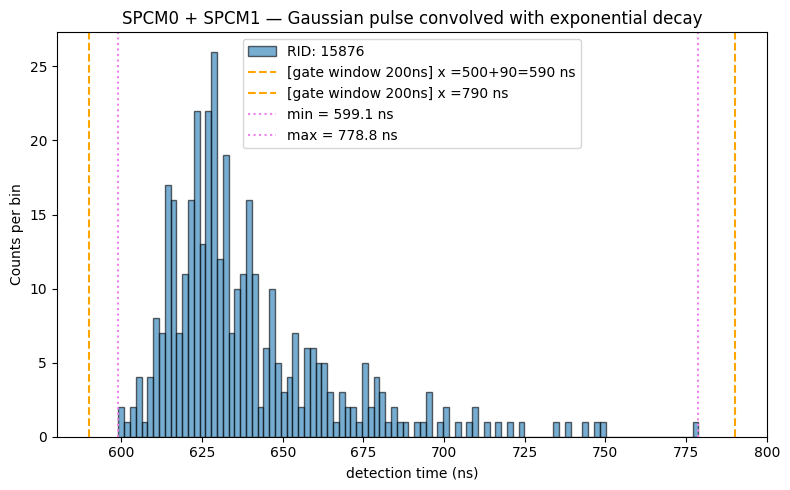

In [303]:
########### this block just regenerates the combined plot from the above ############


# ---- plot ----
plt.figure(figsize=(8,5))
plt.hist(data, bins=bin_edges, edgecolor='black', alpha=0.6, label=f"RID: {rid}")
# plt.plot(t_fit, fit_curve, '-', label=(
#     "Gauss⊛Exp fit\n"    
#     f"τ = {tau_fit:.2f}±{tau_err:.2f} ns, \n"
#     f"t₀ = {t0_fit:.2f}±{t0_err:.2f} ns, "
# ))

# ######### plotting lines
# plt.axvline(x=490, color='red', linestyle='--', linewidth=1.5, label='[gate_start_set] x = 480 ns')

#### test lines - gate time
x_test = gate_start_offset_mu+90
window = 200
plt.axvline(x=x_test, color='orange', linestyle='--', linewidth=1.5, label=f'[gate window 200ns] x ={gate_start_offset_mu}+90={x_test} ns')
x_test = x_test+window
plt.axvline(x=x_test, color='orange', linestyle='--', linewidth=1.5, label=f'[gate window 200ns] x ={x_test} ns')


# # #### test lines - FORT time
# x_test = 550
# window = 200
# plt.axvline(x=x_test, color='blue', linestyle='--', linewidth=1.5, label=f'[FORT OFF] x ={x_test} ns')
# x_test = x_test+window
# plt.axvline(x=x_test, color='blue', linestyle='--', linewidth=1.5, label=f'[FORT ON] x ={x_test} ns')
# x_test = x_test+50
# plt.axvline(x=x_test, color='blue', linestyle='--', linewidth=1.5, label=f'[FORT ON - future] x ={x_test} ns')

######### detected time
t_min = np.min(data)
t_max = np.max(data)
plt.axvline(t_min, color='violet', linestyle=':', linewidth=1.5, label=f"min = {t_min:.1f} ns")
plt.axvline(t_max, color='violet', linestyle=':', linewidth=1.5, label=f"max = {t_max:.1f} ns")


# # Overlay coincidence histogram (in red)
# plt.hist(BothSPCMs_coincidences_ns, bins=bin_edges, histtype='step', color='red', linewidth=1.5, label="Coincidences")

# plt.plot(t_fit, exp_curve, '--', label="Pure exp (comparison)")
plt.xlabel("detection time (ns)")
plt.ylabel("Counts per bin")
plt.title("SPCM0 + SPCM1 — Gaussian pulse convolved with exponential decay")
plt.legend()
plt.tight_layout()

# # ---- save as PDF ----
# pdf_name = f"RID_{rid}_GaussExp_fit_with_coincidences.pdf"
# plt.savefig(pdf_name, format="pdf", bbox_inches="tight")

plt.show()

In [296]:
gate_start_offset_mu

np.int32(490)

In [40]:
# ---- Gaussian FWHM from fitted sigma ----
fwhm_factor = 2 * np.sqrt(2 * np.log(2))
fwhm_fit = fwhm_factor * sigma_fit
fwhm_err = fwhm_factor * sigma_err

print(
    "Gauss⊛Exp fit\n"
    f"τ = {tau_fit:.2f} ± {tau_err:.2f} ns, "
    f"σ = {sigma_fit:.2f} ± {sigma_err:.2f} ns, "
    f"Gaussian FWHM = {fwhm_fit:.2f} ± {fwhm_err:.2f} ns, "
    f"μ = {mu_fit:.2f} ± {mu_err:.2f} ns, "
    f"t₀ = {t0_fit:.2f} ± {t0_err:.2f} ns, "
    f"B = {B_fit:.1f} ± {B_err:.1f}"
)

Gauss⊛Exp fit
τ = 27.26 ± 0.24 ns, σ = 6.91 ± 0.52 ns, Gaussian FWHM = 16.27 ± 1.22 ns, μ = -0.22 ± 544108.67 ns, t₀ = 891.80 ± 544108.72 ns, B = 1.4 ± 1.5


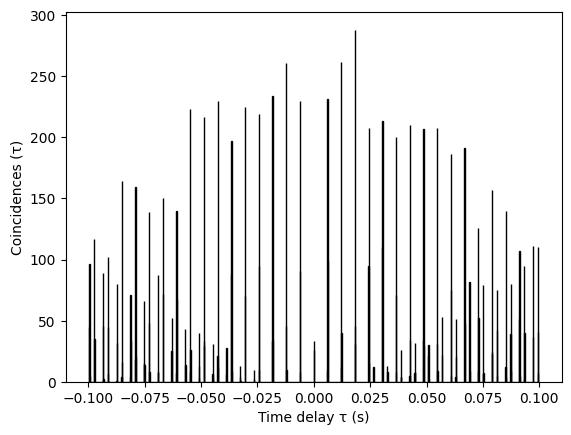

In [53]:
"""
g2 correlation measurement. I need to think more about the following: the photons are not expected at a fixed frequency. There is about 5-15ms recooling for a few times, 
after which we have 20ms RO, there are sometimes a few excitation attempts, etc. Do these periods affect the g2 correlation graph? I can also simulate the data. 

"""

# SPCM0_rel_tStamps_iAll_copy = [a.copy() for a in SPCM0_rel_tStamps_iAll]
# # make a shifted copy of every iteration in SPCM1
# SPCM1_rel_tStamps_iAll_copy = [a + shift for a in SPCM1_rel_tStamps_iAll]

### removing the elements with no photons and flatten the array:
SPCM0_tStamps_i_filtered = SPCM0_tStamps_i[SPCM0_tStamps_i != -1].flatten()
SPCM1_tStamps_i_filtered = SPCM1_tStamps_i[SPCM1_tStamps_i != -1].flatten()

SPCM0_tStamps_i_filtered_copy = [a.copy() for a in SPCM0_tStamps_i_filtered]
# make a shifted copy of every iteration in SPCM1
SPCM1_tStamps_i_filtered_copy = [a.copy() for a in SPCM1_tStamps_i_filtered]

SPCM0_tStamps_i_filtered_copy = np.array(SPCM0_tStamps_i_filtered_copy)
SPCM1_tStamps_i_filtered_copy = np.array(SPCM1_tStamps_i_filtered_copy)

def compute_g2(spcm0_times, spcm1_times, bin_width=100e-6, max_tau=100e-3):
    taus = np.arange(-max_tau, max_tau, bin_width)  # Time bins
    counts, _ = np.histogram(spcm1_times[:, None] - spcm0_times, bins=taus)

    ### Normalization (optional, assuming constant background)
    # norm_factor = (len(spcm0_times) * len(spcm1_times)) / (2 * max_tau / bin_width)
    # g2 = counts / norm_factor
    g2 = counts

    return taus[:-1] + bin_width / 2, g2, bin_width  # Return bin width for bar plot

taus, g2_values, bin_width = compute_g2(SPCM0_tStamps_i_filtered_copy, SPCM1_tStamps_i_filtered_copy)

plt.bar(taus, g2_values, width=1*bin_width, align='center', color='grey', edgecolor='k')
plt.xlabel("Time delay τ (s)")
plt.ylabel("Coincidences (τ)")
plt.show()

In [176]:
np.array(SPCM1_tStamps_i_filtered_copy)

array([6847434.42956159, 6847434.63535493, 6847437.12962438, ...,
       6851686.49377935, 6851686.80117035, 6851687.55258377])

## Miscellaneous calculations - exponential decay fit

C:\Users\Rb-Networking2\AppData\Local\Temp\ipykernel_13228\2570049580.py:12: RuntimeWarning: overflow encountered in exp
  return N0 * np.exp(-(t - t0) / tau) * (t > t0)  # Step function ensures decay starts at t0
C:\Users\Rb-Networking2\AppData\Local\Temp\ipykernel_13228\2570049580.py:12: RuntimeWarning: invalid value encountered in multiply
  return N0 * np.exp(-(t - t0) / tau) * (t > t0)  # Step function ensures decay starts at t0
C:\Users\Rb-Networking2\AppData\Local\Temp\ipykernel_13228\2570049580.py:23: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(exp_decay, bin_centers, bin_counts, p0=[t0_guess, N0_guess, tau_guess])


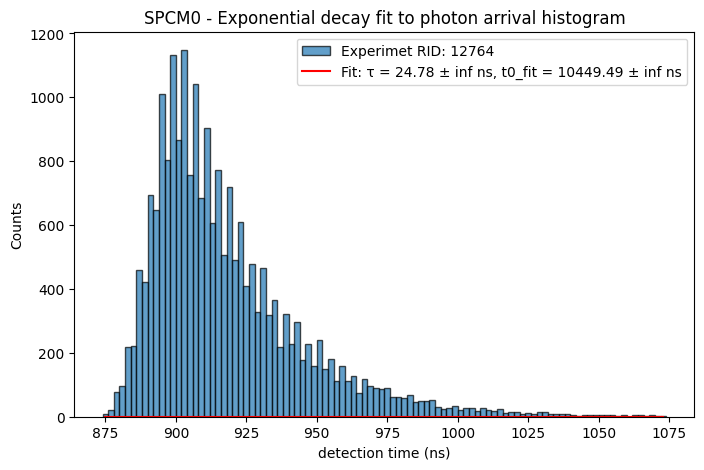

C:\Users\Rb-Networking2\AppData\Local\Temp\ipykernel_13228\2570049580.py:55: RuntimeWarning: overflow encountered in exp
  return N0 * np.exp(-(t - t0) / tau) * (t > t0)  # Step function ensures decay starts at t0
C:\Users\Rb-Networking2\AppData\Local\Temp\ipykernel_13228\2570049580.py:55: RuntimeWarning: invalid value encountered in multiply
  return N0 * np.exp(-(t - t0) / tau) * (t > t0)  # Step function ensures decay starts at t0
C:\Users\Rb-Networking2\AppData\Local\Temp\ipykernel_13228\2570049580.py:63: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(exp_decay, bin_centers, bin_counts, p0=[t0_guess, N0_guess, tau_guess])


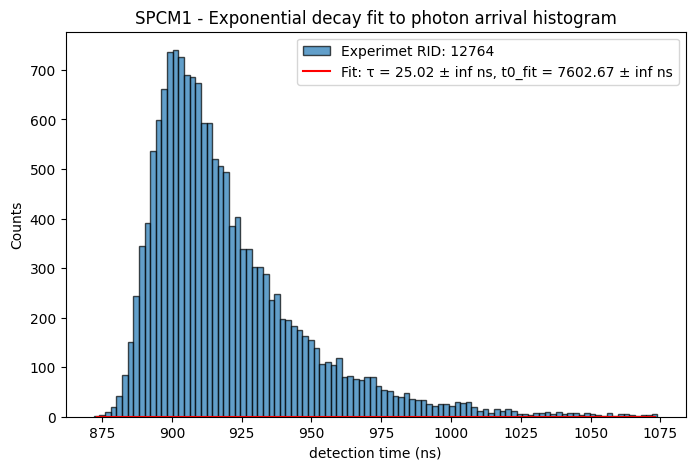

In [11]:
"""   Fitting exponential decay to the histogram  """

data = SPCM0_rel_tStamps_iAll[0]
### Create histogram and get bin edges & counts
bin_counts, bin_edges = np.histogram(data, bins=100)  

### Compute bin centers from edges
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

### exponential decay function for fit
def exp_decay(t, t0, N0, tau):
    return N0 * np.exp(-(t - t0) / tau) * (t > t0)  # Step function ensures decay starts at t0

# def gaussian_rise_and_exp_decay(t, t0, N0, tau):
#     return N0 * np.exp(-(t - t0) / tau) 

### Initial guesses for fitting parameters
t0_guess = 930  # Estimate for the start of decay
N0_guess = max(bin_counts) 
tau_guess = 24  # Expected atomic lifetime in ns

### Fit the histogram data to the exponential function
params, covariance = curve_fit(exp_decay, bin_centers, bin_counts, p0=[t0_guess, N0_guess, tau_guess])

### Extract fitted parameters and uncertainties
t0_fit, N0_fit, tau_fit = params
t0_err, N0_err, tau_err = np.sqrt(np.diag(covariance))  # Standard errors

### Generate curve using fitted parameters
fit_curve = exp_decay(bin_centers, t0_fit, N0_fit, tau_fit)


plt.figure(figsize=(8, 5))
plt.hist(data, bins=100, edgecolor='black', alpha=0.7, label=f"Experimet RID: {rid}")
plt.plot(bin_centers, fit_curve, 'r-', label=f"Fit: τ = {tau_fit:.2f} ± {tau_err:.2f} ns, t0_fit = {t0_fit:.2f} ± {t0_err:.2f} ns")

plt.xlabel("detection time (ns)")
plt.ylabel("Counts")
plt.title("SPCM0 - Exponential decay fit to photon arrival histogram")
plt.legend()
plt.show()


"""  SPCM1 - Fitting exponential decay to the histogram  """

data = SPCM1_rel_tStamps_iAll[0]
### Create histogram and get bin edges & counts
bin_counts, bin_edges = np.histogram(data, bins=100)  

### Compute bin centers from edges
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

### exponential decay function for fit
def exp_decay(t, t0, N0, tau):
    return N0 * np.exp(-(t - t0) / tau) * (t > t0)  # Step function ensures decay starts at t0

### Initial guesses for fitting parameters
t0_guess = 930  # Estimate for the start of decay
N0_guess = max(bin_counts) 
tau_guess = 24  # Expected atomic lifetime in ns

### Fit the histogram data to the exponential function
params, covariance = curve_fit(exp_decay, bin_centers, bin_counts, p0=[t0_guess, N0_guess, tau_guess])

### Extract fitted parameters and uncertainties
t0_fit, N0_fit, tau_fit = params
t0_err, N0_err, tau_err = np.sqrt(np.diag(covariance))  # Standard errors

### Generate curve using fitted parameters
fit_curve = exp_decay(bin_centers, t0_fit, N0_fit, tau_fit)


plt.figure(figsize=(8, 5))
plt.hist(data, bins=100, edgecolor='black', alpha=0.7, label=f"Experimet RID: {rid}")
plt.plot(bin_centers, fit_curve, 'r-', label=f"Fit: τ = {tau_fit:.2f} ± {tau_err:.2f} ns, t0_fit = {t0_fit:.2f} ± {t0_err:.2f} ns")

plt.xlabel("detection time (ns)")
plt.ylabel("Counts")
plt.title("SPCM1 - Exponential decay fit to photon arrival histogram")
plt.legend()
plt.show()


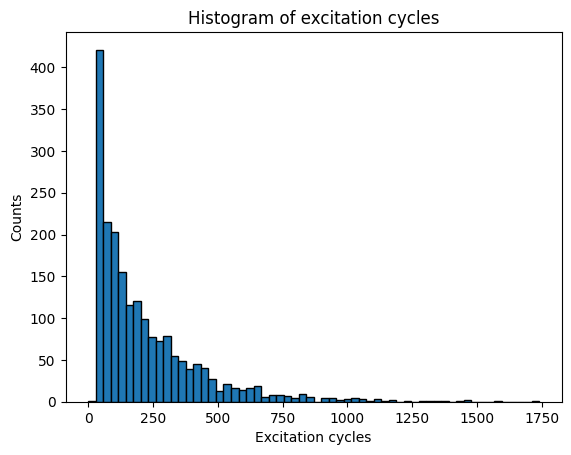

np.float64(210.94952523738132)

In [163]:
n_excitation_cycles

# draw histogram
plt.hist(n_excitation_cycles, bins=60, edgecolor='black')  
plt.xlabel("Excitation cycles")
plt.ylabel("Counts")
plt.title("Histogram of excitation cycles")
plt.show()


np.mean(n_excitation_cycles)

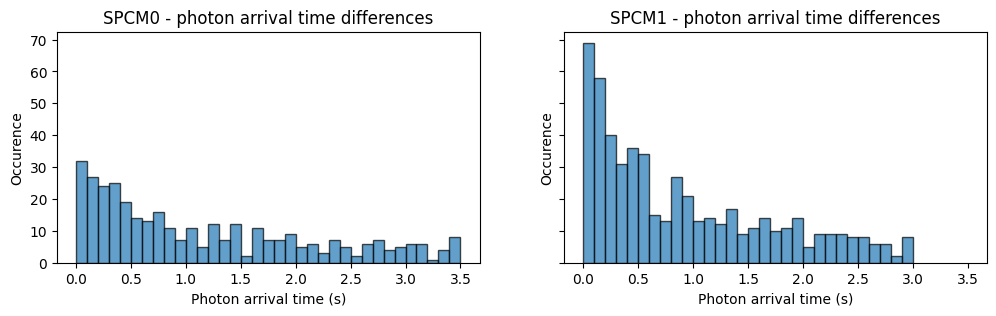

In [149]:
"""
Detailed rate analysis.

"""
########################################## Plot histogram of photon arrival times

for i in range(iterations):
    fig, axs = plt.subplots(1, 2, figsize=(12, 3), sharey=True, sharex=True)
    
    time_diffs = np.diff(SPCM0_tStamps_filtered_iAll[i])
    data_temp = np.sort(time_diffs) ### sorted so we can easily select and zoom into short times, for example.
    data = data_temp[0:-100] ### In case the last few times are too long, remove them from the data.

    bin_width = 0.1  ### in seconds
    Bins = np.arange(data.min(), data.max() + bin_width, bin_width)
    
    axs[0].hist(data, bins=Bins, edgecolor='black', alpha=0.7, log=False) ### log=True applies log-scale to y-axis
    axs[0].set_xlabel("Photon arrival time (s)")
    axs[0].set_ylabel("Occurence")
    axs[0].set_title("SPCM0 - photon arrival time differences")

    time_diffs = np.diff(SPCM1_tStamps_filtered_iAll[i])
    data_temp = np.sort(time_diffs) ### sorted so we can easily select and zoom into short times, for example.
    data = data_temp[0:-100] ### In case the last few times are too long, remove them from the data.

    bin_width = 0.1  ### in seconds
    Bins = np.arange(data.min(), data.max() + bin_width, bin_width)
    
    axs[1].hist(data, bins=Bins, edgecolor='black', alpha=0.7, log=False) ### log=True applies log-scale to y-axis
    axs[1].set_xlabel("Photon arrival time (s)")
    axs[1].set_ylabel("Occurence")
    axs[1].set_title("SPCM1 - photon arrival time differences")
    
    # axs[1].hist(SPCM1_rel_tStamps_iAll[i], bins=100, edgecolor='black', alpha=0.7)
    # axs[1].set_xlabel("detection time (ns)")
    # axs[1].set_title("SPCM1 photons");

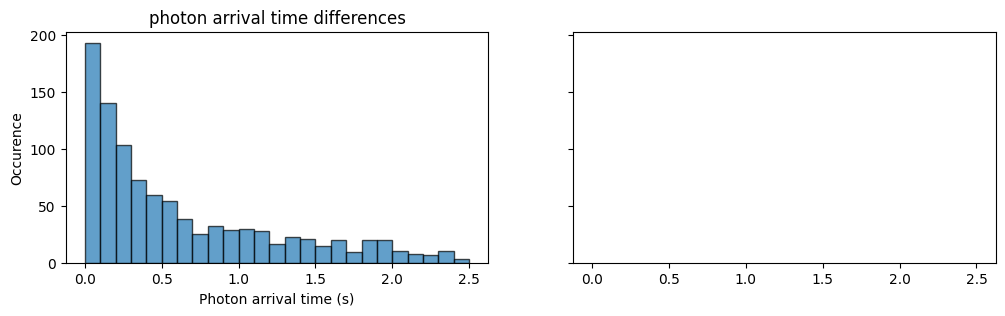

In [150]:
"""
Detailed rate analysis.

"""
########################################## Plot histogram of photon arrival times

for i in range(iterations):
    fig, axs = plt.subplots(1, 2, figsize=(12, 3), sharey=True, sharex=True)
    time_diffs = np.diff(BothSPCMs_tStamps_filtered_iAll[i])
    data_temp = np.sort(time_diffs) ### sorted so we can easily select and zoom into short times, for example.
    data = data_temp[0:-100] ### In case the last few times are too long, remove them from the data.

    bin_width = 0.1  ### in seconds
    Bins = np.arange(data.min(), data.max() + bin_width, bin_width)
    
    axs[0].hist(data, bins=Bins, edgecolor='black', alpha=0.7, log=False) ### log=True applies log-scale to y-axis
    axs[0].set_xlabel("Photon arrival time (s)")
    axs[0].set_ylabel("Occurence")
    axs[0].set_title("photon arrival time differences")
    
    # axs[1].hist(SPCM1_rel_tStamps_iAll[i], bins=100, edgecolor='black', alpha=0.7)
    # axs[1].set_xlabel("detection time (ns)")
    # axs[1].set_title("SPCM1 photons");

C:\Users\Rb-Networking2\AppData\Local\Temp\ipykernel_18416\3391413678.py:12: RuntimeWarning: overflow encountered in exp
  return N0 * np.exp(-(t - t0) / tau) * (t > t0)  # Step function ensures decay starts at t0
C:\Users\Rb-Networking2\AppData\Local\Temp\ipykernel_18416\3391413678.py:12: RuntimeWarning: invalid value encountered in multiply
  return N0 * np.exp(-(t - t0) / tau) * (t > t0)  # Step function ensures decay starts at t0
C:\Users\Rb-Networking2\AppData\Local\Temp\ipykernel_18416\3391413678.py:20: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(exp_decay, bin_centers, bin_counts, p0=[t0_guess, N0_guess, tau_guess])


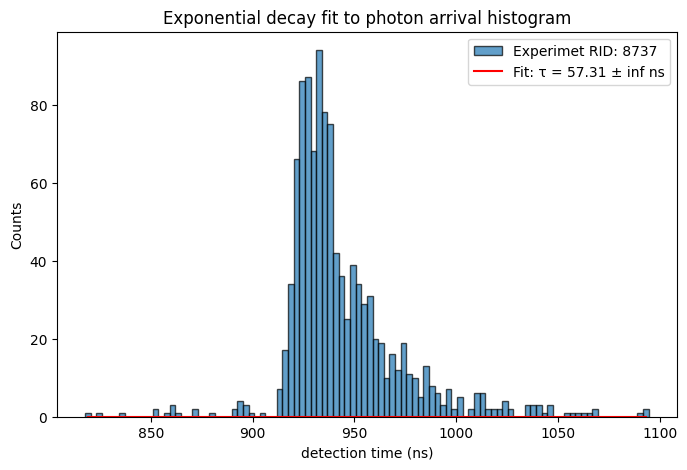

In [152]:
"""   Fitting exponential decay to the histogram  """

data = BothSPCMs_rel_tStamps_iAll[0]
### Create histogram and get bin edges & counts
bin_counts, bin_edges = np.histogram(data, bins=100)  

### Compute bin centers from edges
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

### exponential decay function for fit
def exp_decay(t, t0, N0, tau):
    return N0 * np.exp(-(t - t0) / tau) * (t > t0)  # Step function ensures decay starts at t0

### Initial guesses for fitting parameters
t0_guess = 870  # Estimate for the start of decay
N0_guess = max(bin_counts) 
tau_guess = 24  # Expected atomic lifetime in ns

### Fit the histogram data to the exponential function
params, covariance = curve_fit(exp_decay, bin_centers, bin_counts, p0=[t0_guess, N0_guess, tau_guess])

### Extract fitted parameters and uncertainties
t0_fit, N0_fit, tau_fit = params
t0_err, N0_err, tau_err = np.sqrt(np.diag(covariance))  # Standard errors

### Generate curve using fitted parameters
fit_curve = exp_decay(bin_centers, t0_fit, N0_fit, tau_fit)


plt.figure(figsize=(8, 5))
plt.hist(data, bins=100, edgecolor='black', alpha=0.7, label=f"Experimet RID: {rid}")
plt.plot(bin_centers, fit_curve, 'r-', label=f"Fit: τ = {tau_fit:.2f} ± {tau_err:.2f} ns")

plt.xlabel("detection time (ns)")
plt.ylabel("Counts")
plt.title("Exponential decay fit to photon arrival histogram")
plt.legend()
plt.show()




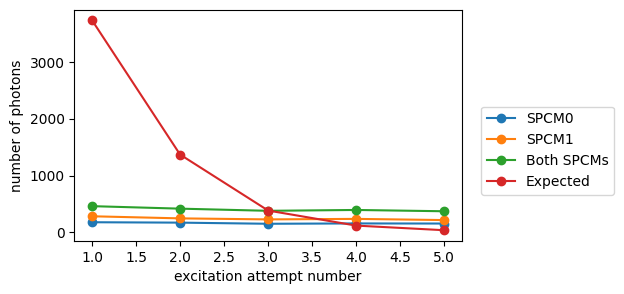

In [84]:
"""
If n_excitation_attempt is 3, for example, do we detect more photons from the first attempt? This analysis looks at the number of photons we get from each attempt. 

"""

SPCM0_counts_in_each_attempt = []
SPCM1_counts_in_each_attempt = []

for j in range(n_excitation_attempts):
    ### Each group is the timestamps for separate excitation attempts. If n_excitation-attempts = 3, for example, we have 3 groups.
    SPCM0_group_j = SPCM0_tStamps_i[j::n_excitation_attempts, 0]  ### Extract first element (first click) from each subarray
    SPCM0_counts_in_attempt_j = np.count_nonzero(SPCM0_group_j != -1)
    SPCM0_counts_in_each_attempt.append(SPCM0_counts_in_attempt_j)

    SPCM1_group_j = SPCM1_tStamps_i[j::n_excitation_attempts, 0]  ### Extract first element (first click) from each subarray
    SPCM1_counts_in_attempt_j = np.count_nonzero(SPCM1_group_j != -1)
    SPCM1_counts_in_each_attempt.append(SPCM1_counts_in_attempt_j)

Both_SPCMs_in_each_attempt = np.array(SPCM0_counts_in_each_attempt) + np.array(SPCM1_counts_in_each_attempt)


######################################## Theoretical expectation
"""
The probability of excitation and detection as a function of excitation attempt. 

2/3 is the probability of decay to mF=-1 and +1. 
See the report on wiki early in early March 2025 for details. 

"""
Pe = 0.95  ### Probability of excitation with the excitation pulse
eta = 0.05 ### overal detection efficiency
P0 = 0.75 ### optical pumping fidelity
n_max = 5  # Number of elements

n_try = n_excitation_cycles_iAll[0] ### the number of excitation cycles in the entire experiemnt.

attempt_values = np.arange(1, n_max + 1)  # n from 1 to n_max
Expected_photons_array = [n_try * eta * P0 * Pe * 2 / 3]  # First element

# Compute remaining elements iteratively
for n in range(2, n_max+1):
    Expected_photons_array.append(n_try * eta * P0 * Pe * 2 / 3 * ((Pe / 3) ** (n-1) + (1 - Pe) ** (n-1)))
############################################################

plt.figure(figsize=(5,3))
plt.plot(range(1, n_excitation_attempts + 1), SPCM0_counts_in_each_attempt, marker='o', linestyle='-',label = "SPCM0")
plt.plot(range(1, n_excitation_attempts + 1), SPCM1_counts_in_each_attempt, marker='o', linestyle='-',label = "SPCM1")
plt.plot(range(1, n_excitation_attempts + 1), Both_SPCMs_in_each_attempt, marker='o', linestyle='-',label = "Both SPCMs")
plt.plot(attempt_values, Expected_photons_array, marker='o', linestyle='-', label = "Expected")
plt.xlabel("excitation attempt number")
plt.ylabel("number of photons")
plt.legend(loc=(1.05,0.2))
plt.show()

In [105]:
""" In each excitation cycle we excite the atom n_excitation_attempts times. But we expect one photon from all these attempts in each cycle. This section finds
the number of timestamps occuring within a short window that covers all the excitation attempts. 

"""
time_window = 1e-3

for i in range(iterations):
    data = BothSPCMs_tStamps_filtered_iAll[i]
    
    # Compute time differences between consecutive timestamps
    time_diffs = np.diff(data)
    
    # Create a histogram: Count the number of time differences ≤ time_window
    num_events_in_window = np.sum(time_diffs <= time_window)
    
    print(f"Total events within {time_window} units: {num_events_in_window}")


Total events within 0.001 units: 14


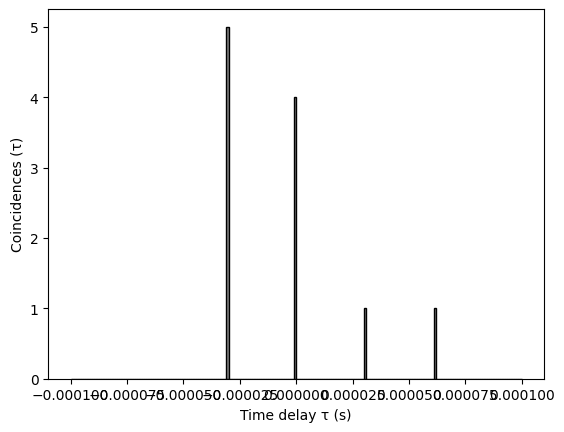

In [169]:
"""
g2 correlation measurement. I need to think more about the following: the photons are not expected at a fixed frequency. There is about 5-15ms recooling for a few times, 
after which we have 20ms RO, there are sometimes a few excitation attempts, etc. Do these periods affect the g2 correlation graph? I can also simulate the data. 

"""

### removing the elements with no photons and flatten the array:
SPCM0_tStamps_i_filtered = SPCM0_tStamps_i[SPCM0_tStamps_i != -1].flatten()
SPCM1_tStamps_i_filtered = SPCM1_tStamps_i[SPCM1_tStamps_i != -1].flatten()

def compute_g2(spcm0_times, spcm1_times, bin_width=10e-3, max_tau=300e-3):
    taus = np.arange(-max_tau, max_tau, bin_width)  # Time bins
    counts, _ = np.histogram(spcm1_times[:, None] - spcm0_times, bins=taus)

    ### Normalization (optional, assuming constant background)
    # norm_factor = (len(spcm0_times) * len(spcm1_times)) / (2 * max_tau / bin_width)
    # g2 = counts / norm_factor
    g2 = counts

    return taus[:-1] + bin_width / 2, g2, bin_width  # Return bin width for bar plot

taus, g2_values, bin_width = compute_g2(SPCM0_tStamps_i_filtered, SPCM1_tStamps_i_filtered)

plt.bar(taus, g2_values, width=1*bin_width, align='center', color='grey', edgecolor='k')
plt.xlabel("Time delay τ (s)")
plt.ylabel("Coincidences (τ)")
plt.show()

# Single photon analysis - load_MOT_and_FORT_until_atom (contains g2 but not finished)
Delete this after adding excitation attempt to the cycle and after you got good data again.
This is anaylysis for the new atom loading sequence that turns on the MOT and FORT until an atom is trapped. The raw time tags are saved for both SPCMs. SPCM0 has one more column for the time t1 marking the excitation time for reference.

The impportant difference for this analysis is that n_excitation_cycle is not fixed anymore. We exit the excitation cycle when the atom is lost. So, atom retained fraction is meaningless. valid for experiments from 2025-02-15 until 2025-02-19.

Analysis for our first search for photons emitted following an excitation pulse, with $g^{(2)}(0)$ calculations. 

To use the analysis code, change the dat in date_filters and find the experiment(s) you want to analyse and write in file_indices. If you like the results and you want to keep them, take a screen clip of the results and save in the powerpoint. All the information you need to know about the experiment should be printed at the end. Please add anything is missing.

In [31]:
date_filters = ["2025-09-08"]

from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import csv
import numpy as np
import os,sys
import PIL # for reading tif images
import h5py
import datetime as dt
import time
from scipy.optimize import curve_fit
from skimage.filters import threshold_otsu
from IPython.display import display, HTML ## for large prints

sys.path.append("..\\")
from h5_data_utilities import * # helper functions for dealing with h5 files

def average_over_measurement(measurements, history):
    iteration = len(history) // measurements
    mean_by_iteration = [np.mean(history[j * measurements:(j + 1) * measurements]) for j in range(iteration)]
    return mean_by_iteration


fnames = get_files_by_criteria(date_filters, # only find files from these date directories
                               name_filters=["GeneralVariableScan"], # only find files containing all these strings
                               condition=lambda filename: True, # use this to filter by experiment parameters, like this: lambda filename: np.bool_(h5py.File(filename)['datasets']['set_current_coil_volts_at_finish'])
                               start_dir=results,
                               include_path=True, # if False, only return the name of the file, not the full path
                               print_filenames=True
)


only_show_i_greater_than = -1

print(f"found {len(fnames)} files")
for i,f in enumerate(fnames):
    if i > only_show_i_greater_than:
        try:
            ds = h5py.File(os.path.join(results, f))['datasets']
            scan_str = str_from_h5(ds['scan_variable1_name'])
            if str_from_h5(ds['scan_variable2_name']) != '':
                scan_str += ", " +str_from_h5(ds['scan_variable2_name'])
            print(f"file {i} ({f}) scanned over "+scan_str)
        except:

            print(f"oops... something wrong with {f}")

found 45 files
file 0 (C:\Networking Experiment\artiq codes\artiq-master\results\2025-09-08\11\000008793-GeneralVariableScan.h5) scanned over t_microwave_pulse
file 1 (C:\Networking Experiment\artiq codes\artiq-master\results\2025-09-08\11\000008793-GeneralVariableScan_microwave_Rabi_2_CW_OP_scan_over_t_microwave_pulse.h5) scanned over t_microwave_pulse
file 2 (C:\Networking Experiment\artiq codes\artiq-master\results\2025-09-08\11\000008794-GeneralVariableScan.h5) scanned over t_microwave_pulse
file 3 (C:\Networking Experiment\artiq codes\artiq-master\results\2025-09-08\11\000008794-GeneralVariableScan_microwave_Rabi_2_CW_OP_scan_over_t_microwave_pulse.h5) scanned over t_microwave_pulse
file 4 (C:\Networking Experiment\artiq codes\artiq-master\results\2025-09-08\13\000008806-GeneralVariableScan.h5) scanned over t_microwave_pulse
file 5 (C:\Networking Experiment\artiq codes\artiq-master\results\2025-09-08\13\000008806-GeneralVariableScan_microwave_Rabi_2_CW_OP_scan_over_t_microwave_pul

IndexError: list index out of range

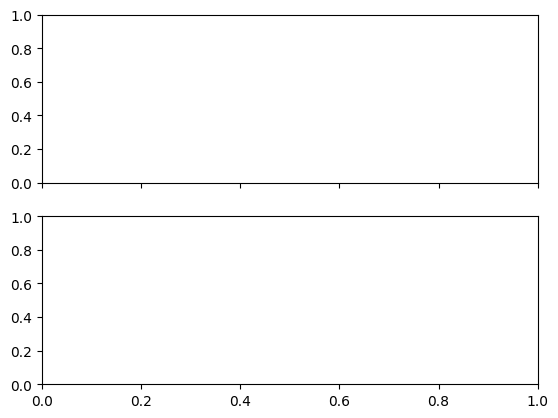

In [102]:
### the file(s) to analyze:
file_indices = {
    44:''
    # 11:'',
} 

compare = True # compare multiple files in the same retention and loading plots
otsu_threshold = False # compute threshold using Otsu method instead doing it by eye. only work when require atom loading = False
showhist = True
showloading = True
custom_xlabel = True
merge_data = False # if True, the datasets will be combined, and if fit=True, the new merged data will be fit. don't try this in 2D
fit = False

showhist_counts = False 

# for plotting
legend_vars =[]   #legend_vars = ['AY_volts_OP', 'f_microwaves_dds'] # will be included in the plot legend
xform_and_label = {}
loc='best'
ret_cmap = mpl.colormaps['turbo']
ldng_cmap = mpl.colormaps['winter']

# for fitting
fit_dict = {}

if compare:
    if showloading:
        fig_ret,axes = plt.subplots(nrows=2, sharex=True)
        ax_ret, ax_ldng = axes
    else:
        fig_ret,ax_ret = plt.subplots()


first_shot_hists = []
second_shot_hists = []
mean1_by_iteration = []
mean2_by_iteration = []

merged_retention = np.array([])
merged_scan_sequence1 = np.array([])
merged_errs = np.array([])
rid_str = ''


for idx,f_item in enumerate(file_indices.items()):
    f_idx,f_comment = f_item   # idx - f_item = {f_idx: f_comment}
    f = h5py.File(os.path.join(results, fnames[f_idx]))
    rid = f['rid'][()]
    h5_archive_and_datasets_to_locals(f, parent_locals=locals(), quiet=True)
    print("experiment:",experiment_function)
    print("override:",override_ExperimentVariables)

    iterations = len(scan_sequence1) #int(len(SPCM0_RO1)/n_measurements)
    print("# of iterations: ", iterations)
    
    if otsu_threshold:
        thresh = threshold_otsu(SPCM0_RO1)
        print("threshold_otsu: ", thresh)
    else:
        cutoff1 = cutoff2 = single_atom_threshold * t_SPCM_first_shot

    
    ### for plotting 
    ### xsteps_xform is a function that can transform scan_sequence1 for plotting. Here it is equal to identity, i.e. no change in scan_sequence1.
    if scan_variable1_name in xform_and_label and custom_xlabel:
        xsteps_xform, xlabel = (xform_and_label[scan_variable1_name]['xsteps_xform'], xform_and_label[scan_variable1_name]['xlabel'])
    else:
        xsteps_xform, xlabel = (lambda x: x, scan_variable1_name)
        

    legend_string = ''
    for a in legend_vars:
        legend_string += f'{a}={locals()[a]}, '
    legend_string = legend_string[:-2]
    f_comment += legend_string

    
    ### get_loading_and_retention
    ### These array have length = iterations
    retention_array, loading_rate_array, n_atoms_loaded_array = get_loading_and_retention(SPCM0_RO1, SPCM0_RO2, n_measurements, iterations, cutoff1, otsu=otsu_threshold)


    ### Necessary to analyze data with 2 scan_sequences
    ### reshaping each array into a 2D array with shape = shape, with order = 'F' (Fortran-style) to sort column by column
    
    ncols = len(scan_sequence2)
    nrows = len(scan_sequence1)
    shape = (len(scan_sequence2),len(scan_sequence1))
    loading_rate_raveled = np.reshape(loading_rate_array,shape,order='F') # rows have constant variable2
    n_atoms_loaded_raveled = np.reshape(n_atoms_loaded_array,shape,order='F') # rows have constant variable2
    retention_raveled = np.reshape(retention_array,shape,order='F') # rows have constant variable2

    
    ### show historam of first_shot and second_shot
    histMin = np.min([SPCM0_RO1, SPCM0_RO2])/t_SPCM_first_shot ## boundary for the histogram plots
    histMax = np.max([SPCM0_RO1, SPCM0_RO2])/t_SPCM_first_shot
    if showhist:
        first_shot_hists.append(
            [np.histogram(SPCM0_RO1[i*n_measurements:(i+1)*n_measurements]/t_SPCM_first_shot,bins=np.linspace(histMin,histMax,50))[0]
                              for i in range(iterations)])

        second_shot_hists.append(
            [np.histogram(SPCM0_RO2[i*n_measurements:(i+1)*n_measurements]/t_SPCM_second_shot,bins=np.linspace(histMin,histMax,50))[0]
                                      for i in range(iterations)])

    
    ### plot a retention curve vs variable 1 for each variable 2 value
    for i, retention, loading, n_loaded, var2 in zip(range(len(scan_sequence2)), retention_raveled, loading_rate_raveled, n_atoms_loaded_raveled, scan_sequence2):
        
        errs = np.array([1/np.sqrt(n) if n > 0 else np.inf for n in n_loaded])
        if not compare:
            if showloading:
                    fig_ret,axes = plt.subplots(nrows=2, sharex=True)
                    ax_ret, ax_ldng = axes
            else:
                fig_ret,ax_ret = plt.subplots()
                
        if not merge_data:
            ax_ret.scatter(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0], label=str(rid)+', '+f_comment, color=ret_cmap(idx/len(file_indices)))
            ax_ret.errorbar(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0], errs[loading > 0], ls='none',color=ret_cmap(idx/len(file_indices)))
            ax_ret.set_ylim((0,1))

            if not ncols > 1 and fit and scan_variable1_name in fit_dict:
                popt, _ = curve_fit(f=fit_dict[scan_variable1_name]['model'], xdata=scan_sequence1, ydata=retention, p0=fit_dict[scan_variable1_name]['p0'], bounds=fit_dict[scan_variable1_name]['bounds'])
                fit_str = "".join([f'{p}={v:.4f}, ' for p,v in zip(fit_dict[scan_variable1_name]['params'], popt)])[:-2]
                print(fit_str)
                hi_res_x = np.linspace(scan_sequence1[0], scan_sequence1[-1], 10*len(scan_sequence1))
                hi_res_x_xform = np.linspace(xsteps_xform(scan_sequence1)[0], xsteps_xform(scan_sequence1)[-1], 10*len(scan_sequence1))
                ax_ret.plot(hi_res_x_xform, fit_dict[scan_variable1_name]['model'](hi_res_x, *popt),linestyle='--',color=ret_cmap(idx/len(file_indices)),label=fit_str)
            else:
                ax_ret.plot(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0],linestyle='--',color=ret_cmap(idx/len(file_indices)))
    
            if not showloading:
                ax_ret.set_xlabel(xlabel)
            ax_ret.set_ylabel("retention")
            #ax_ret.legend(loc=loc)
            ax_ret.legend(bbox_to_anchor=(1.05, 1), loc='upper left')      # This will show the legend outside the plot
            
        else:
            merged_retention = np.concatenate((merged_retention,retention[loading > 0]))
            merged_scan_sequence1 = np.concatenate((merged_scan_sequence1, scan_sequence1[loading > 0]))
            merged_errs = np.concatenate((merged_errs, errs[loading > 0]))
            rid_str += str(rid) + ', '
    
        if showloading:
            ax_ldng.plot(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], linestyle='--',color=ldng_cmap(idx/len(file_indices)))
            ax_ldng.scatter(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], label=rid, color=ldng_cmap(idx/len(file_indices)))
            errs = np.array([1/np.sqrt(n) if n > 0 else np.inf for n in n_loaded])
            ax_ldng.errorbar(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], errs[loading > 0], ls='none', color=ldng_cmap(idx/len(file_indices)))
            ax_ldng.set_ylim((0,1))
            ax_ldng.set_xlabel(xlabel)
            ax_ldng.set_ylabel("loading rate")


if merge_data:
    retention = merged_retention
    scan_sequence1 = merged_scan_sequence1
    errs = merged_errs

    ax_ret.scatter(xsteps_xform(scan_sequence1), retention, color='plum')
    ax_ret.errorbar(xsteps_xform(scan_sequence1), retention, errs, ls='none',color='plum')
    ax_ret.set_ylim((0,1))
    
    if not ncols > 1 and fit and scan_variable1_name in fit_dict:        
        popt, _ = curve_fit(f=fit_dict[scan_variable1_name]['model'], xdata=scan_sequence1, ydata=retention, p0=fit_dict[scan_variable1_name]['p0'], bounds=fit_dict[scan_variable1_name]['bounds'])
        hi_res_x = np.linspace(scan_sequence1[0], scan_sequence1[-1], 10*len(scan_sequence1))
        hi_res_x_xform = np.linspace(xsteps_xform(scan_sequence1)[0], xsteps_xform(scan_sequence1)[-1], 10*len(scan_sequence1))
        fit_str = "".join([f'{p}={v:.4f}, ' for p,v in zip(fit_dict[scan_variable1_name]['params'], popt)])[:-2]
        print(fit_str)
        ax_ret.plot(hi_res_x_xform, fit_dict[scan_variable1_name]['model'](hi_res_x, *popt),linestyle='--',color='violet', label=fit_str)
        ax_ret.legend()
    else:
        ax_ret.plot(xsteps_xform(scan_sequence1), retention,linestyle='--',color='violet')


if not compare or len(file_indices)==1:
    ax_ret.set_title(experiment_function+' '+str(rid))
elif merge_data:
    ax_ret.set_title(experiment_function+' '+ rid_str[:-2])
else:
    ax_ret.set_title(experiment_function)

if showhist:
    fig,axes = plt.subplots(nrows=2,sharex=True)
    ax,ax2 = axes
    cax=ax.imshow(np.array(first_shot_hists[0]).transpose(),origin='lower',extent=[0,iterations,histMin,histMax])
    ax.set_ylabel("shot 1 counts")
    ax.axhline(cutoff1/t_SPCM_first_shot,color='red')
    ax.set_aspect('auto')
    cax2=ax2.imshow(np.array(second_shot_hists[0]).transpose(),origin='lower',extent=[0,iterations,histMin,histMax])
    ax2.set_ylabel("shot 2 counts")
    
    ax2.axhline(cutoff2/t_SPCM_first_shot,color='red')
    ax2.set_aspect('auto')
plt.show()

measured number of counts in iteration 0 = 0


NameError: name 'atom_counts_i' is not defined

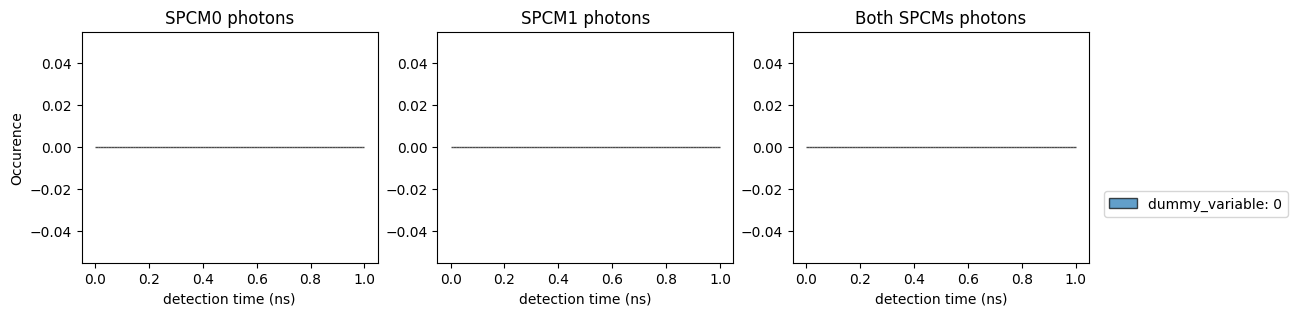

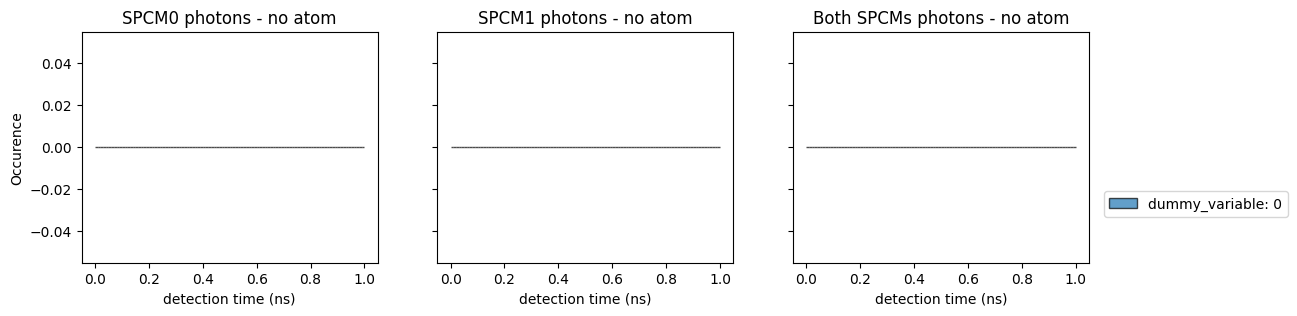

In [34]:
### Print the title of the output
display(HTML(f"""<b style='font-size:18px;'> {date_filters[0]} - RID {rid} - {experiment_function}</b>"""))

max_counts = max(max(SPCM0_SinglePhoton),max(SPCM1_SinglePhoton))+1
bins = list(np.array(list(range(max_counts+1))))  #[0,1,...,max_counts+1]

titles = [f"{scan_variable1_name}: {val}" for val in scan_sequence1]
use_titles = True

binned_data_with_atom = []
binned_data_no_atom = []

atom_counts_all_iterations = np.zeros(iterations)
atom_fraction_all_iterations = np.zeros(iterations)

SPCM0_binned_with_atom_all_iterations = []
SPCM0_binned_no_atom_all_iterations = []

SPCM1_binned_with_atom_all_iterations = []
SPCM1_binned_no_atom_all_iterations = []

g2_0_with_atom = np.zeros(iterations)
g2_0_no_atom = np.zeros(iterations)

g2_0_err_with_atom = np.zeros(iterations)
g2_0_err_no_atom = np.zeros(iterations)


ref_time_t1 = SPCM0_SinglePhoton_tStamps[1:,0] ### the time t1 from the excitation cycle as a reference for timing
SPCM0_SinglePhoton_tStamps_i = SPCM0_SinglePhoton_tStamps[1:,1:]  ###  in SPCM0_SinglePhoton_tStamps the first elements are reference times t1.
SPCM1_SinglePhoton_tStamps_i = SPCM1_SinglePhoton_tStamps[1:]  
readout_i = SPCM0_every_exc_RO[1:]


### SPCM0
SPCM0_timestamps_with_atom_i = np.array([p for p,s in zip(SPCM0_SinglePhoton_tStamps_i, readout_i) if s >= cutoff1]).flatten()
SPCM0_timestamps_no_atom_i = np.array([p for p,s in zip(SPCM0_SinglePhoton_tStamps_i, readout_i) if s < cutoff1]).flatten()
SPCM0_timestamps_with_atom_i = SPCM0_timestamps_with_atom_i[SPCM0_timestamps_with_atom_i != -1.0] - ref_time_t1[0]  ## remove -1 (no click) events
SPCM0_timestamps_no_atom_i = SPCM0_timestamps_no_atom_i[SPCM0_timestamps_no_atom_i != -1.0] - ref_time_t1[0] ### the first t1 is subtracted as the strat time

### SPCM1
SPCM1_timestamps_with_atom_i = np.array([p for p,s in zip(SPCM1_SinglePhoton_tStamps_i, readout_i) if s >= cutoff1]).flatten()
SPCM1_timestamps_no_atom_i = np.array([p for p,s in zip(SPCM1_SinglePhoton_tStamps_i, readout_i) if s < cutoff1]).flatten()
SPCM1_timestamps_with_atom_i = SPCM1_timestamps_with_atom_i[SPCM1_timestamps_with_atom_i != -1.0] - ref_time_t1[0] ## remove -1 (no click) events
SPCM1_timestamps_no_atom_i = SPCM1_timestamps_no_atom_i[SPCM1_timestamps_no_atom_i != -1.0] - ref_time_t1[0] ## remove -1 (no click) events

BothSPCMs_timestamps_with_atom_i = np.concatenate((SPCM0_timestamps_with_atom_i, SPCM1_timestamps_with_atom_i)) 
BothSPCMs_timestamps_no_atom_i = np.concatenate((SPCM0_timestamps_no_atom_i, SPCM1_timestamps_no_atom_i))


### Photons arival time histograms (with atom):
fig, axs = plt.subplots(1, 3, figsize=(13, 3), sharey=False, sharex=True)

axs[0].hist(SPCM0_timestamps_with_atom_i, bins=100, edgecolor='black', alpha=0.7)
# axs[0].set_xlim(250, 500 )
axs[0].set_xlabel("detection time (ns)")
axs[0].set_ylabel("Occurence")
axs[0].set_title("SPCM0 photons")

axs[1].hist(SPCM1_timestamps_with_atom_i, bins=100, edgecolor='black', alpha=0.7)
axs[1].set_xlabel("detection time (ns)")
axs[1].set_title("SPCM1 photons")

axs[2].hist(BothSPCMs_timestamps_with_atom_i, bins=100, edgecolor='black', alpha=0.7, label=f'{scan_variable1_name}: {scan_sequence1[i]}')
axs[2].set_xlabel("detection time (ns)")
axs[2].set_title("Both SPCMs photons")
axs[2].legend(loc=(1.05, 0.2))


### Photons arival time histograms (without atom):
fig, axs = plt.subplots(1, 3, figsize=(13, 3), sharey=True, sharex=True)

axs[0].hist(SPCM0_timestamps_no_atom_i, bins=100, edgecolor='black', alpha=0.7)
# axs[0].set_xlim(250, 500)
axs[0].set_xlabel("detection time (ns)")
axs[0].set_ylabel("Occurence")
axs[0].set_title("SPCM0 photons - no atom")

axs[1].hist(SPCM1_timestamps_no_atom_i, bins=100, edgecolor='black', alpha=0.7)
axs[1].set_xlabel("detection time (ns)")
axs[1].set_title("SPCM1 photons - no atom")

axs[2].hist(BothSPCMs_timestamps_no_atom_i, bins=100, edgecolor='black', alpha=0.7, label=f'{scan_variable1_name}: {scan_sequence1[i]}')
axs[2].set_xlabel("detection time (ns)")
axs[2].set_title("Both SPCMs photons - no atom")
axs[2].legend(loc=(1.05, 0.2))


print(f'measured number of counts in iteration {i} = {len(BothSPCMs_timestamps_with_atom_i)}')
print(f'overal efficiency (%) in iteration {i} = {len(BothSPCMs_timestamps_with_atom_i)/atom_counts_i * 100}')


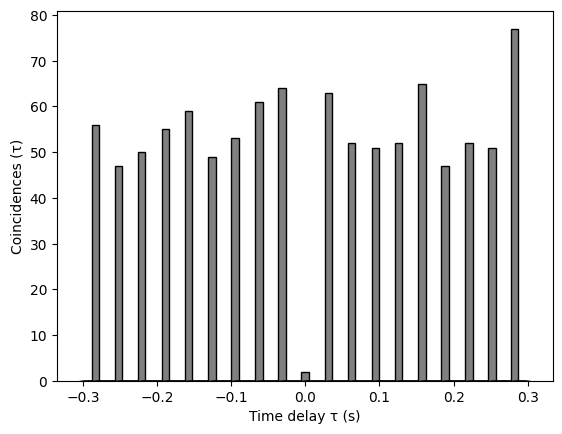

In [8]:
def compute_g2(spcm0_times, spcm1_times, bin_width=1e-3, max_tau=300e-3):
    taus = np.arange(-max_tau, max_tau, bin_width)  # Time bins
    counts, _ = np.histogram(spcm1_times[:, None] - spcm0_times, bins=taus)

    # Normalization (optional, assuming constant background)
    norm_factor = (len(spcm0_times) * len(spcm1_times)) / (2 * max_tau / bin_width)
    # g2 = counts / norm_factor
    g2 = counts

    return taus[:-1] + bin_width / 2, g2, bin_width  # Return bin width for bar plot

taus, g2_values, bin_width = compute_g2(SPCM0_timestamps_with_atom_i, SPCM1_timestamps_with_atom_i)

plt.bar(taus, g2_values, width=10*bin_width, align='center', color='grey', edgecolor='k')
plt.xlabel("Time delay τ (s)")
plt.ylabel("Coincidences (τ)")
plt.show()


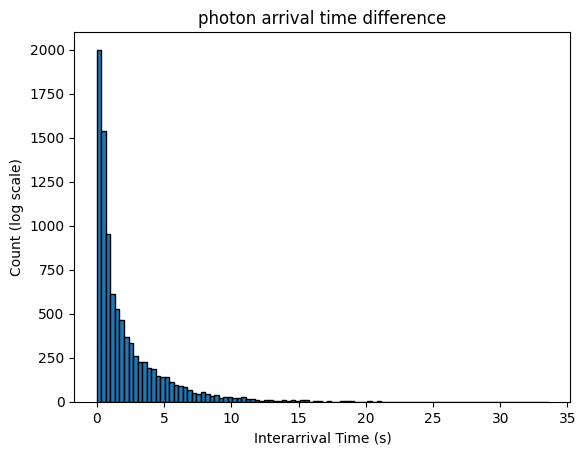

In [39]:
timestamps = np.sort(BothSPCMs_timestamps_with_atom_i)

interarrival_times = np.diff(timestamps)

# Step 3: Define bins (log-spaced bins for better visualization)
bins = np.logspace(np.log10(interarrival_times.min()), np.log10(interarrival_times.max()), 50)

# Plot histogram
plt.hist(interarrival_times, bins=100, edgecolor='black', log=False)  # log=True applies log-scale to y-axis

# Set log scale on x-axis
# plt.xscale("log")

# Labels and title
plt.xlabel("Interarrival Time (s)")
plt.ylabel("Count (log scale)")
plt.title("photon arrival time difference")

# Show the plot
plt.show()

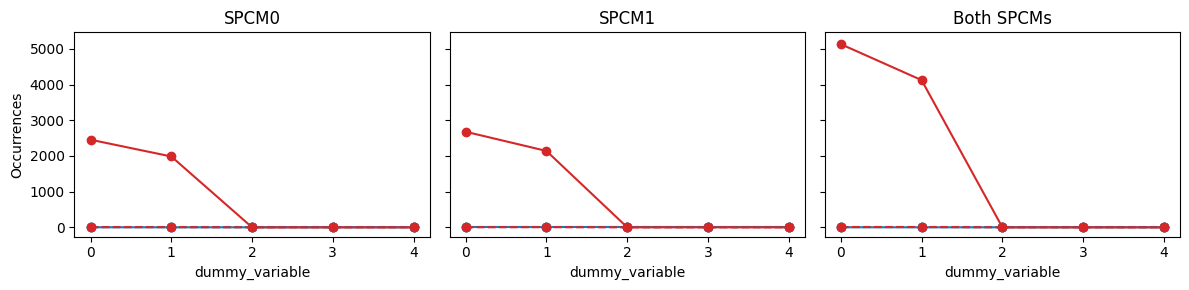

C:\Users\QC\AppData\Local\Temp\ipykernel_13984\1449663314.py:178: RuntimeWarning: invalid value encountered in divide
  no_atom_data_norm = no_atom_data/atom_fraction_all_iterations
C:\Users\QC\AppData\Local\Temp\ipykernel_13984\1449663314.py:179: RuntimeWarning: invalid value encountered in divide
  atom_data_norm = atom_data/atom_fraction_all_iterations


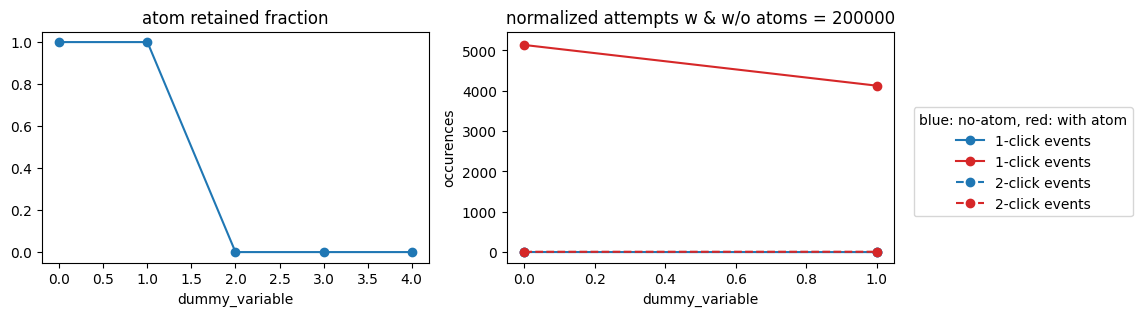

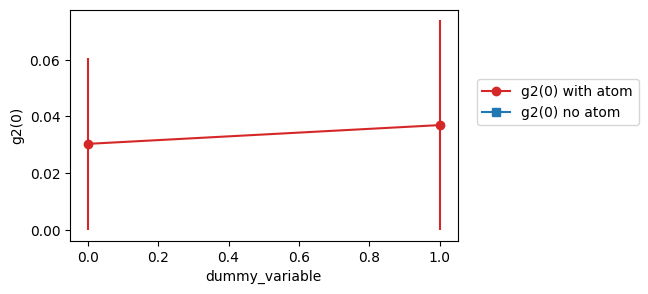

expected number of counts = 10000.0
n_measurements = 1000
n_excitation_cycles = 200
excitation pulse width = 30.000000000000004 ns
SPCM window = 300.0 ns
excitation power set point = 0.01
SPCM gate start offset = 750


In [95]:
max_counts = max(max(SPCM0_SinglePhoton),max(SPCM1_SinglePhoton))+1
bins = list(np.array(list(range(max_counts+1))))  #[0,1,...,max_counts+1]

titles = [f"{scan_variable1_name}: {val}" for val in scan_sequence1]
use_titles = True

binned_data_with_atom = []
binned_data_no_atom = []

atom_counts_all_iterations = np.zeros(iterations)
atom_fraction_all_iterations = np.zeros(iterations)

SPCM0_binned_with_atom_all_iterations = []
SPCM0_binned_no_atom_all_iterations = []

SPCM1_binned_with_atom_all_iterations = []
SPCM1_binned_no_atom_all_iterations = []

g2_0_with_atom = np.zeros(iterations)
g2_0_no_atom = np.zeros(iterations)

g2_0_err_with_atom = np.zeros(iterations)
g2_0_err_no_atom = np.zeros(iterations)

for i in range(iterations):

    ### photons are counted from SPCMs 0 and 1 for the excitation phase
    SPCM0_counts_i = SPCM0_SinglePhoton[1:][n_measurements*n_excitation_cycles*i:(n_measurements*n_excitation_cycles)*(i+1)]
    SPCM1_counts_i = SPCM1_SinglePhoton[1:][n_measurements*n_excitation_cycles*i:(n_measurements*n_excitation_cycles)*(i+1)]
    readout_i = SPCM0_every_exc_RO[1:][n_measurements*n_excitation_cycles*i:(n_measurements*n_excitation_cycles)*(i+1)]
    
    ### SPCM0
    SPCM0_counts_with_atom_i = np.array([p for p,s in zip(SPCM0_counts_i, readout_i) if s > cutoff1]).flatten()
    SPCM0_counts_no_atom_i = np.array([p for p,s in zip(SPCM0_counts_i, readout_i) if s <= cutoff1]).flatten()
    
    ### SPCM1
    SPCM1_counts_with_atom_i = np.array([p for p,s in zip(SPCM1_counts_i, readout_i) if s > cutoff1]).flatten()
    SPCM1_counts_no_atom_i = np.array([p for p,s in zip(SPCM1_counts_i, readout_i) if s <= cutoff1]).flatten()

    ### Calculate g2(0) for the current iteration
    ### with atom:
    n_coincidence_with_atom_i = np.sum((SPCM0_counts_with_atom_i >= 1) & (SPCM1_counts_with_atom_i >= 1))
    n_SPCM0_counts_with_atom_i = np.sum(SPCM0_counts_with_atom_i >= 1)
    n_SPCM1_counts_with_atom_i = np.sum(SPCM1_counts_with_atom_i >= 1)
    n_trial = len(SPCM0_counts_with_atom_i) 

    if n_SPCM0_counts_with_atom_i > 0 and n_SPCM1_counts_with_atom_i > 0:
        g2_0 = (n_coincidence_with_atom_i / 
                  (n_SPCM0_counts_with_atom_i * n_SPCM1_counts_with_atom_i)) * n_trial
        ### Errors for g2 results are from error propagation assuming Poissonian distribution for counts:
        if n_coincidence_with_atom_i > 0:
            g2_0_err = g2_0 * np.sqrt(1/n_coincidence_with_atom_i + 1/n_SPCM0_counts_with_atom_i + 1/n_SPCM1_counts_with_atom_i)
        else:
            g2_0_err = np.nan
    else:
        g2_0 = np.nan 
        g2_0_err = np.nan
    g2_0_with_atom[i] = g2_0
    g2_0_err_with_atom[i] = g2_0_err

    ### without atom:
    n_coincidence_no_atom_i = np.sum((SPCM0_counts_no_atom_i >= 1) & (SPCM1_counts_no_atom_i >= 1))
    n_SPCM0_counts_no_atom_i = np.sum(SPCM0_counts_no_atom_i >= 1)
    n_SPCM1_counts_no_atom_i = np.sum(SPCM1_counts_no_atom_i >= 1)
    n_trial = len(SPCM0_counts_no_atom_i) 

    if n_SPCM0_counts_no_atom_i > 0 and n_SPCM1_counts_no_atom_i > 0:
        g2_0 = (n_coincidence_no_atom_i / 
                  (n_SPCM0_counts_no_atom_i * n_SPCM1_counts_no_atom_i)) * n_trial
        if n_coincidence_no_atom_i > 0:
            g2_0_err = g2_0 * np.sqrt(1/n_coincidence_no_atom_i + 1/n_SPCM0_counts_no_atom_i + 1/n_SPCM1_counts_no_atom_i)
        else:
            g2_0_err = np.nan
    else:
        g2_0 = np.nan
        g2_0_err = np.nan
    g2_0_no_atom[i] = g2_0
    g2_0_err_no_atom[i] = g2_0_err
    

    ### for normalization
    atom_counts_i = 0 # number of atoms retained in each iteration
    for val in readout_i:
        if val > cutoff1:
            atom_counts_i += 1
    atom_counts_all_iterations[i] = atom_counts_i
    if len(readout_i) > 0:
        atom_fraction_all_iterations[i] = atom_counts_i / len(readout_i)

    ### Binning for counting photon clicks
    SPCM0_binned_with_atom_i = np.histogram(SPCM0_counts_with_atom_i, bins=bins)[0]
    SPCM0_binned_with_atom_all_iterations.append(SPCM0_binned_with_atom_i)

    SPCM0_binned_no_atom_i = np.histogram(SPCM0_counts_no_atom_i, bins=bins)[0]
    SPCM0_binned_no_atom_all_iterations.append(SPCM0_binned_no_atom_i)

    SPCM1_binned_with_atom_i = np.histogram(SPCM1_counts_with_atom_i, bins=bins)[0]
    SPCM1_binned_with_atom_all_iterations.append(SPCM1_binned_with_atom_i)

    SPCM1_binned_no_atom_i = np.histogram(SPCM1_counts_no_atom_i, bins=bins)[0]
    SPCM1_binned_no_atom_all_iterations.append(SPCM1_binned_no_atom_i)


### transposing the array for plotting and removing 0 counts:
SPCM0_binned_with_atom_all_iterations_trans = np.array(SPCM0_binned_with_atom_all_iterations).transpose()[1:]
SPCM0_binned_no_atom_all_iterations_trans = np.array(SPCM0_binned_no_atom_all_iterations).transpose()[1:]

SPCM1_binned_with_atom_all_iterations_trans = np.array(SPCM1_binned_with_atom_all_iterations).transpose()[1:]
SPCM1_binned_no_atom_all_iterations_trans = np.array(SPCM1_binned_no_atom_all_iterations).transpose()[1:]

SPCM1and2_binned_with_atom_all_iterations_trans = SPCM0_binned_with_atom_all_iterations_trans + SPCM1_binned_with_atom_all_iterations_trans
SPCM1and2_binned_no_atom_all_iterations_trans = SPCM0_binned_no_atom_all_iterations_trans + SPCM1_binned_no_atom_all_iterations_trans

### Print the title of the output
display(HTML(f"""<b style='font-size:18px;'> {date_filters[0]} - RID {rid} - {experiment_function}</b>"""))


### Un-normalized plots
fig, axs = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
linestyles = ['solid','dashed','dotted','dashdot','dashdot','dashdot','dashdot']

### First plot (SPCM0)
atom_data = SPCM0_binned_with_atom_all_iterations_trans
no_atom_data = SPCM0_binned_no_atom_all_iterations_trans
for i in range(max(bins)-1):
    axs[0].plot(scan_sequence1, no_atom_data[i], label=f'{i+1}-click events', ls=linestyles[i], color='tab:blue', marker='o')
    axs[0].plot(scan_sequence1, atom_data[i], label=f'{i+1}-click events', ls=linestyles[i], color='tab:red', marker='o')
    axs[0].errorbar(scan_sequence1, no_atom_data[i], yerr=[np.sqrt(x) if x > 0 else np.inf for x in no_atom_data[i]], ls='none', color='tab:blue')
    axs[0].errorbar(scan_sequence1, atom_data[i], yerr=[np.sqrt(x) if x > 0 else np.inf for x in atom_data[i]], ls='none', color='tab:red')

axs[0].set_title('SPCM0')
axs[0].set_ylabel('Occurrences')
axs[0].set_xlabel(scan_variable1_name)


### Second plot (SPCM1)
atom_data = SPCM1_binned_with_atom_all_iterations_trans
no_atom_data = SPCM1_binned_no_atom_all_iterations_trans
for i in range(max(bins)-1):
    axs[1].plot(scan_sequence1, no_atom_data[i], label=f'{i+1}-click events', ls=linestyles[i], color='tab:blue', marker='o')
    axs[1].plot(scan_sequence1, atom_data[i], label=f'{i+1}-click events', ls=linestyles[i], color='tab:red', marker='o')
    axs[1].errorbar(scan_sequence1, no_atom_data[i], yerr=[np.sqrt(x) if x > 0 else np.inf for x in no_atom_data[i]], ls='none', color='tab:blue')
    axs[1].errorbar(scan_sequence1, atom_data[i], yerr=[np.sqrt(x) if x > 0 else np.inf for x in atom_data[i]], ls='none', color='tab:red')

axs[1].set_title('SPCM1')
axs[1].set_xlabel(scan_variable1_name)


### 3rd plot (Both SPCMs)
atom_data = SPCM1and2_binned_with_atom_all_iterations_trans
no_atom_data = SPCM1and2_binned_no_atom_all_iterations_trans
for i in range(max(bins)-1):
    axs[2].plot(scan_sequence1, no_atom_data[i], label=f'{i+1}-click events', ls=linestyles[i], color='tab:blue', marker='o')
    axs[2].plot(scan_sequence1, atom_data[i], label=f'{i+1}-click events', ls=linestyles[i], color='tab:red', marker='o')
    axs[2].errorbar(scan_sequence1, no_atom_data[i], yerr=[np.sqrt(x) if x > 0 else np.inf for x in no_atom_data[i]], ls='none', color='tab:blue')
    axs[2].errorbar(scan_sequence1, atom_data[i], yerr=[np.sqrt(x) if x > 0 else np.inf for x in atom_data[i]], ls='none', color='tab:red')

axs[2].set_title('Both SPCMs')
axs[2].set_xlabel(scan_variable1_name)
# axs[2].set_xlim(500,1200)
# axs[2].legend(loc=(1.05, 0.2), title='blue: no-atom, red: with atom')

plt.tight_layout()
plt.show()


### atom retained fraction:
fig, axs = plt.subplots(1, 2, figsize=(11, 3))
axs[0].plot(scan_sequence1,atom_fraction_all_iterations, marker='o')
axs[0].set_xlabel(scan_variable1_name)
axs[0].set_title("atom retained fraction")


### normalized both SPCMs:
atom_data = SPCM1and2_binned_with_atom_all_iterations_trans
no_atom_data = SPCM1and2_binned_no_atom_all_iterations_trans

no_atom_data_norm = no_atom_data/atom_fraction_all_iterations
atom_data_norm = atom_data/atom_fraction_all_iterations


for i in range(max(bins)-1):
    axs[1].plot(scan_sequence1, no_atom_data_norm[i],label=f'{i+1}-click events',ls=linestyles[i],color='tab:blue', marker='o')
    axs[1].plot(scan_sequence1, atom_data_norm[i],label=f'{i+1}-click events',ls=linestyles[i],color='tab:red', marker='o')
    axs[1].errorbar(scan_sequence1, no_atom_data_norm[i], yerr=[np.sqrt(x) if x > 0 else np.inf for x in no_atom_data_norm[i]], ls='none',color='tab:blue')
    axs[1].errorbar(scan_sequence1, atom_data_norm[i], yerr=[np.sqrt(x) if x > 0 else np.inf for x in atom_data_norm[i]], ls='none',color='tab:red')
axs[1].legend(loc=(1.05,0.2), title = 'blue: no-atom, red: with atom')
axs[1].set_title(f'normalized attempts w & w/o atoms = {n_excitation_cycles * n_measurements}')
axs[1].set_ylabel('occurences')
axs[1].set_xlabel(scan_variable1_name)
plt.show()


### Plot g2
plt.figure(figsize=(5, 3))
plt.plot(scan_sequence1, g2_0_with_atom, label='g2(0) with atom', marker='o', color='tab:red')
plt.plot(scan_sequence1, g2_0_no_atom, label='g2(0) no atom', marker='s', color='tab:blue')
plt.errorbar(scan_sequence1, g2_0_with_atom, yerr=g2_0_err_with_atom, ls='none',color='tab:red')
plt.errorbar(scan_sequence1, g2_0_no_atom, yerr=g2_0_err_no_atom, ls='none',color='tab:blue')
plt.legend(loc=(1.05,0.5))
plt.xlabel(scan_variable1_name)
plt.ylabel('g2(0)')
plt.show()


Col_Eff = 0.05 # overal expected/theoretical collection and detection efficiency 
print(f'expected number of counts = {n_excitation_cycles * n_measurements * Col_Eff}')
print(f'n_measurements = {n_measurements}')
print(f'n_excitation_cycles = {n_excitation_cycles}')
print(f'excitation pulse width = {t_excitation_pulse/10**-9}','ns')
print(f'SPCM window = {t_photon_collection_time/10**-9}', 'ns')
print(f'excitation power set point = {set_point_excitation}')
print(f'SPCM gate start offset = {gate_start_offset_mu}')


# Single photon analysis - Readout every excitation cycle (with new variable names such as SPCM0_RO1)
Using the old sequence for atom loading: Turning on MOT and FORT for 500ms, if no atom is trapped, try another cycle. valid for experiments until 2025-02-14.

Analysis for our first search for photons emitted following an excitation pulse, with $g^{(2)}(0)$ calculations. 

To use the analysis code, change the dat in date_filters and find the experiment(s) you want to analyse and write in file_indices. If you like the results and you want to keep them, take a screen clip of the results and save in the powerpoint. All the information you need to know about the experiment should be printed at the end. Please add anything is missing.

In [19]:
date_filters = ["2025-02-14"]

from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import csv
import numpy as np
import os,sys
import PIL # for reading tif images
import h5py
import datetime as dt
import time
from scipy.optimize import curve_fit
from skimage.filters import threshold_otsu
from IPython.display import display, HTML ## for large prints

sys.path.append("..\\")
from h5_data_utilities import * # helper functions for dealing with h5 files

def average_over_measurement(measurements, history):
    iteration = len(history) // measurements
    mean_by_iteration = [np.mean(history[j * measurements:(j + 1) * measurements]) for j in range(iteration)]
    return mean_by_iteration


fnames = get_files_by_criteria(date_filters, # only find files from these date directories
                               name_filters=["GeneralVariableScan"], # only find files containing all these strings
                               condition=lambda filename: True, # use this to filter by experiment parameters, like this: lambda filename: np.bool_(h5py.File(filename)['datasets']['set_current_coil_volts_at_finish'])
                               start_dir=results,
                               include_path=True, # if False, only return the name of the file, not the full path
                               print_filenames=True
)


only_show_i_greater_than = -1

print(f"found {len(fnames)} files")
for i,f in enumerate(fnames):
    if i > only_show_i_greater_than:
        try:
            ds = h5py.File(os.path.join(results, f))['datasets']
            scan_str = str_from_h5(ds['scan_variable1_name'])
            if str_from_h5(ds['scan_variable2_name']) != '':
                scan_str += ", " +str_from_h5(ds['scan_variable2_name'])
            print(f"file {i} ({f}) scanned over "+scan_str)
        except:

            print(f"oops... something wrong with {f}")

skipping C:\Networking Experiment\artiq codes\artiq-master\results\2025-02-14\17\000022251-GeneralVariableScan.h5, which is corrupt
found 27 files
file 0 (C:\Networking Experiment\artiq codes\artiq-master\results\2025-02-14\13\000022192-GeneralVariableScan.h5) scanned over t_microwave_pulse
file 1 (C:\Networking Experiment\artiq codes\artiq-master\results\2025-02-14\13\000022195-GeneralVariableScan.h5) scanned over t_microwave_pulse
file 2 (C:\Networking Experiment\artiq codes\artiq-master\results\2025-02-14\13\000022202-GeneralVariableScan.h5) scanned over t_microwave_pulse
file 3 (C:\Networking Experiment\artiq codes\artiq-master\results\2025-02-14\13\000022202-GeneralVariableScan_microwave_Rabi_scan_over_t_microwave_pulse.h5) scanned over t_microwave_pulse
file 4 (C:\Networking Experiment\artiq codes\artiq-master\results\2025-02-14\13\000022207-GeneralVariableScan.h5) scanned over t_microwave_pulse
file 5 (C:\Networking Experiment\artiq codes\artiq-master\results\2025-02-14\13\00002

experiment: single_photon_experiment_2_atom_loading_advance
override: {'dummy_variable':4}
# of iterations:  1


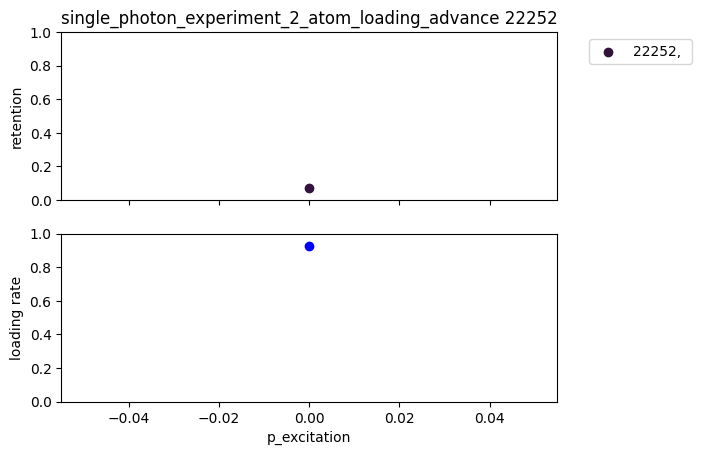

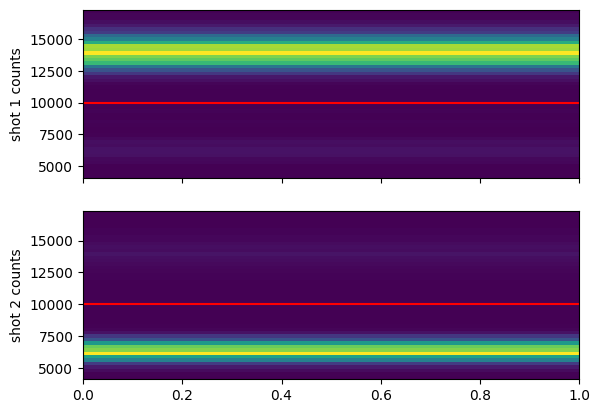

In [2]:
### the file(s) to analyze:
file_indices = {
    26:'',
    # 47:''
    # 48:''
} 

compare = True # compare multiple files in the same retention and loading plots
otsu_threshold = False # compute threshold using Otsu method instead doing it by eye. only work when require atom loading = False
showhist = True
showloading = True
custom_xlabel = True
merge_data = False # if True, the datasets will be combined, and if fit=True, the new merged data will be fit. don't try this in 2D
fit = False

showhist_counts = False 

# for plotting
legend_vars =[]   #legend_vars = ['AY_volts_OP', 'f_microwaves_dds'] # will be included in the plot legend
xform_and_label = {}
loc='best'
ret_cmap = mpl.colormaps['turbo']
ldng_cmap = mpl.colormaps['winter']

# for fitting
fit_dict = {}

if compare:
    if showloading:
        fig_ret,axes = plt.subplots(nrows=2, sharex=True)
        ax_ret, ax_ldng = axes
    else:
        fig_ret,ax_ret = plt.subplots()


first_shot_hists = []
second_shot_hists = []
mean1_by_iteration = []
mean2_by_iteration = []

merged_retention = np.array([])
merged_scan_sequence1 = np.array([])
merged_errs = np.array([])
rid_str = ''


for idx,f_item in enumerate(file_indices.items()):
    f_idx,f_comment = f_item   # idx - f_item = {f_idx: f_comment}
    f = h5py.File(os.path.join(results, fnames[f_idx]))
    rid = f['rid'][()]
    h5_archive_and_datasets_to_locals(f, parent_locals=locals(), quiet=True)
    print("experiment:",experiment_function)
    print("override:",override_ExperimentVariables)

    iterations = len(scan_sequence1) #int(len(SPCM0_RO1)/n_measurements)
    print("# of iterations: ", iterations)
    
    if otsu_threshold:
        thresh = threshold_otsu(SPCM0_RO1)
        print("threshold_otsu: ", thresh)
    else:
        cutoff1 = cutoff2 = single_atom_threshold * t_SPCM_first_shot

    
    ### for plotting 
    ### xsteps_xform is a function that can transform scan_sequence1 for plotting. Here it is equal to identity, i.e. no change in scan_sequence1.
    if scan_variable1_name in xform_and_label and custom_xlabel:
        xsteps_xform, xlabel = (xform_and_label[scan_variable1_name]['xsteps_xform'], xform_and_label[scan_variable1_name]['xlabel'])
    else:
        xsteps_xform, xlabel = (lambda x: x, scan_variable1_name)
        

    legend_string = ''
    for a in legend_vars:
        legend_string += f'{a}={locals()[a]}, '
    legend_string = legend_string[:-2]
    f_comment += legend_string

    
    ### get_loading_and_retention
    ### These array have length = iterations
    retention_array, loading_rate_array, n_atoms_loaded_array = get_loading_and_retention(SPCM0_RO1, SPCM0_RO2, n_measurements, iterations, cutoff1, otsu=otsu_threshold)


    ### Necessary to analyze data with 2 scan_sequences
    ### reshaping each array into a 2D array with shape = shape, with order = 'F' (Fortran-style) to sort column by column
    
    ncols = len(scan_sequence2)
    nrows = len(scan_sequence1)
    shape = (len(scan_sequence2),len(scan_sequence1))
    loading_rate_raveled = np.reshape(loading_rate_array,shape,order='F') # rows have constant variable2
    n_atoms_loaded_raveled = np.reshape(n_atoms_loaded_array,shape,order='F') # rows have constant variable2
    retention_raveled = np.reshape(retention_array,shape,order='F') # rows have constant variable2

    
    ### show historam of first_shot and second_shot
    histMin = np.min([SPCM0_RO1, SPCM0_RO2])/t_SPCM_first_shot ## boundary for the histogram plots
    histMax = np.max([SPCM0_RO1, SPCM0_RO2])/t_SPCM_first_shot
    if showhist:
        first_shot_hists.append(
            [np.histogram(SPCM0_RO1[i*n_measurements:(i+1)*n_measurements]/t_SPCM_first_shot,bins=np.linspace(histMin,histMax,50))[0]
                              for i in range(iterations)])

        second_shot_hists.append(
            [np.histogram(SPCM0_RO2[i*n_measurements:(i+1)*n_measurements]/t_SPCM_second_shot,bins=np.linspace(histMin,histMax,50))[0]
                                      for i in range(iterations)])

    
    ### plot a retention curve vs variable 1 for each variable 2 value
    for i, retention, loading, n_loaded, var2 in zip(range(len(scan_sequence2)), retention_raveled, loading_rate_raveled, n_atoms_loaded_raveled, scan_sequence2):
        
        errs = np.array([1/np.sqrt(n) if n > 0 else np.inf for n in n_loaded])
        if not compare:
            if showloading:
                    fig_ret,axes = plt.subplots(nrows=2, sharex=True)
                    ax_ret, ax_ldng = axes
            else:
                fig_ret,ax_ret = plt.subplots()
                
        if not merge_data:
            ax_ret.scatter(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0], label=str(rid)+', '+f_comment, color=ret_cmap(idx/len(file_indices)))
            ax_ret.errorbar(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0], errs[loading > 0], ls='none',color=ret_cmap(idx/len(file_indices)))
            ax_ret.set_ylim((0,1))

            if not ncols > 1 and fit and scan_variable1_name in fit_dict:
                popt, _ = curve_fit(f=fit_dict[scan_variable1_name]['model'], xdata=scan_sequence1, ydata=retention, p0=fit_dict[scan_variable1_name]['p0'], bounds=fit_dict[scan_variable1_name]['bounds'])
                fit_str = "".join([f'{p}={v:.4f}, ' for p,v in zip(fit_dict[scan_variable1_name]['params'], popt)])[:-2]
                print(fit_str)
                hi_res_x = np.linspace(scan_sequence1[0], scan_sequence1[-1], 10*len(scan_sequence1))
                hi_res_x_xform = np.linspace(xsteps_xform(scan_sequence1)[0], xsteps_xform(scan_sequence1)[-1], 10*len(scan_sequence1))
                ax_ret.plot(hi_res_x_xform, fit_dict[scan_variable1_name]['model'](hi_res_x, *popt),linestyle='--',color=ret_cmap(idx/len(file_indices)),label=fit_str)
            else:
                ax_ret.plot(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0],linestyle='--',color=ret_cmap(idx/len(file_indices)))
    
            if not showloading:
                ax_ret.set_xlabel(xlabel)
            ax_ret.set_ylabel("retention")
            #ax_ret.legend(loc=loc)
            ax_ret.legend(bbox_to_anchor=(1.05, 1), loc='upper left')      # This will show the legend outside the plot
            
        else:
            merged_retention = np.concatenate((merged_retention,retention[loading > 0]))
            merged_scan_sequence1 = np.concatenate((merged_scan_sequence1, scan_sequence1[loading > 0]))
            merged_errs = np.concatenate((merged_errs, errs[loading > 0]))
            rid_str += str(rid) + ', '
    
        if showloading:
            ax_ldng.plot(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], linestyle='--',color=ldng_cmap(idx/len(file_indices)))
            ax_ldng.scatter(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], label=rid, color=ldng_cmap(idx/len(file_indices)))
            errs = np.array([1/np.sqrt(n) if n > 0 else np.inf for n in n_loaded])
            ax_ldng.errorbar(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], errs[loading > 0], ls='none', color=ldng_cmap(idx/len(file_indices)))
            ax_ldng.set_ylim((0,1))
            ax_ldng.set_xlabel(xlabel)
            ax_ldng.set_ylabel("loading rate")


if merge_data:
    retention = merged_retention
    scan_sequence1 = merged_scan_sequence1
    errs = merged_errs

    ax_ret.scatter(xsteps_xform(scan_sequence1), retention, color='plum')
    ax_ret.errorbar(xsteps_xform(scan_sequence1), retention, errs, ls='none',color='plum')
    ax_ret.set_ylim((0,1))
    
    if not ncols > 1 and fit and scan_variable1_name in fit_dict:        
        popt, _ = curve_fit(f=fit_dict[scan_variable1_name]['model'], xdata=scan_sequence1, ydata=retention, p0=fit_dict[scan_variable1_name]['p0'], bounds=fit_dict[scan_variable1_name]['bounds'])
        hi_res_x = np.linspace(scan_sequence1[0], scan_sequence1[-1], 10*len(scan_sequence1))
        hi_res_x_xform = np.linspace(xsteps_xform(scan_sequence1)[0], xsteps_xform(scan_sequence1)[-1], 10*len(scan_sequence1))
        fit_str = "".join([f'{p}={v:.4f}, ' for p,v in zip(fit_dict[scan_variable1_name]['params'], popt)])[:-2]
        print(fit_str)
        ax_ret.plot(hi_res_x_xform, fit_dict[scan_variable1_name]['model'](hi_res_x, *popt),linestyle='--',color='violet', label=fit_str)
        ax_ret.legend()
    else:
        ax_ret.plot(xsteps_xform(scan_sequence1), retention,linestyle='--',color='violet')


if not compare or len(file_indices)==1:
    ax_ret.set_title(experiment_function+' '+str(rid))
elif merge_data:
    ax_ret.set_title(experiment_function+' '+ rid_str[:-2])
else:
    ax_ret.set_title(experiment_function)

if showhist:
    fig,axes = plt.subplots(nrows=2,sharex=True)
    ax,ax2 = axes
    cax=ax.imshow(np.array(first_shot_hists[0]).transpose(),origin='lower',extent=[0,iterations,histMin,histMax])
    ax.set_ylabel("shot 1 counts")
    ax.axhline(cutoff1/t_SPCM_first_shot,color='red')
    ax.set_aspect('auto')
    cax2=ax2.imshow(np.array(second_shot_hists[0]).transpose(),origin='lower',extent=[0,iterations,histMin,histMax])
    ax2.set_ylabel("shot 2 counts")
    
    ax2.axhline(cutoff2/t_SPCM_first_shot,color='red')
    ax2.set_aspect('auto')
plt.show()

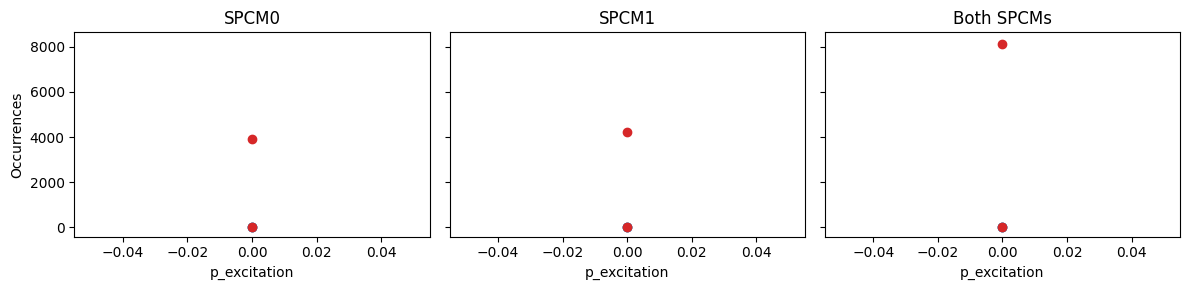

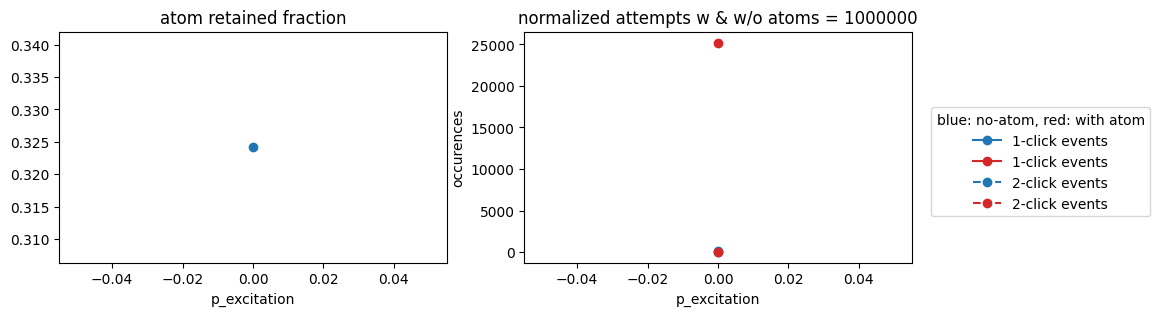

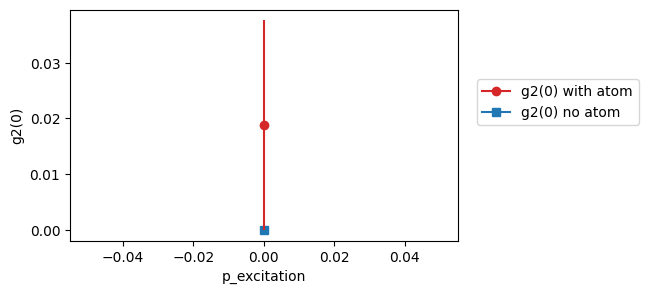

expected number of counts = 50000.0
n_measurements = 5000
n_excitation_cycles = 200
excitation pulse width = 30.000000000000004 ns
SPCM window = 300.0 ns
excitation power set point = 0.01
SPCM gate start offset = 750


In [20]:
max_counts = max(max(SPCM0_SinglePhoton),max(SPCM1_SinglePhoton))+1
bins = list(np.array(list(range(max_counts+1))))  #[0,1,...,max_counts+1]

titles = [f"{scan_variable1_name}: {val}" for val in scan_sequence1]
use_titles = True

binned_data_with_atom = []
binned_data_no_atom = []

atom_counts_all_iterations = np.zeros(iterations)
atom_fraction_all_iterations = np.zeros(iterations)

SPCM0_binned_with_atom_all_iterations = []
SPCM0_binned_no_atom_all_iterations = []

SPCM1_binned_with_atom_all_iterations = []
SPCM1_binned_no_atom_all_iterations = []

g2_0_with_atom = np.zeros(iterations)
g2_0_no_atom = np.zeros(iterations)

g2_0_err_with_atom = np.zeros(iterations)
g2_0_err_no_atom = np.zeros(iterations)

for i in range(iterations):

    ### photons are counted from SPCMs 0 and 1 for the excitation phase
    SPCM0_counts_i = SPCM0_SinglePhoton[1:][n_measurements*n_excitation_cycles*i:(n_measurements*n_excitation_cycles)*(i+1)]
    SPCM1_counts_i = SPCM1_SinglePhoton[1:][n_measurements*n_excitation_cycles*i:(n_measurements*n_excitation_cycles)*(i+1)]
    readout_i = SPCM0_every_exc_RO[1:][n_measurements*n_excitation_cycles*i:(n_measurements*n_excitation_cycles)*(i+1)]
    
    ### SPCM0
    SPCM0_counts_with_atom_i = np.array([p for p,s in zip(SPCM0_counts_i, readout_i) if s > cutoff1]).flatten()
    SPCM0_counts_no_atom_i = np.array([p for p,s in zip(SPCM0_counts_i, readout_i) if s <= cutoff1]).flatten()
    
    ### SPCM1
    SPCM1_counts_with_atom_i = np.array([p for p,s in zip(SPCM1_counts_i, readout_i) if s > cutoff1]).flatten()
    SPCM1_counts_no_atom_i = np.array([p for p,s in zip(SPCM1_counts_i, readout_i) if s <= cutoff1]).flatten()

    ### Calculate g2(0) for the current iteration
    ### with atom:
    n_coincidence_with_atom_i = np.sum((SPCM0_counts_with_atom_i >= 1) & (SPCM1_counts_with_atom_i >= 1))
    n_SPCM0_counts_with_atom_i = np.sum(SPCM0_counts_with_atom_i >= 1)
    n_SPCM1_counts_with_atom_i = np.sum(SPCM1_counts_with_atom_i >= 1)
    n_trial_atom = len(SPCM0_counts_with_atom_i) 

    if n_SPCM0_counts_with_atom_i > 0 and n_SPCM1_counts_with_atom_i > 0:
        g2_0 = (n_coincidence_with_atom_i / 
                  (n_SPCM0_counts_with_atom_i * n_SPCM1_counts_with_atom_i)) * n_trial_atom
        ### Errors for g2 results are from error propagation assuming Poissonian distribution for counts:
        if n_coincidence_with_atom_i > 0:
            g2_0_err = g2_0 * np.sqrt(1/n_coincidence_with_atom_i + 1/n_SPCM0_counts_with_atom_i + 1/n_SPCM1_counts_with_atom_i)
        else:
            g2_0_err = np.nan
    else:
        g2_0 = np.nan 
        g2_0_err = np.nan
    g2_0_with_atom[i] = g2_0
    g2_0_err_with_atom[i] = g2_0_err

    ### without atom:
    n_coincidence_no_atom_i = np.sum((SPCM0_counts_no_atom_i >= 1) & (SPCM1_counts_no_atom_i >= 1))
    n_SPCM0_counts_no_atom_i = np.sum(SPCM0_counts_no_atom_i >= 1)
    n_SPCM1_counts_no_atom_i = np.sum(SPCM1_counts_no_atom_i >= 1)
    n_trial_no_atom = len(SPCM0_counts_no_atom_i) 

    if n_SPCM0_counts_no_atom_i > 0 and n_SPCM1_counts_no_atom_i > 0:
        g2_0 = (n_coincidence_no_atom_i / 
                  (n_SPCM0_counts_no_atom_i * n_SPCM1_counts_no_atom_i)) * n_trial_no_atom
        if n_coincidence_no_atom_i > 0:
            g2_0_err = g2_0 * np.sqrt(1/n_coincidence_no_atom_i + 1/n_SPCM0_counts_no_atom_i + 1/n_SPCM1_counts_no_atom_i)
        else:
            g2_0_err = np.nan
    else:
        g2_0 = np.nan
        g2_0_err = np.nan
    g2_0_no_atom[i] = g2_0
    g2_0_err_no_atom[i] = g2_0_err
    

    ### for normalization
    atom_counts_i = 0 # number of atoms retained in each iteration
    for val in readout_i:
        if val > cutoff1:
            atom_counts_i += 1
    atom_counts_all_iterations[i] = atom_counts_i
    if len(readout_i) > 0:
        atom_fraction_all_iterations[i] = atom_counts_i / len(readout_i)

    ### Binning for counting photon clicks
    SPCM0_binned_with_atom_i = np.histogram(SPCM0_counts_with_atom_i, bins=bins)[0]
    SPCM0_binned_with_atom_all_iterations.append(SPCM0_binned_with_atom_i)

    SPCM0_binned_no_atom_i = np.histogram(SPCM0_counts_no_atom_i, bins=bins)[0]
    SPCM0_binned_no_atom_all_iterations.append(SPCM0_binned_no_atom_i)

    SPCM1_binned_with_atom_i = np.histogram(SPCM1_counts_with_atom_i, bins=bins)[0]
    SPCM1_binned_with_atom_all_iterations.append(SPCM1_binned_with_atom_i)

    SPCM1_binned_no_atom_i = np.histogram(SPCM1_counts_no_atom_i, bins=bins)[0]
    SPCM1_binned_no_atom_all_iterations.append(SPCM1_binned_no_atom_i)


### transposing the array for plotting and removing 0 counts:
SPCM0_binned_with_atom_all_iterations_trans = np.array(SPCM0_binned_with_atom_all_iterations).transpose()[1:]
SPCM0_binned_no_atom_all_iterations_trans = np.array(SPCM0_binned_no_atom_all_iterations).transpose()[1:]

SPCM1_binned_with_atom_all_iterations_trans = np.array(SPCM1_binned_with_atom_all_iterations).transpose()[1:]
SPCM1_binned_no_atom_all_iterations_trans = np.array(SPCM1_binned_no_atom_all_iterations).transpose()[1:]

SPCM1and2_binned_with_atom_all_iterations_trans = SPCM0_binned_with_atom_all_iterations_trans + SPCM1_binned_with_atom_all_iterations_trans
SPCM1and2_binned_no_atom_all_iterations_trans = SPCM0_binned_no_atom_all_iterations_trans + SPCM1_binned_no_atom_all_iterations_trans

### Print the title of the output
display(HTML(f"""<b style='font-size:18px;'> {date_filters[0]} - RID {rid} - {experiment_function}</b>"""))


### Un-normalized plots
fig, axs = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
linestyles = ['solid','dashed','dotted','dashdot','dashdot','dashdot','dashdot']

### First plot (SPCM0)
atom_data = SPCM0_binned_with_atom_all_iterations_trans
no_atom_data = SPCM0_binned_no_atom_all_iterations_trans
for i in range(max(bins)-1):
    axs[0].plot(scan_sequence1, no_atom_data[i], label=f'{i+1}-click events', ls=linestyles[i], color='tab:blue', marker='o')
    axs[0].plot(scan_sequence1, atom_data[i], label=f'{i+1}-click events', ls=linestyles[i], color='tab:red', marker='o')
    axs[0].errorbar(scan_sequence1, no_atom_data[i], yerr=[np.sqrt(x) if x > 0 else np.inf for x in no_atom_data[i]], ls='none', color='tab:blue')
    axs[0].errorbar(scan_sequence1, atom_data[i], yerr=[np.sqrt(x) if x > 0 else np.inf for x in atom_data[i]], ls='none', color='tab:red')

axs[0].set_title('SPCM0')
axs[0].set_ylabel('Occurrences')
axs[0].set_xlabel(scan_variable1_name)


### Second plot (SPCM1)
atom_data = SPCM1_binned_with_atom_all_iterations_trans
no_atom_data = SPCM1_binned_no_atom_all_iterations_trans
for i in range(max(bins)-1):
    axs[1].plot(scan_sequence1, no_atom_data[i], label=f'{i+1}-click events', ls=linestyles[i], color='tab:blue', marker='o')
    axs[1].plot(scan_sequence1, atom_data[i], label=f'{i+1}-click events', ls=linestyles[i], color='tab:red', marker='o')
    axs[1].errorbar(scan_sequence1, no_atom_data[i], yerr=[np.sqrt(x) if x > 0 else np.inf for x in no_atom_data[i]], ls='none', color='tab:blue')
    axs[1].errorbar(scan_sequence1, atom_data[i], yerr=[np.sqrt(x) if x > 0 else np.inf for x in atom_data[i]], ls='none', color='tab:red')

axs[1].set_title('SPCM1')
axs[1].set_xlabel(scan_variable1_name)


### 3rd plot (Both SPCMs)
atom_data = SPCM1and2_binned_with_atom_all_iterations_trans
no_atom_data = SPCM1and2_binned_no_atom_all_iterations_trans
for i in range(max(bins)-1):
    axs[2].plot(scan_sequence1, no_atom_data[i], label=f'{i+1}-click events', ls=linestyles[i], color='tab:blue', marker='o')
    axs[2].plot(scan_sequence1, atom_data[i], label=f'{i+1}-click events', ls=linestyles[i], color='tab:red', marker='o')
    axs[2].errorbar(scan_sequence1, no_atom_data[i], yerr=[np.sqrt(x) if x > 0 else np.inf for x in no_atom_data[i]], ls='none', color='tab:blue')
    axs[2].errorbar(scan_sequence1, atom_data[i], yerr=[np.sqrt(x) if x > 0 else np.inf for x in atom_data[i]], ls='none', color='tab:red')

axs[2].set_title('Both SPCMs')
axs[2].set_xlabel(scan_variable1_name)
# axs[2].set_xlim(500,1200)
# axs[2].legend(loc=(1.05, 0.2), title='blue: no-atom, red: with atom')

plt.tight_layout()
plt.show()


### atom retained fraction:
fig, axs = plt.subplots(1, 2, figsize=(11, 3))
axs[0].plot(scan_sequence1,atom_fraction_all_iterations, marker='o')
axs[0].set_xlabel(scan_variable1_name)
axs[0].set_title("atom retained fraction")


### normalized both SPCMs:
atom_data = SPCM1and2_binned_with_atom_all_iterations_trans
no_atom_data = SPCM1and2_binned_no_atom_all_iterations_trans

no_atom_data_norm = no_atom_data/atom_fraction_all_iterations
atom_data_norm = atom_data/atom_fraction_all_iterations


for i in range(max(bins)-1):
    axs[1].plot(scan_sequence1, no_atom_data_norm[i],label=f'{i+1}-click events',ls=linestyles[i],color='tab:blue', marker='o')
    axs[1].plot(scan_sequence1, atom_data_norm[i],label=f'{i+1}-click events',ls=linestyles[i],color='tab:red', marker='o')
    axs[1].errorbar(scan_sequence1, no_atom_data_norm[i], yerr=[np.sqrt(x) if x > 0 else np.inf for x in no_atom_data_norm[i]], ls='none',color='tab:blue')
    axs[1].errorbar(scan_sequence1, atom_data_norm[i], yerr=[np.sqrt(x) if x > 0 else np.inf for x in atom_data_norm[i]], ls='none',color='tab:red')
axs[1].legend(loc=(1.05,0.2), title = 'blue: no-atom, red: with atom')
axs[1].set_title(f'normalized attempts w & w/o atoms = {n_excitation_cycles * n_measurements}')
axs[1].set_ylabel('occurences')
axs[1].set_xlabel(scan_variable1_name)
plt.show()


### Plot g2
plt.figure(figsize=(5, 3))
plt.plot(scan_sequence1, g2_0_with_atom, label='g2(0) with atom', marker='o', color='tab:red')
plt.plot(scan_sequence1, g2_0_no_atom, label='g2(0) no atom', marker='s', color='tab:blue')
plt.errorbar(scan_sequence1, g2_0_with_atom, yerr=g2_0_err_with_atom, ls='none',color='tab:red')
plt.errorbar(scan_sequence1, g2_0_no_atom, yerr=g2_0_err_no_atom, ls='none',color='tab:blue')
plt.legend(loc=(1.05,0.5))
plt.xlabel(scan_variable1_name)
plt.ylabel('g2(0)')
plt.show()


Col_Eff = 0.05 # overal expected/theoretical collection and detection efficiency 
print(f'expected number of counts = {n_excitation_cycles * n_measurements * Col_Eff}')
print(f'n_measurements = {n_measurements}')
print(f'n_excitation_cycles = {n_excitation_cycles}')
print(f'excitation pulse width = {t_excitation_pulse/10**-9}','ns')
print(f'SPCM window = {t_photon_collection_time/10**-9}', 'ns')
print(f'excitation power set point = {set_point_excitation}')
print(f'SPCM gate start offset = {gate_start_offset_mu}')


measured number of counts in iteration 0 = 8155
overal efficiency (%) in iteration 0 = 2.6143267026784427
n_measurements = 5000
n_excitation_cycles = 200
excitation pulse width = 30.000000000000004 ns
SPCM window = 300.0 ns


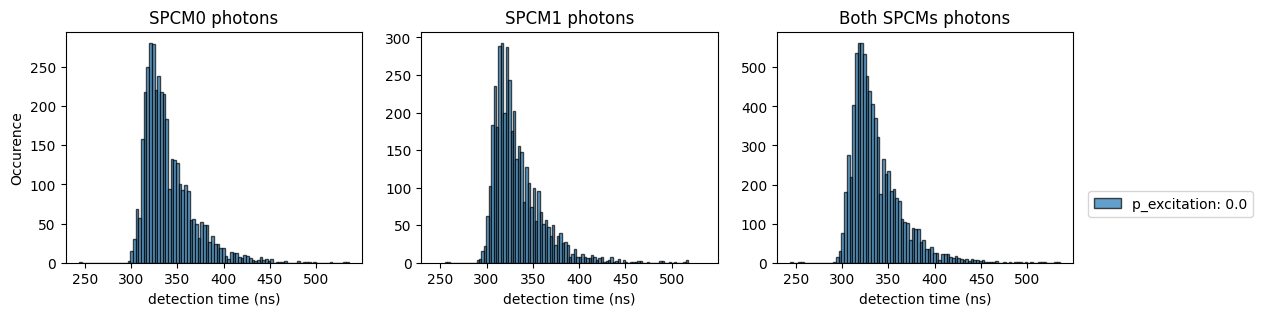

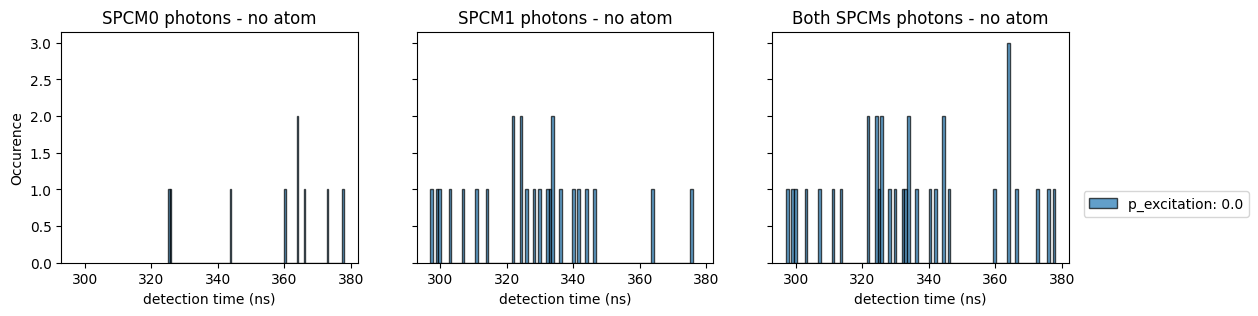

In [22]:
### Print the title of the output
display(HTML(f"""<b style='font-size:18px;'> {date_filters[0]} - RID {rid} - {experiment_function}</b>"""))

for i in range(iterations):
    SPCM0_SinglePhoton_tStamps_i = SPCM0_SinglePhoton_tStamps[1:][n_measurements*n_excitation_cycles*i:(n_measurements*n_excitation_cycles)*(i+1)]
    SPCM1_SinglePhoton_tStamps_i = SPCM1_SinglePhoton_tStamps[1:][n_measurements*n_excitation_cycles*i:(n_measurements*n_excitation_cycles)*(i+1)]
    readout_i = SPCM0_every_exc_RO[1:][n_measurements*n_excitation_cycles*i:(n_measurements*n_excitation_cycles)*(i+1)]
    
    atom_counts_i = 0 # number of atoms retained in each iteration
    for val in readout_i:
        if val > cutoff1:
            atom_counts_i += 1
    
    ### SPCM0
    SPCM0_timestamps_with_atom_i = np.array([p for p,s in zip(SPCM0_SinglePhoton_tStamps_i, readout_i) if s > cutoff1]).flatten()
    SPCM0_timestamps_no_atom_i = np.array([p for p,s in zip(SPCM0_SinglePhoton_tStamps_i, readout_i) if s <= cutoff1]).flatten()
    SPCM0_timestamps_with_atom_i = SPCM0_timestamps_with_atom_i[SPCM0_timestamps_with_atom_i != -1.0] - gate_start_offset_mu*10**-9 ## remove -1 (no click) events
    SPCM0_timestamps_no_atom_i = SPCM0_timestamps_no_atom_i[SPCM0_timestamps_no_atom_i != -1.0] - gate_start_offset_mu*10**-9 ## remove -1 (no click) events
    ## subtracted the offset gate_start_offset_mu*10**-9 to avoid 3-digit time tags.

    
    ### SPCM1
    SPCM1_timestamps_with_atom_i = np.array([p for p,s in zip(SPCM1_SinglePhoton_tStamps_i, readout_i) if s > cutoff1]).flatten()
    SPCM1_timestamps_no_atom_i = np.array([p for p,s in zip(SPCM1_SinglePhoton_tStamps_i, readout_i) if s <= cutoff1]).flatten()
    SPCM1_timestamps_with_atom_i = SPCM1_timestamps_with_atom_i[SPCM1_timestamps_with_atom_i != -1.0] - gate_start_offset_mu*10**-9 ## remove -1 (no click) events
    SPCM1_timestamps_no_atom_i = SPCM1_timestamps_no_atom_i[SPCM1_timestamps_no_atom_i != -1.0] - gate_start_offset_mu*10**-9 ## remove -1 (no click) events

    BothSPCMs_timestamps_with_atom_i = np.concatenate((SPCM0_timestamps_with_atom_i, SPCM1_timestamps_with_atom_i)) 
    BothSPCMs_timestamps_no_atom_i = np.concatenate((SPCM0_timestamps_no_atom_i, SPCM1_timestamps_no_atom_i))

    ### Convert timestamps from s to ns
    SPCM0_timestamps_with_atom_i *= 1e9
    SPCM1_timestamps_with_atom_i *= 1e9
    BothSPCMs_timestamps_with_atom_i *= 1e9

    SPCM0_timestamps_no_atom_i *= 1e9
    SPCM1_timestamps_no_atom_i *= 1e9
    BothSPCMs_timestamps_no_atom_i *= 1e9


    ### Photons arival time histograms (with atom):
    fig, axs = plt.subplots(1, 3, figsize=(13, 3), sharey=False, sharex=True)
    
    axs[0].hist(SPCM0_timestamps_with_atom_i, bins=100, edgecolor='black', alpha=0.7)
    # axs[0].set_xlim(250, 500 )
    axs[0].set_xlabel("detection time (ns)")
    axs[0].set_ylabel("Occurence")
    axs[0].set_title("SPCM0 photons")
    
    axs[1].hist(SPCM1_timestamps_with_atom_i, bins=100, edgecolor='black', alpha=0.7)
    axs[1].set_xlabel("detection time (ns)")
    axs[1].set_title("SPCM1 photons")
    
    axs[2].hist(BothSPCMs_timestamps_with_atom_i, bins=100, edgecolor='black', alpha=0.7, label=f'{scan_variable1_name}: {scan_sequence1[i]}')
    axs[2].set_xlabel("detection time (ns)")
    axs[2].set_title("Both SPCMs photons")
    axs[2].legend(loc=(1.05, 0.2))


    ### Photons arival time histograms (without atom):
    fig, axs = plt.subplots(1, 3, figsize=(13, 3), sharey=True, sharex=True)
    
    axs[0].hist(SPCM0_timestamps_no_atom_i, bins=100, edgecolor='black', alpha=0.7)
    # axs[0].set_xlim(250, 500)
    axs[0].set_xlabel("detection time (ns)")
    axs[0].set_ylabel("Occurence")
    axs[0].set_title("SPCM0 photons - no atom")
    
    axs[1].hist(SPCM1_timestamps_no_atom_i, bins=100, edgecolor='black', alpha=0.7)
    axs[1].set_xlabel("detection time (ns)")
    axs[1].set_title("SPCM1 photons - no atom")
    
    axs[2].hist(BothSPCMs_timestamps_no_atom_i, bins=100, edgecolor='black', alpha=0.7, label=f'{scan_variable1_name}: {scan_sequence1[i]}')
    axs[2].set_xlabel("detection time (ns)")
    axs[2].set_title("Both SPCMs photons - no atom")
    axs[2].legend(loc=(1.05, 0.2))


    print(f'measured number of counts in iteration {i} = {len(BothSPCMs_timestamps_with_atom_i)}')
    print(f'overal efficiency (%) in iteration {i} = {len(BothSPCMs_timestamps_with_atom_i)/atom_counts_i * 100}')


print(f'n_measurements = {n_measurements}')
print(f'n_excitation_cycles = {n_excitation_cycles}')
print(f'excitation pulse width = {t_excitation_pulse/10**-9}','ns')
print(f'SPCM window = {t_photon_collection_time/10**-9}', 'ns')

# plt.hist(BothSPCMs_timestamps_with_atom_i, bins=50, edgecolor='black', alpha=0.7)
# formatter = FuncFormatter(lambda x, _: f'{x * 1e9:.0f}')  # Multiply by 1e9 to convert to ns
# plt.gca().xaxis.set_major_formatter(formatter)

# # Labels and title
# plt.xlabel("detection time (ns)")
# plt.ylabel("Occurence")
# plt.title("Photon wavefunction")
# plt.show()

# plt.hist(BothSPCMs_timestamps_no_atom_i, bins=50, edgecolor='black', alpha=0.7)
# formatter = FuncFormatter(lambda x, _: f'{x * 1e9:.0f}')  # Multiply by 1e9 to convert to ns
# plt.gca().xaxis.set_major_formatter(formatter)
# # Labels and title
# plt.xlabel("detection time (ns)")
# plt.ylabel("Occurence")
# plt.title("Photon wavefunction")
# plt.show()

In [322]:
np.savetxt("BothSPCMs_timestamps_with_atom_RID21962.csv", BothSPCMs_timestamps_with_atom_i, delimiter=",")

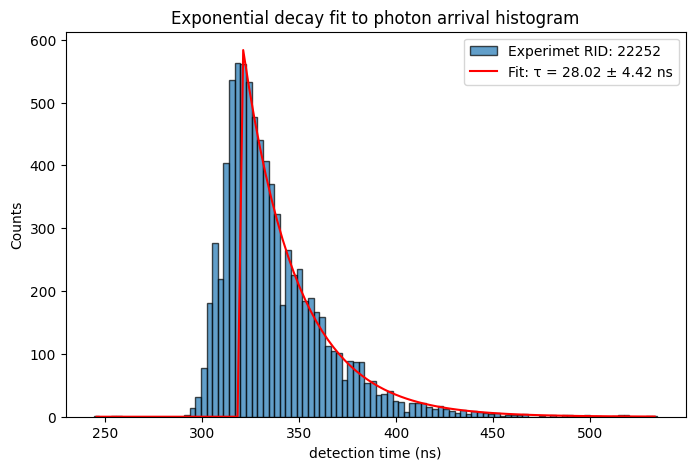

In [281]:
"""   Fitting exponential decay to the histogram  """

data = BothSPCMs_timestamps_with_atom_i
### Create histogram and get bin edges & counts
bin_counts, bin_edges = np.histogram(data, bins=100)  

### Compute bin centers from edges
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

### exponential decay function for fit
def exp_decay(t, t0, N0, tau):
    return N0 * np.exp(-(t - t0) / tau) * (t > t0)  # Step function ensures decay starts at t0

### Initial guesses for fitting parameters
t0_guess = 320  # Estimate for the start of decay
N0_guess = max(bin_counts) 
tau_guess = 26  # Expected atomic lifetime in ns

### Fit the histogram data to the exponential function
params, covariance = curve_fit(exp_decay, bin_centers, bin_counts, p0=[t0_guess, N0_guess, tau_guess])

### Extract fitted parameters and uncertainties
t0_fit, N0_fit, tau_fit = params
t0_err, N0_err, tau_err = np.sqrt(np.diag(covariance))  # Standard errors

### Generate curve using fitted parameters
fit_curve = exp_decay(bin_centers, t0_fit, N0_fit, tau_fit)


plt.figure(figsize=(8, 5))
plt.hist(data, bins=100, edgecolor='black', alpha=0.7, label=f"Experimet RID: {rid}")
plt.plot(bin_centers, fit_curve, 'r-', label=f"Fit: τ = {tau_fit:.2f} ± {tau_err:.2f} ns")

plt.xlabel("detection time (ns)")
plt.ylabel("Counts")
plt.title("Exponential decay fit to photon arrival histogram")
plt.legend()
plt.show()


# Single photon analysis - Readout every excitation cycle (before changing the variable names from counts and counts1)
Analysis for our first search for photons emitted following an excitation pulse, with $g^{(2)}(0)$ calculations for experiments until 2025-01-15.

To use the analysis code, change the dat in date_filters and find the experiment(s) you want to analyse and write in file_indices. If you like the results and you want to keep them, take a screen clip of the results and save in the powerpoint. All the information you need to know about the experiment should be printed at the end. Please add anything is missing.

In [31]:
date_filters = ["2025-01-09"]

from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import csv
import numpy as np
import os,sys
import PIL # for reading tif images
import h5py
import datetime as dt
import time
from scipy.optimize import curve_fit
from skimage.filters import threshold_otsu
from IPython.display import display, HTML ## for large prints

sys.path.append("..\\")
from h5_data_utilities import * # helper functions for dealing with h5 files

def average_over_measurement(measurements, history):
    iteration = len(history) // measurements
    mean_by_iteration = [np.mean(history[j * measurements:(j + 1) * measurements]) for j in range(iteration)]
    return mean_by_iteration


fnames = get_files_by_criteria(date_filters, # only find files from these date directories
                               name_filters=["GeneralVariableScan"], # only find files containing all these strings
                               condition=lambda filename: True, # use this to filter by experiment parameters, like this: lambda filename: np.bool_(h5py.File(filename)['datasets']['set_current_coil_volts_at_finish'])
                               start_dir=results,
                               include_path=True, # if False, only return the name of the file, not the full path
                               print_filenames=True
)


only_show_i_greater_than = -1

print(f"found {len(fnames)} files")
for i,f in enumerate(fnames):
    if i > only_show_i_greater_than:
        try:
            ds = h5py.File(os.path.join(results, f))['datasets']
            scan_str = str_from_h5(ds['scan_variable1_name'])
            if str_from_h5(ds['scan_variable2_name']) != '':
                scan_str += ", " +str_from_h5(ds['scan_variable2_name'])
            print(f"file {i} ({f}) scanned over "+scan_str)
        except:

            print(f"oops... something wrong with {f}")

found 6 files
file 0 (C:\Networking Experiment\artiq codes\artiq-master\results\2025-01-09\11\000021415-GeneralVariableScan.h5) scanned over gate_start_offset_mu
file 1 (C:\Networking Experiment\artiq codes\artiq-master\results\2025-01-09\11\000021416-GeneralVariableScan.h5) scanned over gate_start_offset_mu
file 2 (C:\Networking Experiment\artiq codes\artiq-master\results\2025-01-09\11\000021417-GeneralVariableScan.h5) scanned over gate_start_offset_mu
file 3 (C:\Networking Experiment\artiq codes\artiq-master\results\2025-01-09\11\000021417-GeneralVariableScan_single_photon_experiment_atom_load_scan_over_gate_start_offset_mu.h5) scanned over gate_start_offset_mu
file 4 (C:\Networking Experiment\artiq codes\artiq-master\results\2025-01-09\16\000021418-GeneralVariableScan.h5) scanned over gate_start_offset_mu
file 5 (C:\Networking Experiment\artiq codes\artiq-master\results\2025-01-09\16\000021418-GeneralVariableScan_single_photon_experiment_atom_load_scan_over_gate_start_offset_mu.h5) 

experiment: single_photon_experiment_atom_loading_advance
override: {'dummy_variable':4,'require_atom_loading_to_advance_in_single_photon_exp': True, 'n_excitation_cycles':200, 'set_point_excitation':0.4}
# of iterations:  10


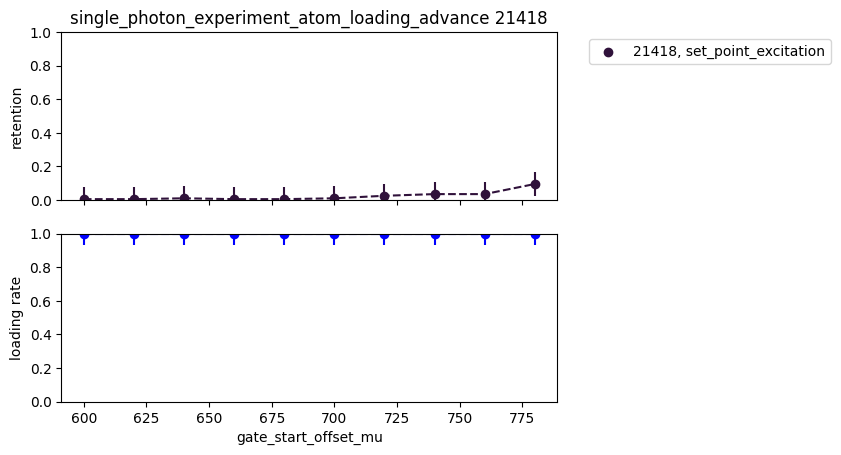

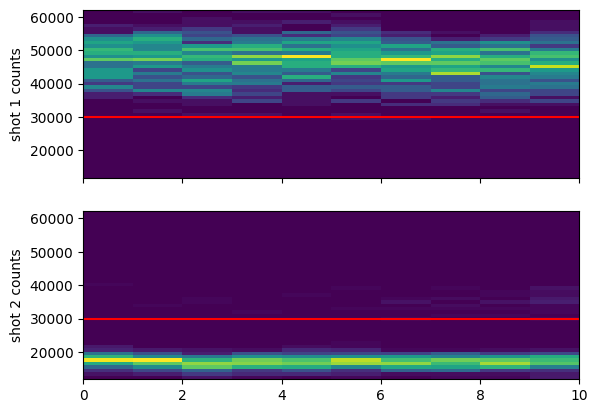

In [35]:
### the file(s) to analyze:
file_indices = {
   4: 'set_point_excitation'
} 


compare = True # compare multiple files in the same retention and loading plots
otsu_threshold = False # compute threshold using Otsu method instead doing it by eye. only work when require atom loading = False
showhist = True
showloading = True
custom_xlabel = True
merge_data = False # if True, the datasets will be combined, and if fit=True, the new merged data will be fit. don't try this in 2D
fit = False

showhist_counts = False 

# for plotting
legend_vars =[]   #legend_vars = ['AY_volts_OP', 'f_microwaves_dds'] # will be included in the plot legend
xform_and_label = {}
loc='best'
ret_cmap = mpl.colormaps['turbo']
ldng_cmap = mpl.colormaps['winter']

# for fitting
fit_dict = {}

if compare:
    if showloading:
        fig_ret,axes = plt.subplots(nrows=2, sharex=True)
        ax_ret, ax_ldng = axes
    else:
        fig_ret,ax_ret = plt.subplots()


first_shot_hists = []
second_shot_hists = []
mean1_by_iteration = []
mean2_by_iteration = []

merged_retention = np.array([])
merged_scan_sequence1 = np.array([])
merged_errs = np.array([])
rid_str = ''


for idx,f_item in enumerate(file_indices.items()):
    f_idx,f_comment = f_item   # idx - f_item = {f_idx: f_comment}
    f = h5py.File(os.path.join(results, fnames[f_idx]))
    rid = f['rid'][()]
    h5_archive_and_datasets_to_locals(f, parent_locals=locals(), quiet=True)
    print("experiment:",experiment_function)
    print("override:",override_ExperimentVariables)

    iterations = len(scan_sequence1) #int(len(photocounts)/n_measurements)
    print("# of iterations: ", iterations)
    
    if otsu_threshold:
        thresh = threshold_otsu(photocounts)
        print("threshold_otsu: ", thresh)
    else:
        cutoff1 = cutoff2 = single_atom_counts_per_s * t_SPCM_first_shot

    
    ### for plotting 
    ### xsteps_xform is a function that can transform scan_sequence1 for plotting. Here it is equal to identity, i.e. no change in scan_sequence1.
    if scan_variable1_name in xform_and_label and custom_xlabel:
        xsteps_xform, xlabel = (xform_and_label[scan_variable1_name]['xsteps_xform'], xform_and_label[scan_variable1_name]['xlabel'])
    else:
        xsteps_xform, xlabel = (lambda x: x, scan_variable1_name)
        

    legend_string = ''
    for a in legend_vars:
        legend_string += f'{a}={locals()[a]}, '
    legend_string = legend_string[:-2]
    f_comment += legend_string

    
    ### get_loading_and_retention
    ### These array have length = iterations
    retention_array, loading_rate_array, n_atoms_loaded_array = get_loading_and_retention(photocounts, photocounts2, n_measurements, iterations, cutoff1, otsu=otsu_threshold)


    ### Necessary to analyze data with 2 scan_sequences
    ### reshaping each array into a 2D array with shape = shape, with order = 'F' (Fortran-style) to sort column by column
    
    ncols = len(scan_sequence2)
    nrows = len(scan_sequence1)
    shape = (len(scan_sequence2),len(scan_sequence1))
    loading_rate_raveled = np.reshape(loading_rate_array,shape,order='F') # rows have constant variable2
    n_atoms_loaded_raveled = np.reshape(n_atoms_loaded_array,shape,order='F') # rows have constant variable2
    retention_raveled = np.reshape(retention_array,shape,order='F') # rows have constant variable2

    
    ### show historam of first_shot and second_shot
    histMin = np.min([photocounts, photocounts2])/t_SPCM_first_shot ## boundary for the histogram plots
    histMax = np.max([photocounts, photocounts2])/t_SPCM_first_shot
    if showhist:
        first_shot_hists.append(
            [np.histogram(photocounts[i*n_measurements:(i+1)*n_measurements]/t_SPCM_first_shot,bins=np.linspace(histMin,histMax,50))[0]
                              for i in range(iterations)])

        second_shot_hists.append(
            [np.histogram(photocounts2[i*n_measurements:(i+1)*n_measurements]/t_SPCM_second_shot,bins=np.linspace(histMin,histMax,50))[0]
                                      for i in range(iterations)])

    
    ### plot a retention curve vs variable 1 for each variable 2 value
    for i, retention, loading, n_loaded, var2 in zip(range(len(scan_sequence2)), retention_raveled, loading_rate_raveled, n_atoms_loaded_raveled, scan_sequence2):
        
        errs = np.array([1/np.sqrt(n) if n > 0 else np.inf for n in n_loaded])
        if not compare:
            if showloading:
                    fig_ret,axes = plt.subplots(nrows=2, sharex=True)
                    ax_ret, ax_ldng = axes
            else:
                fig_ret,ax_ret = plt.subplots()
                
        if not merge_data:
            ax_ret.scatter(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0], label=str(rid)+', '+f_comment, color=ret_cmap(idx/len(file_indices)))
            ax_ret.errorbar(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0], errs[loading > 0], ls='none',color=ret_cmap(idx/len(file_indices)))
            ax_ret.set_ylim((0,1))

            if not ncols > 1 and fit and scan_variable1_name in fit_dict:
                popt, _ = curve_fit(f=fit_dict[scan_variable1_name]['model'], xdata=scan_sequence1, ydata=retention, p0=fit_dict[scan_variable1_name]['p0'], bounds=fit_dict[scan_variable1_name]['bounds'])
                fit_str = "".join([f'{p}={v:.4f}, ' for p,v in zip(fit_dict[scan_variable1_name]['params'], popt)])[:-2]
                print(fit_str)
                hi_res_x = np.linspace(scan_sequence1[0], scan_sequence1[-1], 10*len(scan_sequence1))
                hi_res_x_xform = np.linspace(xsteps_xform(scan_sequence1)[0], xsteps_xform(scan_sequence1)[-1], 10*len(scan_sequence1))
                ax_ret.plot(hi_res_x_xform, fit_dict[scan_variable1_name]['model'](hi_res_x, *popt),linestyle='--',color=ret_cmap(idx/len(file_indices)),label=fit_str)
            else:
                ax_ret.plot(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0],linestyle='--',color=ret_cmap(idx/len(file_indices)))
    
            if not showloading:
                ax_ret.set_xlabel(xlabel)
            ax_ret.set_ylabel("retention")
            #ax_ret.legend(loc=loc)
            ax_ret.legend(bbox_to_anchor=(1.05, 1), loc='upper left')      # This will show the legend outside the plot
            
        else:
            merged_retention = np.concatenate((merged_retention,retention[loading > 0]))
            merged_scan_sequence1 = np.concatenate((merged_scan_sequence1, scan_sequence1[loading > 0]))
            merged_errs = np.concatenate((merged_errs, errs[loading > 0]))
            rid_str += str(rid) + ', '
    
        if showloading:
            ax_ldng.plot(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], linestyle='--',color=ldng_cmap(idx/len(file_indices)))
            ax_ldng.scatter(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], label=rid, color=ldng_cmap(idx/len(file_indices)))
            errs = np.array([1/np.sqrt(n) if n > 0 else np.inf for n in n_loaded])
            ax_ldng.errorbar(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], errs[loading > 0], ls='none', color=ldng_cmap(idx/len(file_indices)))
            ax_ldng.set_ylim((0,1))
            ax_ldng.set_xlabel(xlabel)
            ax_ldng.set_ylabel("loading rate")


if merge_data:
    retention = merged_retention
    scan_sequence1 = merged_scan_sequence1
    errs = merged_errs

    ax_ret.scatter(xsteps_xform(scan_sequence1), retention, color='plum')
    ax_ret.errorbar(xsteps_xform(scan_sequence1), retention, errs, ls='none',color='plum')
    ax_ret.set_ylim((0,1))
    
    if not ncols > 1 and fit and scan_variable1_name in fit_dict:        
        popt, _ = curve_fit(f=fit_dict[scan_variable1_name]['model'], xdata=scan_sequence1, ydata=retention, p0=fit_dict[scan_variable1_name]['p0'], bounds=fit_dict[scan_variable1_name]['bounds'])
        hi_res_x = np.linspace(scan_sequence1[0], scan_sequence1[-1], 10*len(scan_sequence1))
        hi_res_x_xform = np.linspace(xsteps_xform(scan_sequence1)[0], xsteps_xform(scan_sequence1)[-1], 10*len(scan_sequence1))
        fit_str = "".join([f'{p}={v:.4f}, ' for p,v in zip(fit_dict[scan_variable1_name]['params'], popt)])[:-2]
        print(fit_str)
        ax_ret.plot(hi_res_x_xform, fit_dict[scan_variable1_name]['model'](hi_res_x, *popt),linestyle='--',color='violet', label=fit_str)
        ax_ret.legend()
    else:
        ax_ret.plot(xsteps_xform(scan_sequence1), retention,linestyle='--',color='violet')


if not compare or len(file_indices)==1:
    ax_ret.set_title(experiment_function+' '+str(rid))
elif merge_data:
    ax_ret.set_title(experiment_function+' '+ rid_str[:-2])
else:
    ax_ret.set_title(experiment_function)

if showhist:
    fig,axes = plt.subplots(nrows=2,sharex=True)
    ax,ax2 = axes
    cax=ax.imshow(np.array(first_shot_hists[0]).transpose(),origin='lower',extent=[0,iterations,histMin,histMax])
    ax.set_ylabel("shot 1 counts")
    ax.axhline(cutoff1/t_SPCM_first_shot,color='red')
    ax.set_aspect('auto')
    cax2=ax2.imshow(np.array(second_shot_hists[0]).transpose(),origin='lower',extent=[0,iterations,histMin,histMax])
    ax2.set_ylabel("shot 2 counts")
    
    ax2.axhline(cutoff2/t_SPCM_first_shot,color='red')
    ax2.set_aspect('auto')
plt.show()

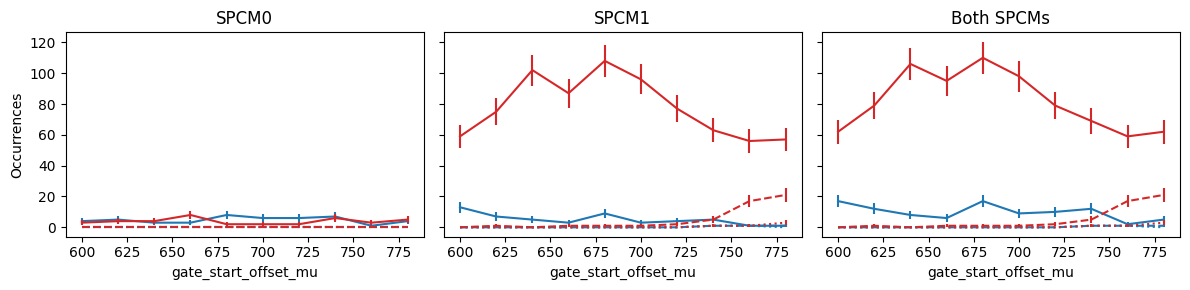

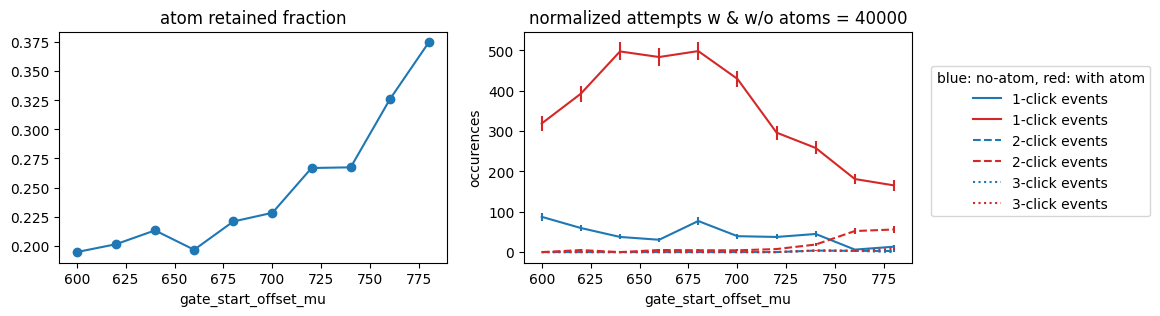

expected number of counts = 2000.0
n_measurements = 200
n_excitation_cycles = 200
excitation pulse width = 50.0 ns
SPCM window = 200.0 ns
excitation power set point = 0.4
SPCM gate start offset = 750


In [36]:
max_counts = max(max(excitation_counts),max(excitation_counts1))+1
bins = list(np.array(list(range(max_counts+1))))  #[0,1,...,max_counts+1]

titles = [f"{scan_variable1_name}: {val}" for val in scan_sequence1]
use_titles = True

binned_data_with_atom = []
binned_data_no_atom = []

atom_counts_all_iterations = np.zeros(iterations)
atom_fraction_all_iterations = np.zeros(iterations)

SPCM0_binned_with_atom_all_iterations = []
SPCM0_binned_no_atom_all_iterations = []

SPCM1_binned_with_atom_all_iterations = []
SPCM1_binned_no_atom_all_iterations = []

g2_0_with_atom = np.zeros(iterations)
g2_0_no_atom = np.zeros(iterations)

for i in range(iterations):

    ### photons are counted from SPCMs 0 and 1 for the excitation phase
    SPCM0_counts_i = excitation_counts[1:][n_measurements*n_excitation_cycles*i:(n_measurements*n_excitation_cycles)*(i+1)]
    SPCM1_counts_i = excitation_counts1[1:][n_measurements*n_excitation_cycles*i:(n_measurements*n_excitation_cycles)*(i+1)]
    readout_i = readout_counts[1:][n_measurements*n_excitation_cycles*i:(n_measurements*n_excitation_cycles)*(i+1)]
    
    ### SPCM0
    SPCM0_counts_with_atom_i = np.array([p for p,s in zip(SPCM0_counts_i, readout_i) if s > cutoff1]).flatten()
    SPCM0_counts_no_atom_i = np.array([p for p,s in zip(SPCM0_counts_i, readout_i) if s <= cutoff1]).flatten()
    
    ### SPCM1
    SPCM1_counts_with_atom_i = np.array([p for p,s in zip(SPCM1_counts_i, readout_i) if s > cutoff1]).flatten()
    SPCM1_counts_no_atom_i = np.array([p for p,s in zip(SPCM1_counts_i, readout_i) if s <= cutoff1]).flatten()

    ### Calculate g2(0) for the current iteration
    ### with atom:
    n_coincidence_with_atom_i = np.sum((SPCM0_counts_with_atom_i >= 1) & (SPCM1_counts_with_atom_i >= 1))
    n_SPCM0_counts_with_atom_i = np.sum(SPCM0_counts_with_atom_i >= 1)
    n_SPCM1_counts_with_atom_i = np.sum(SPCM1_counts_with_atom_i >= 1)
    n_trial = len(SPCM0_counts_with_atom_i) 

    if n_SPCM0_counts_with_atom_i > 0 and n_SPCM1_counts_with_atom_i > 0:
        g2_0 = (n_coincidence_with_atom_i / 
                  (n_SPCM0_counts_with_atom_i * n_SPCM1_counts_with_atom_i)) * n_trial
    else:
        g2_0 = np.nan 
    g2_0_with_atom[i] = g2_0

    ### without atom:
    n_coincidence_no_atom_i = np.sum((SPCM0_counts_no_atom_i >= 1) & (SPCM1_counts_no_atom_i >= 1))
    n_SPCM0_counts_no_atom_i = np.sum(SPCM0_counts_no_atom_i >= 1)
    n_SPCM1_counts_no_atom_i = np.sum(SPCM1_counts_no_atom_i >= 1)
    n_trial = len(SPCM0_counts_no_atom_i) 

    if n_SPCM0_counts_no_atom_i > 0 and n_SPCM1_counts_no_atom_i > 0:
        g2_0 = (n_coincidence_no_atom_i / 
                  (n_SPCM0_counts_no_atom_i * n_SPCM1_counts_no_atom_i)) * n_trial
    else:
        g2_0 = np.nan
    g2_0_no_atom[i] = g2_0
    

    ### for normalization
    atom_counts_i = 0 # number of atoms retained in each iteration
    for val in readout_i:
        if val > cutoff1:
            atom_counts_i += 1
    atom_counts_all_iterations[i] = atom_counts_i
    if len(readout_i) > 0:
        atom_fraction_all_iterations[i] = atom_counts_i / len(readout_i)

    ### Binning for counting photon clicks
    SPCM0_binned_with_atom_i = np.histogram(SPCM0_counts_with_atom_i, bins=bins)[0]
    SPCM0_binned_with_atom_all_iterations.append(SPCM0_binned_with_atom_i)

    SPCM0_binned_no_atom_i = np.histogram(SPCM0_counts_no_atom_i, bins=bins)[0]
    SPCM0_binned_no_atom_all_iterations.append(SPCM0_binned_no_atom_i)

    SPCM1_binned_with_atom_i = np.histogram(SPCM1_counts_with_atom_i, bins=bins)[0]
    SPCM1_binned_with_atom_all_iterations.append(SPCM1_binned_with_atom_i)

    SPCM1_binned_no_atom_i = np.histogram(SPCM1_counts_no_atom_i, bins=bins)[0]
    SPCM1_binned_no_atom_all_iterations.append(SPCM1_binned_no_atom_i)


### transposing the array for plotting and removing 0 counts:
SPCM0_binned_with_atom_all_iterations_trans = np.array(SPCM0_binned_with_atom_all_iterations).transpose()[1:]
SPCM0_binned_no_atom_all_iterations_trans = np.array(SPCM0_binned_no_atom_all_iterations).transpose()[1:]

SPCM1_binned_with_atom_all_iterations_trans = np.array(SPCM1_binned_with_atom_all_iterations).transpose()[1:]
SPCM1_binned_no_atom_all_iterations_trans = np.array(SPCM1_binned_no_atom_all_iterations).transpose()[1:]

SPCM1and2_binned_with_atom_all_iterations_trans = SPCM0_binned_with_atom_all_iterations_trans + SPCM1_binned_with_atom_all_iterations_trans
SPCM1and2_binned_no_atom_all_iterations_trans = SPCM0_binned_no_atom_all_iterations_trans + SPCM1_binned_no_atom_all_iterations_trans

### Print the title of the output
display(HTML(f"""<b style='font-size:18px;'> {date_filters[0]} - RID {rid} - {experiment_function}</b>"""))


### Un-normalized plots
fig, axs = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
linestyles = ['solid','dashed','dotted','dashdot']

### First plot (SPCM0)
atom_data = SPCM0_binned_with_atom_all_iterations_trans
no_atom_data = SPCM0_binned_no_atom_all_iterations_trans
for i in range(max(bins)-1):
    axs[0].plot(scan_sequence1, no_atom_data[i], label=f'{i+1}-click events', ls=linestyles[i], color='tab:blue')
    axs[0].plot(scan_sequence1, atom_data[i], label=f'{i+1}-click events', ls=linestyles[i], color='tab:red')
    axs[0].errorbar(scan_sequence1, no_atom_data[i], yerr=[np.sqrt(x) if x > 0 else np.inf for x in no_atom_data[i]], ls='none', color='tab:blue')
    axs[0].errorbar(scan_sequence1, atom_data[i], yerr=[np.sqrt(x) if x > 0 else np.inf for x in atom_data[i]], ls='none', color='tab:red')

axs[0].set_title('SPCM0')
axs[0].set_ylabel('Occurrences')
axs[0].set_xlabel(scan_variable1_name)


### Second plot (SPCM1)
atom_data = SPCM1_binned_with_atom_all_iterations_trans
no_atom_data = SPCM1_binned_no_atom_all_iterations_trans
for i in range(max(bins)-1):
    axs[1].plot(scan_sequence1, no_atom_data[i], label=f'{i+1}-click events', ls=linestyles[i], color='tab:blue')
    axs[1].plot(scan_sequence1, atom_data[i], label=f'{i+1}-click events', ls=linestyles[i], color='tab:red')
    axs[1].errorbar(scan_sequence1, no_atom_data[i], yerr=[np.sqrt(x) if x > 0 else np.inf for x in no_atom_data[i]], ls='none', color='tab:blue')
    axs[1].errorbar(scan_sequence1, atom_data[i], yerr=[np.sqrt(x) if x > 0 else np.inf for x in atom_data[i]], ls='none', color='tab:red')

axs[1].set_title('SPCM1')
axs[1].set_xlabel(scan_variable1_name)


### 3rd plot (Both SPCMs)
atom_data = SPCM1and2_binned_with_atom_all_iterations_trans
no_atom_data = SPCM1and2_binned_no_atom_all_iterations_trans
for i in range(max(bins)-1):
    axs[2].plot(scan_sequence1, no_atom_data[i], label=f'{i+1}-click events', ls=linestyles[i], color='tab:blue')
    axs[2].plot(scan_sequence1, atom_data[i], label=f'{i+1}-click events', ls=linestyles[i], color='tab:red')
    axs[2].errorbar(scan_sequence1, no_atom_data[i], yerr=[np.sqrt(x) if x > 0 else np.inf for x in no_atom_data[i]], ls='none', color='tab:blue')
    axs[2].errorbar(scan_sequence1, atom_data[i], yerr=[np.sqrt(x) if x > 0 else np.inf for x in atom_data[i]], ls='none', color='tab:red')

axs[2].set_title('Both SPCMs')
axs[2].set_xlabel(scan_variable1_name)
# axs[2].legend(loc=(1.05, 0.2), title='blue: no-atom, red: with atom')

plt.tight_layout()
plt.show()


### atom retained fraction:
fig, axs = plt.subplots(1, 2, figsize=(11, 3))
axs[0].plot(scan_sequence1,atom_fraction_all_iterations, marker='o')
axs[0].set_xlabel(scan_variable1_name)
axs[0].set_title("atom retained fraction")


### normalized both SPCMs:
atom_data = SPCM1and2_binned_with_atom_all_iterations_trans
no_atom_data = SPCM1and2_binned_no_atom_all_iterations_trans

no_atom_data_norm = no_atom_data/atom_fraction_all_iterations
atom_data_norm = atom_data/atom_fraction_all_iterations


for i in range(max(bins)-1):
    axs[1].plot(scan_sequence1, no_atom_data_norm[i],label=f'{i+1}-click events',ls=linestyles[i],color='tab:blue')
    axs[1].plot(scan_sequence1, atom_data_norm[i],label=f'{i+1}-click events',ls=linestyles[i],color='tab:red')
    axs[1].errorbar(scan_sequence1, no_atom_data_norm[i], yerr=[np.sqrt(x) if x > 0 else np.inf for x in no_atom_data_norm[i]], ls='none',color='tab:blue')
    axs[1].errorbar(scan_sequence1, atom_data_norm[i], yerr=[np.sqrt(x) if x > 0 else np.inf for x in atom_data_norm[i]], ls='none',color='tab:red')
axs[1].legend(loc=(1.05,0.2), title = 'blue: no-atom, red: with atom')
axs[1].set_title(f'normalized attempts w & w/o atoms = {n_excitation_cycles * n_measurements}')
axs[1].set_ylabel('occurences')
axs[1].set_xlabel(scan_variable1_name)
plt.show()


# ### Plot g2
# plt.figure(figsize=(5, 3))
# plt.plot(scan_sequence1, g2_0_with_atom, label='g2(0) with atom', marker='o', color='tab:red')
# plt.plot(scan_sequence1, g2_0_no_atom, label='g2(0) no atom', marker='s', color='tab:blue')
# plt.errorbar(scan_sequence1, g2_0_with_atom, yerr=[np.sqrt(x) if x > 0 else np.inf for x in g2_0_with_atom], ls='none',color='tab:red')
# plt.errorbar(scan_sequence1, g2_0_no_atom, yerr=[np.sqrt(x) if x > 0 else np.inf for x in g2_0_no_atom], ls='none',color='tab:blue')
# plt.legend(loc=(1.05,0.5))
# plt.xlabel(scan_variable1_name)
# plt.ylabel('g2(0)')
# plt.show()


Col_Eff = 0.05 # overal expected/theoretical collection and detection efficiency 
print(f'expected number of counts = {n_excitation_cycles * n_measurements * Col_Eff}')
print(f'n_measurements = {n_measurements}')
print(f'n_excitation_cycles = {n_excitation_cycles}')
print(f'excitation pulse width = {t_excitation_pulse/10**-9}','ns')
print(f'SPCM window = {t_photon_collection_time/10**-9}', 'ns')
print(f'excitation power set point = {set_point_excitation}')
print(f'SPCM gate start offset = {gate_start_offset_mu}')
